In [47]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [48]:
spatial = pd.read_excel("local_data_spatial.xlsx")

In [49]:
origin = pd.read_excel(
    "local_data.xlsx"
)


In [50]:
origin = origin.merge(
    spatial[["행정동코드", "spatial_cluster"]],
    on="행정동코드",
    how="left",
    validate="many_to_one"
)

In [51]:
origin.head()

,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,...,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수,분기,spatial_cluster
0,7,4111156000,41128684,경기도 수원시 장안구 파장동,22480,241011.94,2023,274,3,248,...,14,21,25,97,19,10.721172,712,316.725979,3,2
1,8,4111156000,5115679,경기도 수원시 장안구 파장동,22451,241268.02,2023,274,3,248,...,14,21,25,97,19,10.746426,712,317.135094,3,2
2,9,4111156000,436318,경기도 수원시 장안구 파장동,22410,236580.40,2023,274,3,248,...,14,21,25,97,19,10.556912,712,317.715306,3,2
3,10,4111156000,631469,경기도 수원시 장안구 파장동,23628,268762.16,2023,274,3,248,...,14,21,25,97,19,11.374732,712,301.337396,4,2
4,11,4111156000,591386,경기도 수원시 장안구 파장동,24542,253510.66,2023,274,3,248,...,14,21,25,97,19,10.329666,712,290.114905,4,2


In [52]:
origin.to_excel("local_dataset.xlsx", index=False)

In [53]:
df1 = my_qtcheck.set_type(origin, as_category=["spatial_cluster", "년도", "기준월", "분기"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   기준월              6240 non-null   category
 1   행정동코드            6240 non-null   int64   
 2   매출금액             6240 non-null   int64   
 3   행정구역             6240 non-null   str     
 4   총인구수             6240 non-null   int64   
 5   월유동인구수           6240 non-null   float64 
 6   년도               6240 non-null   category
 7   가맹점수_소매          6240 non-null   int64   
 8   가맹점수_숙박          6240 non-null   int64   
 9   가맹점수_음식          6240 non-null   int64   
 10  가맹점수_부동산         6240 non-null   int64   
 11  가맹점수_과학·기술       6240 non-null   int64   
 12  가맹점수_시설관리·임대     6240 non-null   int64   
 13  가맹점수_교육          6240 non-null   int64   
 14  가맹점수_보건의료        6240 non-null   int64   
 15  가맹점수_예술·스포츠      6240 non-null   int64   
 16  가맹점수_수리·개인       6240 non-null   int64   
 17  가맹점수_기

In [54]:
# 중복값 제거
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,...,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수,분기,spatial_cluster
0,7,4111156000,41128684,경기도 수원시 장안구 파장동,22480,241011.94,2023,274,3,248,...,14,21,25,97,19,10.721172,712,316.725979,3,2
1,8,4111156000,5115679,경기도 수원시 장안구 파장동,22451,241268.02,2023,274,3,248,...,14,21,25,97,19,10.746426,712,317.135094,3,2
2,9,4111156000,436318,경기도 수원시 장안구 파장동,22410,236580.40,2023,274,3,248,...,14,21,25,97,19,10.556912,712,317.715306,3,2
3,10,4111156000,631469,경기도 수원시 장안구 파장동,23628,268762.16,2023,274,3,248,...,14,21,25,97,19,11.374732,712,301.337396,4,2
4,11,4111156000,591386,경기도 수원시 장안구 파장동,24542,253510.66,2023,274,3,248,...,14,21,25,97,19,10.329666,712,290.114905,4,2


In [55]:
# 결측치 비율 확인
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
기준월,0,0.0
행정동코드,0,0.0
매출금액,0,0.0
행정구역,0,0.0
총인구수,0,0.0
월유동인구수,0,0.0
년도,0,0.0
가맹점수_소매,0,0.0
가맹점수_숙박,0,0.0
가맹점수_음식,0,0.0


### 지역 유형을 결합한 분석 자료의 재점검

- 군집 결합 후에도 6,240행이 유지되고, 중복 행과 결측치가 확인되지 않았다. 행정동별 유형을 월별 관측에 연결한 분석 구조를 유지했다.
- 이 단계에서는 원본 변수의 분포를 다시 소개하는 데 그치지 않고, 군집별 차이와 새 파생변수의 관계를 확인해 모델 입력 후보를 정리한다.
- 군집 번호는 유형을 구분하는 범주이며, 번호가 클수록 지역화폐가 활성화되었다는 순서를 뜻하지 않는다.

In [56]:
df2_categorical_qtcheck = my_qtcheck.categorical_summary(df2, save_path=None)
df2_numerical_qtcheck = my_qtcheck.numerical_summary(df2, save_path=None)

📊 컬럼 '기준월'의 value_counts():


,count
기준월,
1,520
2,520
3,520
4,520
5,520
6,520
7,520
8,520
9,520


📊 컬럼 '년도'의 value_counts():


,count
년도,
2023,1560
2024,3120
2025,1560


📊 컬럼 '분기'의 value_counts():


,count
분기,
1,1560
2,1560
3,1560
4,1560


📊 컬럼 'spatial_cluster'의 value_counts():


,count
spatial_cluster,
0,1776
1,648
2,1680
3,432
4,1704


In [57]:
display(df2)
display(df2_categorical_qtcheck)
display(df2_numerical_qtcheck.T)

,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,...,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수,분기,spatial_cluster
0,7,4111156000,41128684,경기도 수원시 장안구 파장동,22480,241011.94,2023,274,3,248,...,14,21,25,97,19,10.721172,712,316.725979,3,2
1,8,4111156000,5115679,경기도 수원시 장안구 파장동,22451,241268.02,2023,274,3,248,...,14,21,25,97,19,10.746426,712,317.135094,3,2
2,9,4111156000,436318,경기도 수원시 장안구 파장동,22410,236580.40,2023,274,3,248,...,14,21,25,97,19,10.556912,712,317.715306,3,2
3,10,4111156000,631469,경기도 수원시 장안구 파장동,23628,268762.16,2023,274,3,248,...,14,21,25,97,19,11.374732,712,301.337396,4,2
4,11,4111156000,591386,경기도 수원시 장안구 파장동,24542,253510.66,2023,274,3,248,...,14,21,25,97,19,10.329666,712,290.114905,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,2,4167053000,63164,경기도 여주시 오학동,18208,57216.81,2025,193,2,268,...,36,12,31,84,20,3.142399,653,358.633568,1,0
6236,3,4167053000,119778,경기도 여주시 오학동,18222,74042.89,2025,193,2,268,...,36,12,31,84,20,4.063379,653,358.358029,1,0
6237,4,4167053000,79864,경기도 여주시 오학동,18229,61845.05,2025,193,2,268,...,36,12,31,84,20,3.392674,653,358.220418,2,0
6238,5,4167053000,462451,경기도 여주시 오학동,18213,70867.16,2025,193,2,268,...,36,12,31,84,20,3.891021,653,358.535112,2,0


,기준월,년도,분기,spatial_cluster
count,6240,6240,6240,6240
unique,12,3,4,5
top,1,2024,1,0
freq,520,3120,1560,1776


,행정동코드,매출금액,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수
count,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0
mean,4131567895.384615,18829866.649038,26059.542468,468258.3433,209.217308,2.947115,255.900962,0.760577,9.325,2.758654,76.174038,24.150962,33.043269,98.939423,21.418269,21.090457,734.635577,306.796547
std,15590848.095135,74064028.843516,12320.289688,557773.449512,135.586095,6.011377,180.953453,1.081122,9.267938,3.012783,68.417115,20.087849,24.4065,63.056567,15.802345,27.988623,459.4198,202.70379
min,4111156000.0,386.0,978.0,511.86,6.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.295707,12.0,8.186097
25%,4117358750.0,322422.75,17583.5,102517.29,121.0,0.0,133.75,0.0,3.0,1.0,28.0,9.0,15.0,55.0,11.0,4.094927,417.75,192.168467
50%,4128157000.0,846558.0,24476.0,286276.045,182.5,1.0,214.0,0.0,7.0,2.0,55.0,20.0,28.5,87.0,18.0,11.372026,649.5,251.747119
75%,4145334250.0,2145762.5,34141.5,593990.425,260.0,3.0,327.25,1.0,12.0,4.0,103.0,33.0,45.0,126.0,27.0,23.026481,926.25,349.18161
max,4167053000.0,892136990.0,69751.0,3405776.5,1176.0,57.0,1240.0,6.0,84.0,26.0,470.0,111.0,142.0,359.0,96.0,207.92848,2736.0,1709.996737
rel_diff,0.000826,21.242855,0.064698,0.635688,0.146396,1.947115,0.195799,inf,0.332143,0.379327,0.384983,0.207548,0.159413,0.137235,0.189904,0.854591,0.131079,0.21867
rdiff_flag,similar,large_diff,similar,large_diff,diff,large_diff,diff,large_diff,diff,diff,diff,diff,diff,diff,diff,large_diff,diff,diff


In [58]:
df2.to_excel("local_spatial_qtcheck.xlsx", index=False)
df2_categorical_qtcheck.to_excel("local_spatial_categorical_qtcheck.xlsx")
df2_numerical_qtcheck.to_excel("local_spatial_numerical_qtcheck.xlsx")

In [59]:
# 4. 변수 유형 분류
# 종속변수
target = "매출금액"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df2)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형 :", nominal_cols)
print("연속형 :", continuous_cols)

종속변수 : 매출금액
종속변수 유형: 연속형
명목형 : ['기준월', '년도', '분기', 'spatial_cluster']
연속형 : ['행정동코드', '총인구수', '월유동인구수', '가맹점수_소매', '가맹점수_숙박', '가맹점수_음식', '가맹점수_부동산', '가맹점수_과학·기술', '가맹점수_시설관리·임대', '가맹점수_교육', '가맹점수_보건의료', '가맹점수_예술·스포츠', '가맹점수_수리·개인', '가맹점수_기타', '1인당_유동인구', '총_가맹점수', '만명당_가맹점수']


In [60]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_spatial_qtcheck.xlsx")
num_desc = pd.read_excel("local_spatial_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("local_spatial_categorical_qtcheck.xlsx", index_col=0)

In [61]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   기준월              6240 non-null   category
 1   행정동코드            6240 non-null   int64   
 2   매출금액             6240 non-null   int64   
 3   행정구역             6240 non-null   str     
 4   총인구수             6240 non-null   int64   
 5   월유동인구수           6240 non-null   float64 
 6   년도               6240 non-null   category
 7   가맹점수_소매          6240 non-null   int64   
 8   가맹점수_숙박          6240 non-null   int64   
 9   가맹점수_음식          6240 non-null   int64   
 10  가맹점수_부동산         6240 non-null   int64   
 11  가맹점수_과학·기술       6240 non-null   int64   
 12  가맹점수_시설관리·임대     6240 non-null   int64   
 13  가맹점수_교육          6240 non-null   int64   
 14  가맹점수_보건의료        6240 non-null   int64   
 15  가맹점수_예술·스포츠      6240 non-null   int64   
 16  가맹점수_수리·개인       6240 non-null   int64   
 17  가맹점수_기

In [62]:
column_means = {
    "기준월": "데이터 기준 월",
    "행정동코드": "행정동 식별 코드",
    "매출금액": "지역화폐 매출금액(원)",
    "행정구역": "행정구역명",
    "총인구수": "행정동 총인구수(명)",
    "월유동인구수": "행정동 월 유동인구수",
    "년도": "데이터 기준 연도",
    "가맹점수_소매": "소매업 수",
    "가맹점수_숙박": "숙박업 수",
    "가맹점수_음식": "음식업 수",
    "가맹점수_부동산": "부동산업 수",
    "가맹점수_과학·기술": "과학·기술업 수",
    "가맹점수_시설관리·임대": "시설관리·임대업 수",
    "가맹점수_교육": "교육 분야업 수",
    "가맹점수_보건의료": "보건의료 분야업 수",
    "가맹점수_예술·스포츠": "예술·스포츠업 수",
    "가맹점수_수리·개인": "수리·개인서비스업 수",
    "가맹점수_기타": "기타 업종 수",
    "spatial_cluster": "행정동 공간 군집",
    "분기": "분기",
    "1인당_유동인구": "1인당_유동인구",
    "총_가맹점수": "총_가맹점수",
    "만명당_가맹점수": "만명당_가맹점수"
}

In [63]:
# 종속변수 기술통계량 추출
num_desc.loc[[target]].T

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


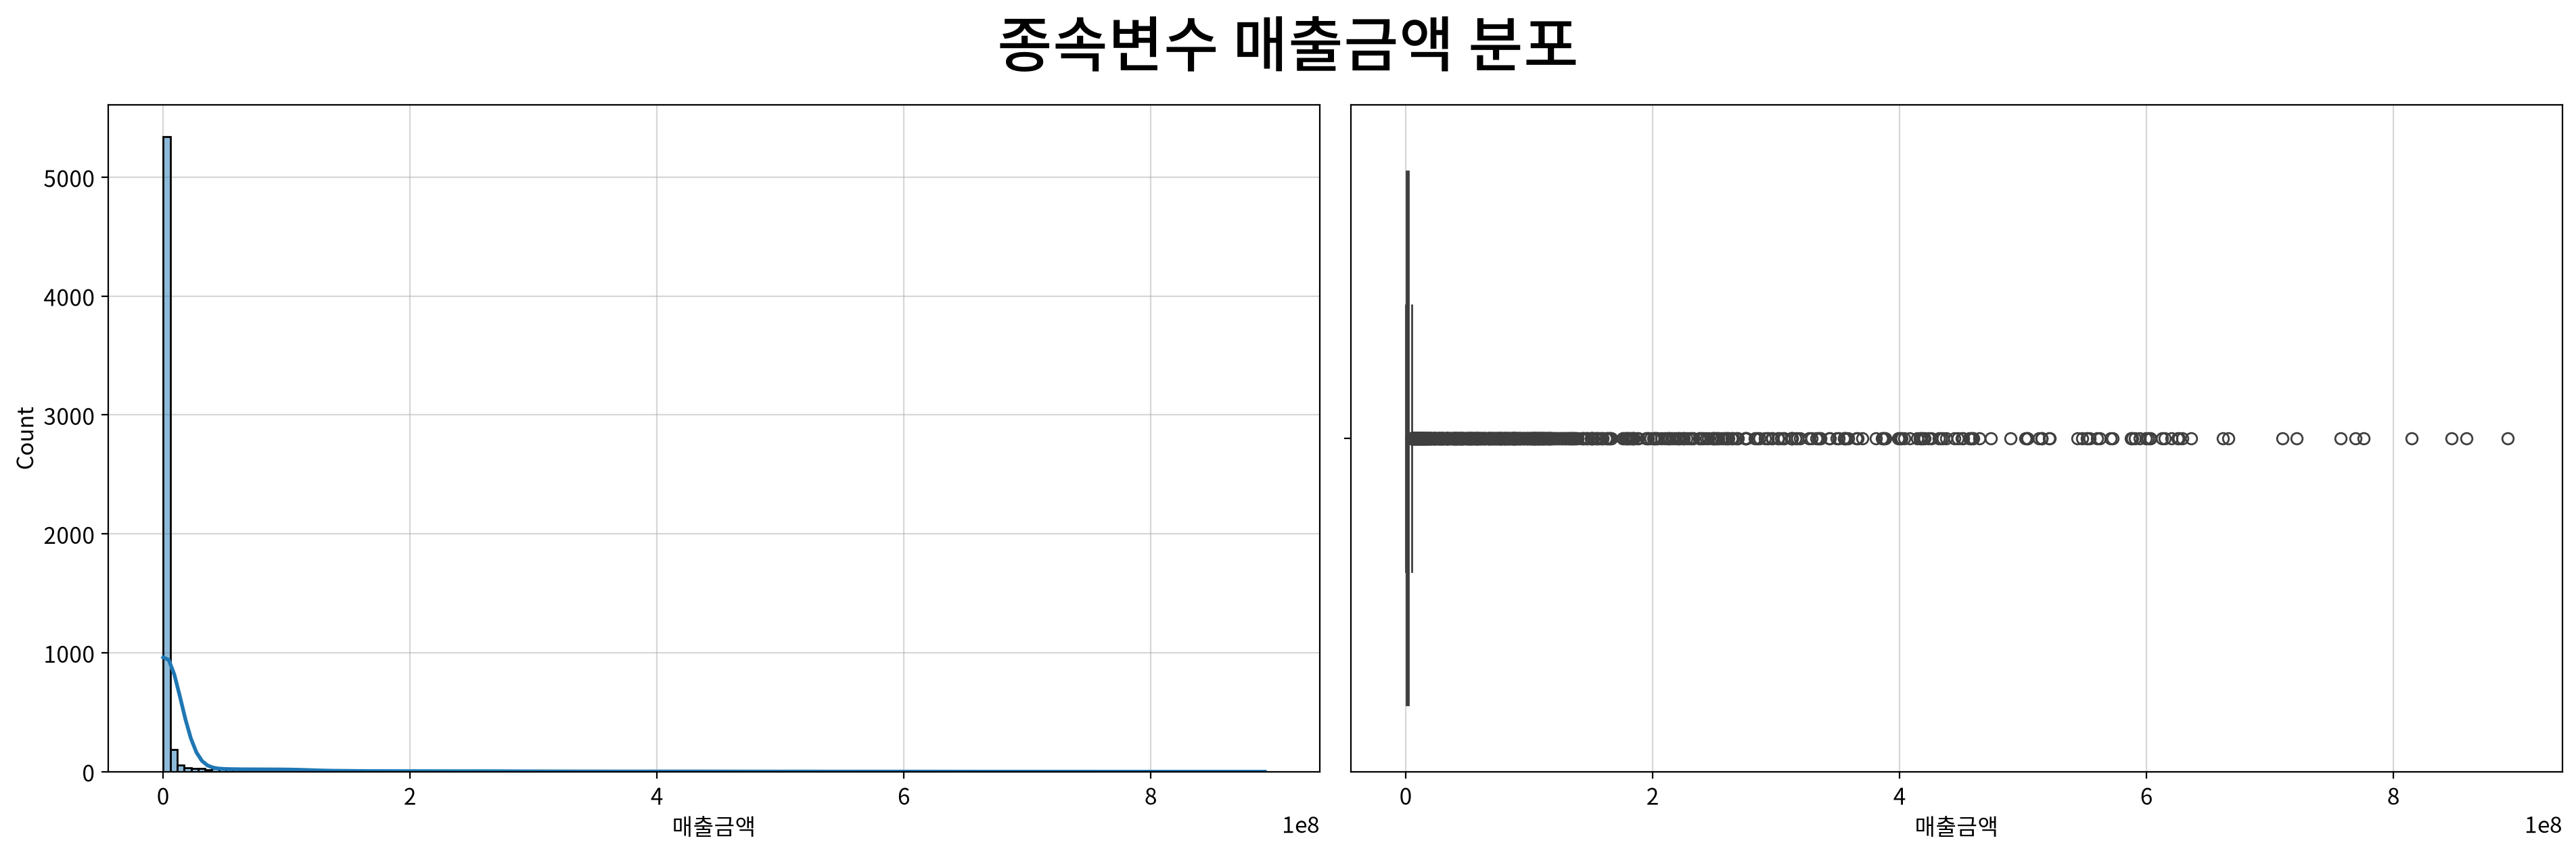

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


In [64]:
# 02. 단변량 분석
# 1. 연속형 종속변수에 대한 단변량 분석
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df3, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df3, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

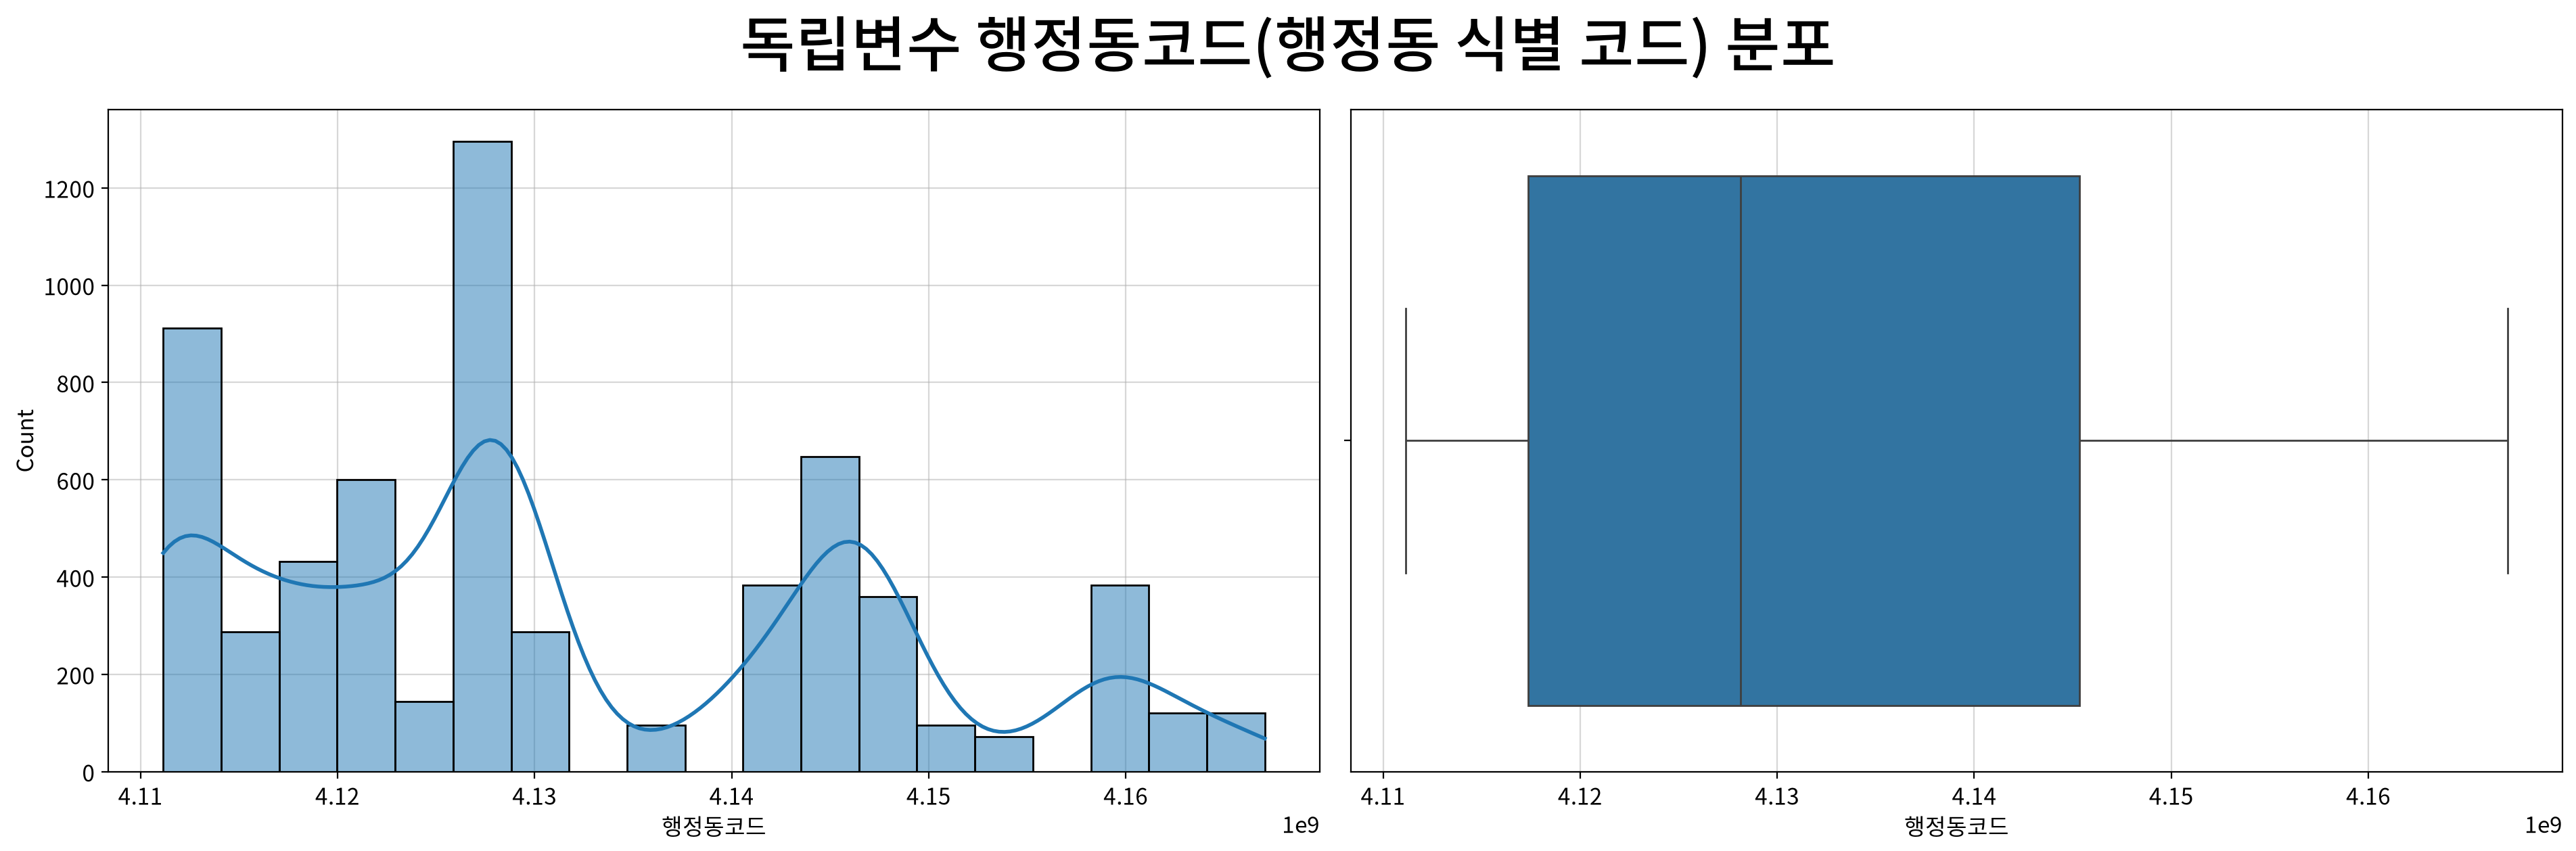

,행정동코드
count,6240
mean,4131567895.384615
std,15590848.095135
min,4111156000.0
25%,4117358750.0
50%,4128157000.0
75%,4145334250.0
max,4167053000.0
rel_diff,0.000826
rdiff_flag,similar


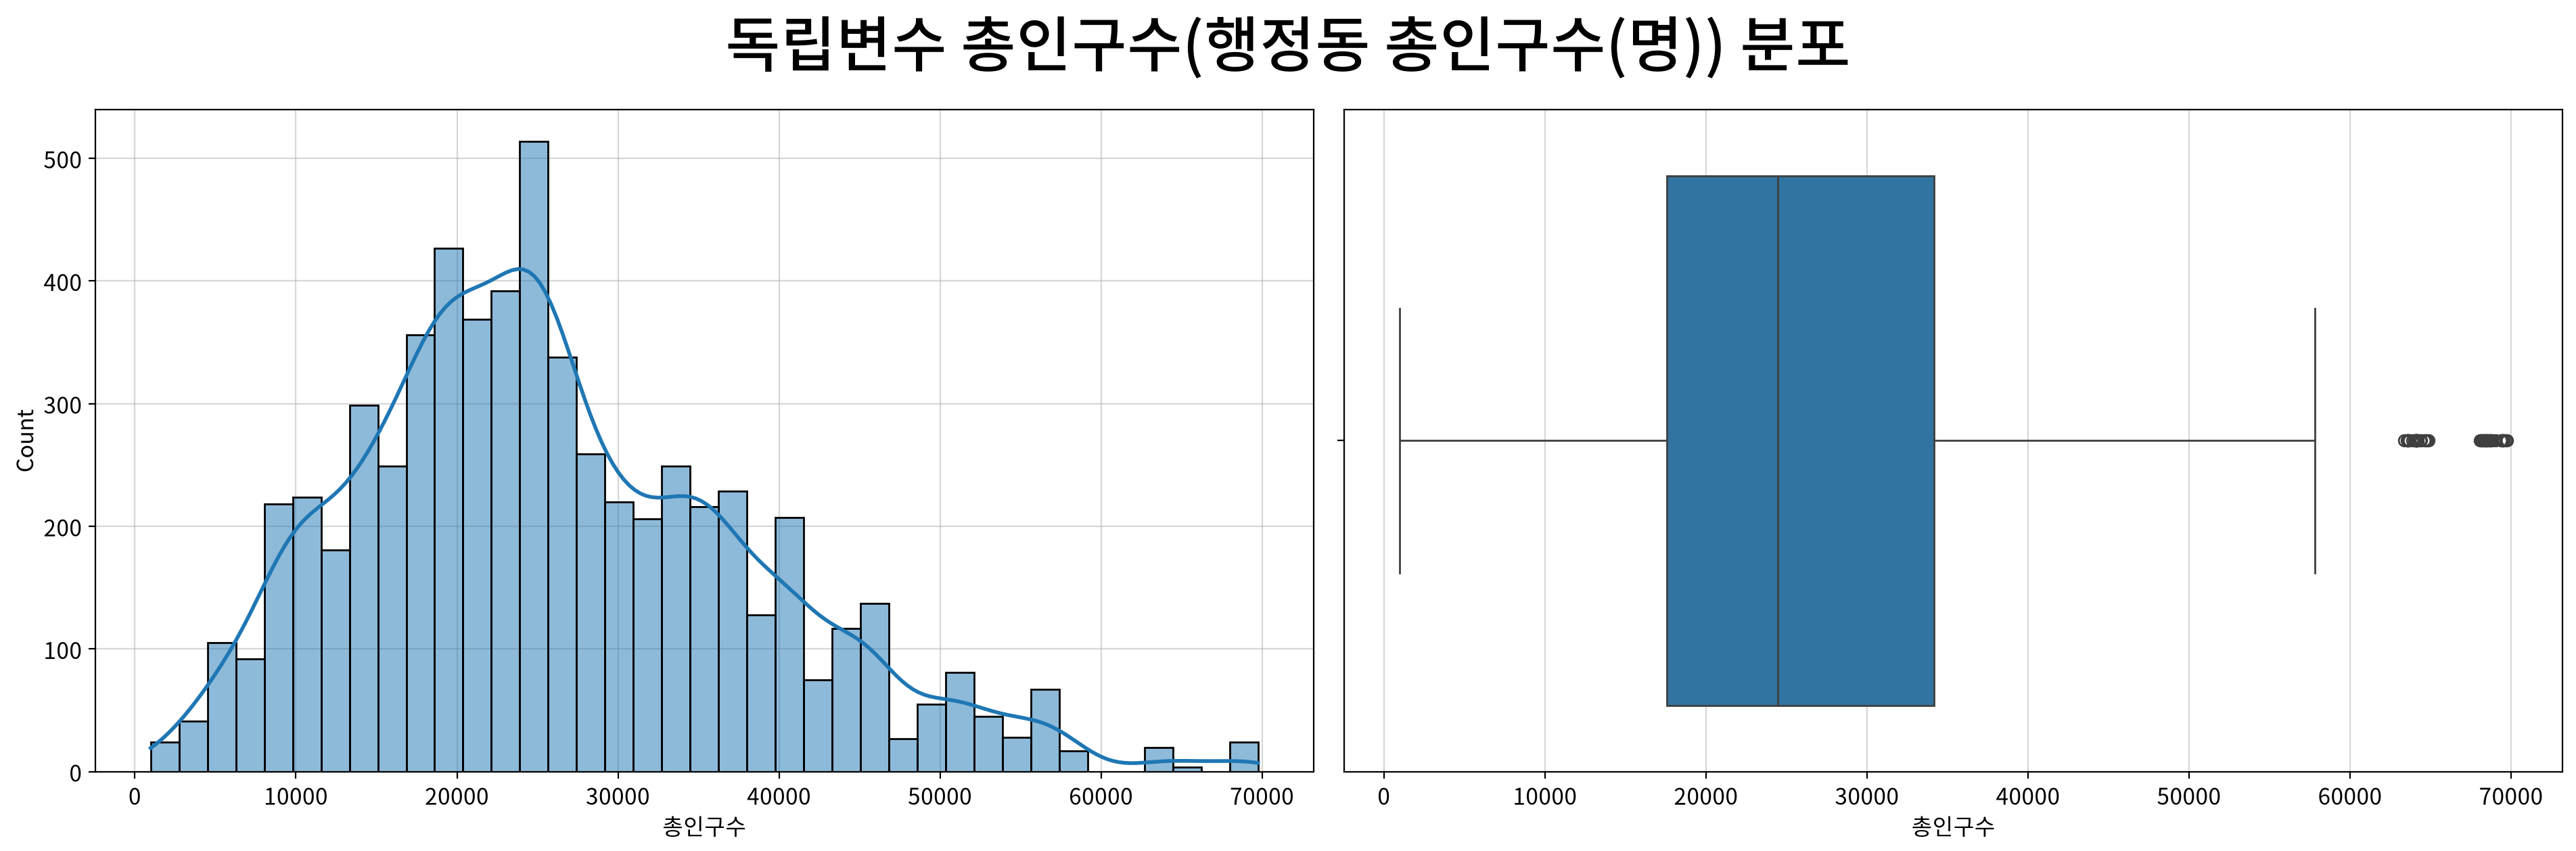

,총인구수
count,6240
mean,26059.542468
std,12320.289688
min,978.0
25%,17583.5
50%,24476.0
75%,34141.5
max,69751.0
rel_diff,0.064698
rdiff_flag,similar


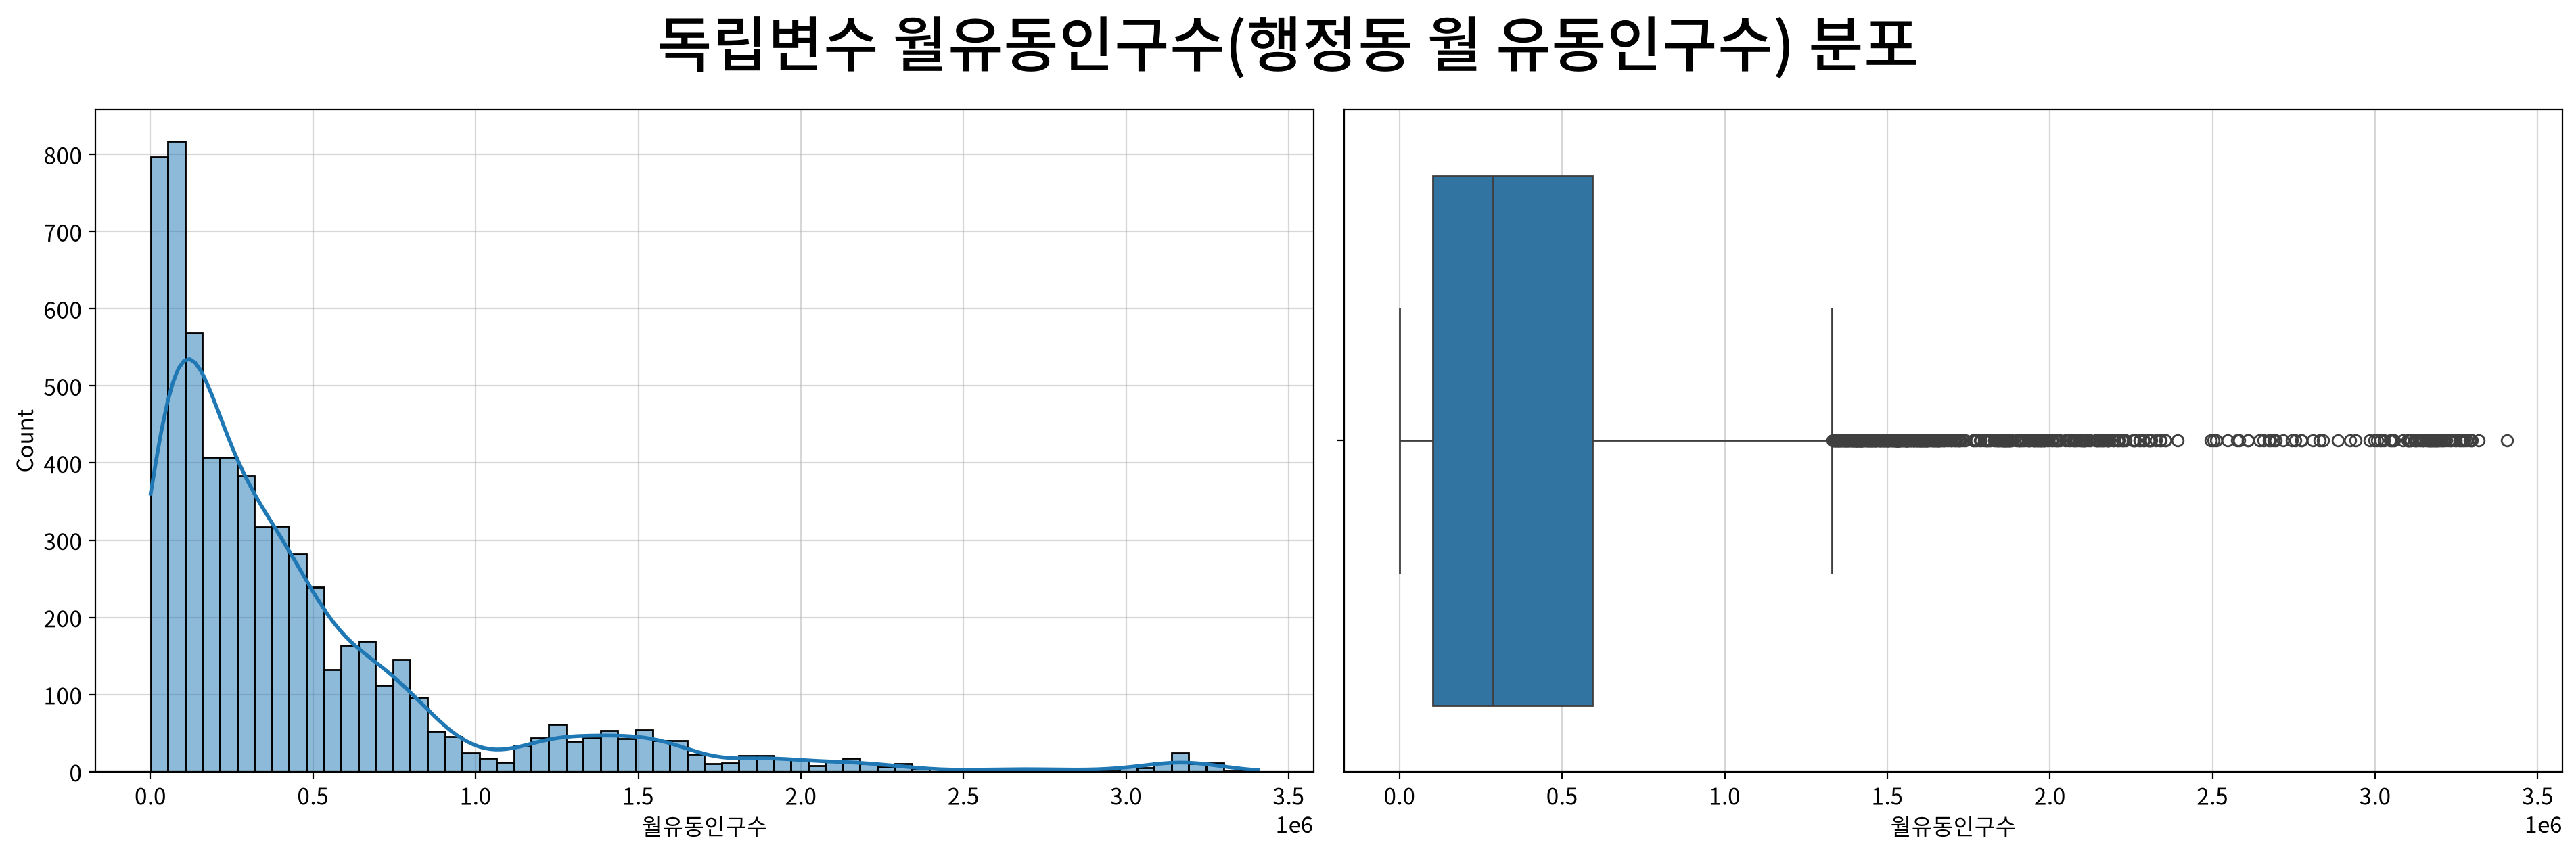

,월유동인구수
count,6240
mean,468258.3433
std,557773.449512
min,511.86
25%,102517.29
50%,286276.045
75%,593990.425
max,3405776.5
rel_diff,0.635688
rdiff_flag,large_diff


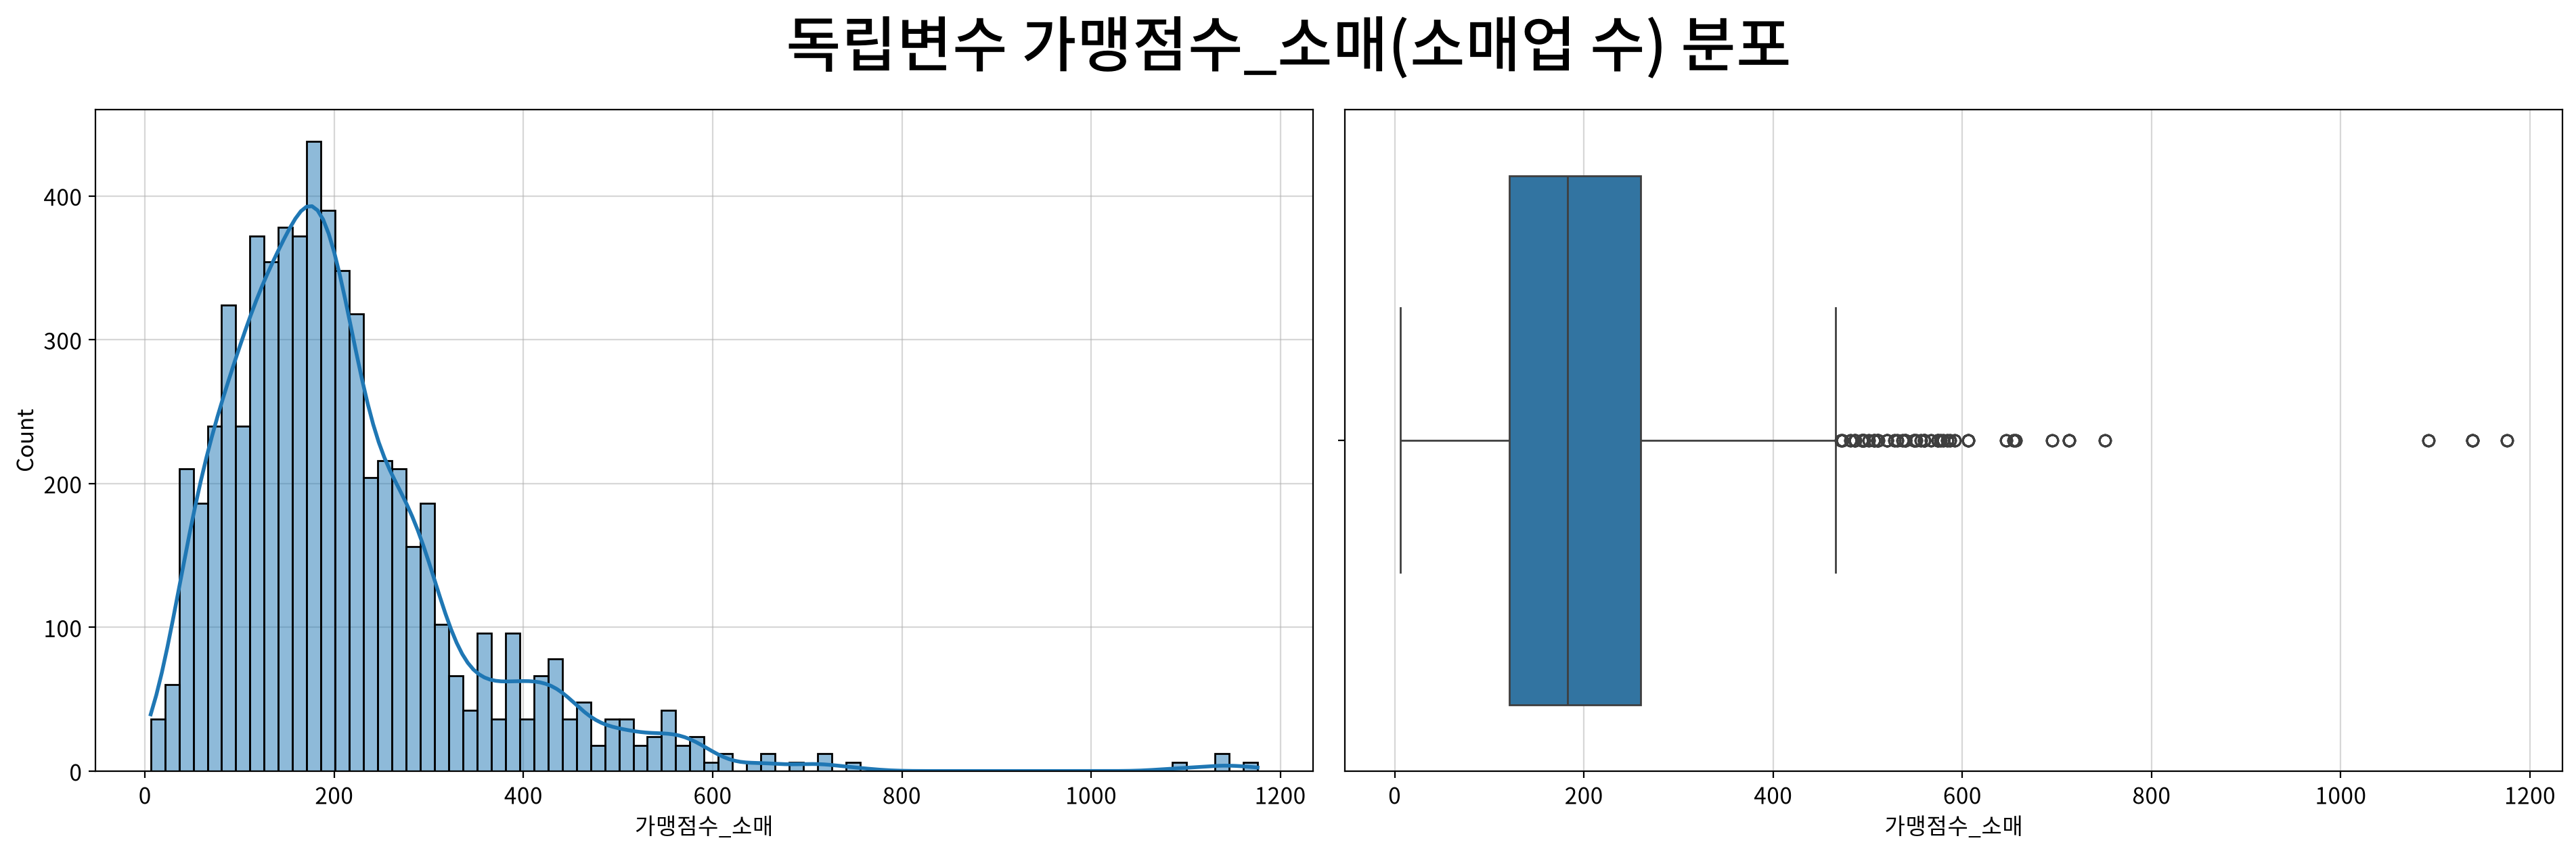

,가맹점수_소매
count,6240
mean,209.217308
std,135.586095
min,6.0
25%,121.0
50%,182.5
75%,260.0
max,1176.0
rel_diff,0.146396
rdiff_flag,diff


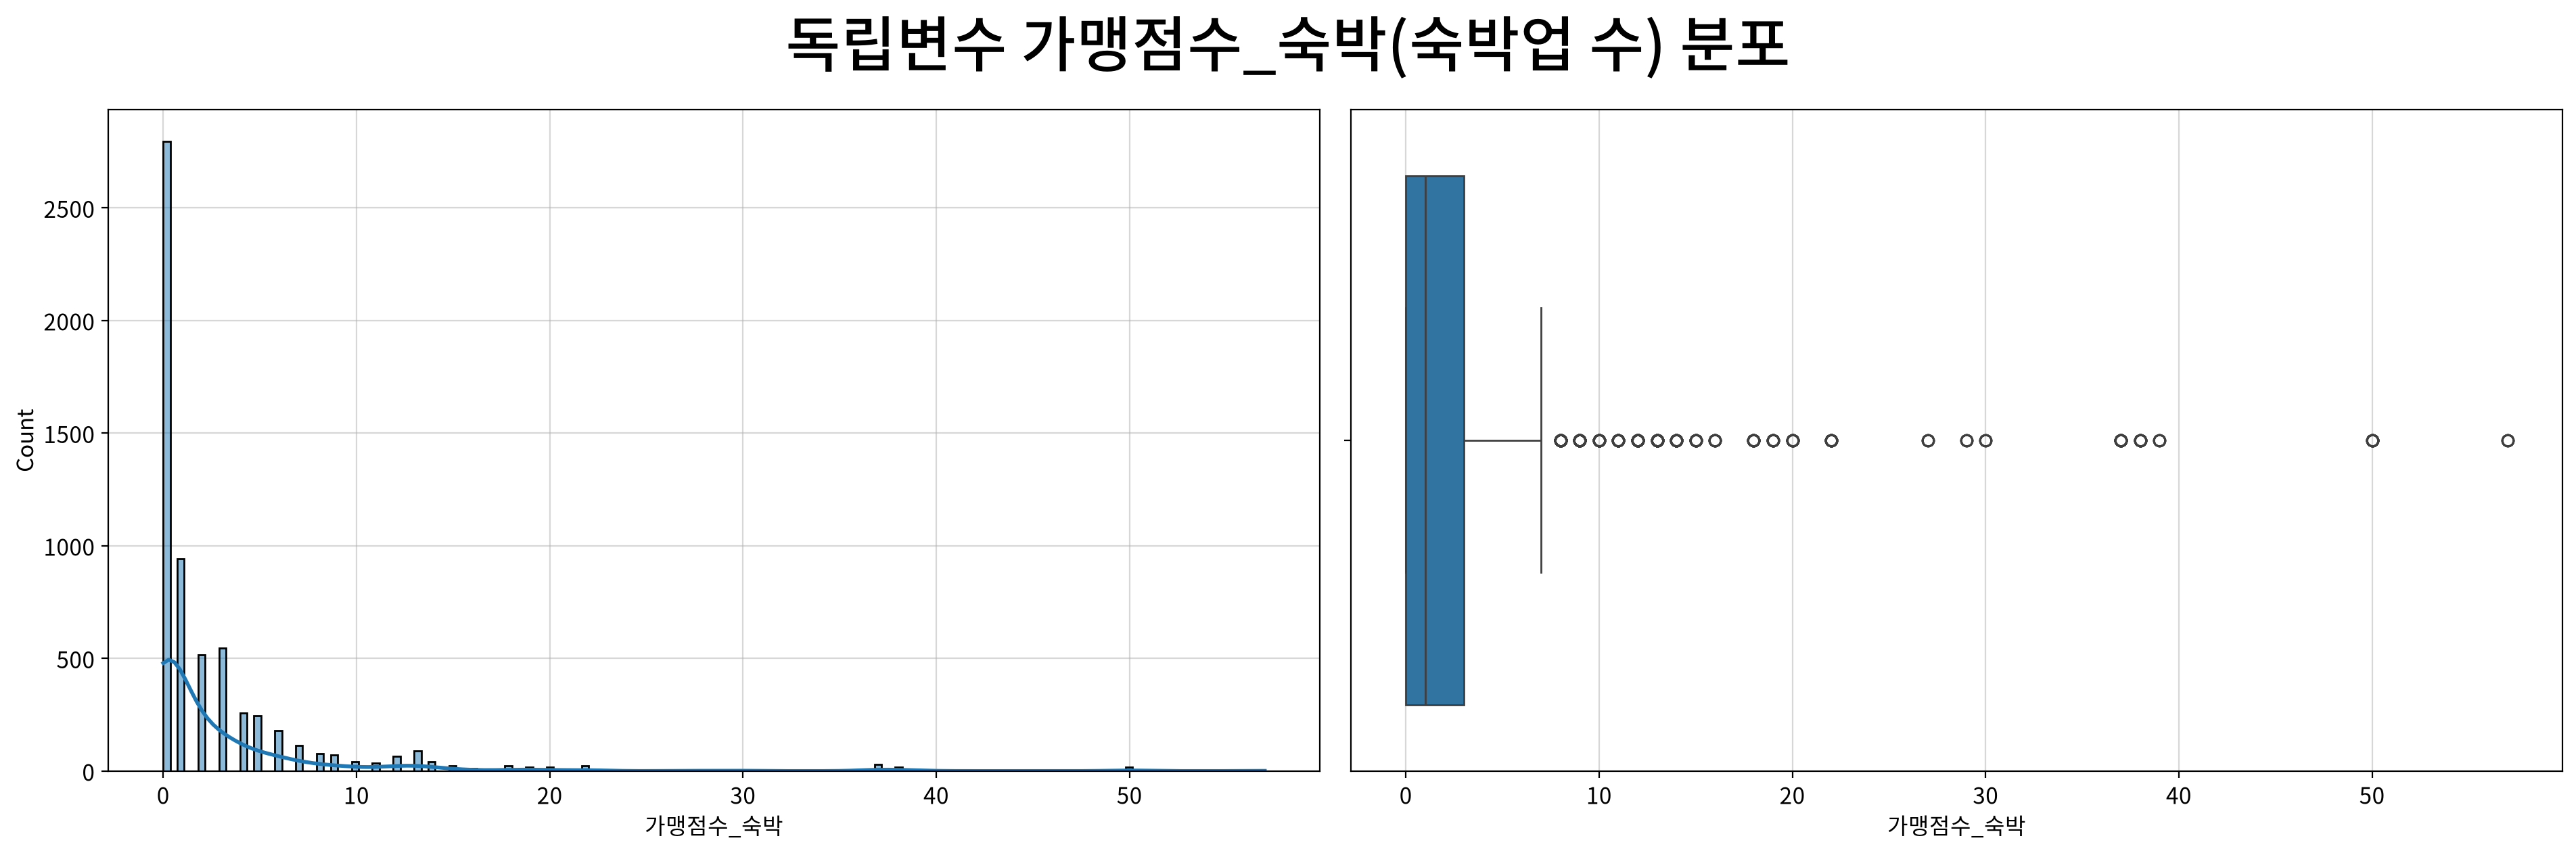

,가맹점수_숙박
count,6240
mean,2.947115
std,6.011377
min,0.0
25%,0.0
50%,1.0
75%,3.0
max,57.0
rel_diff,1.947115
rdiff_flag,large_diff


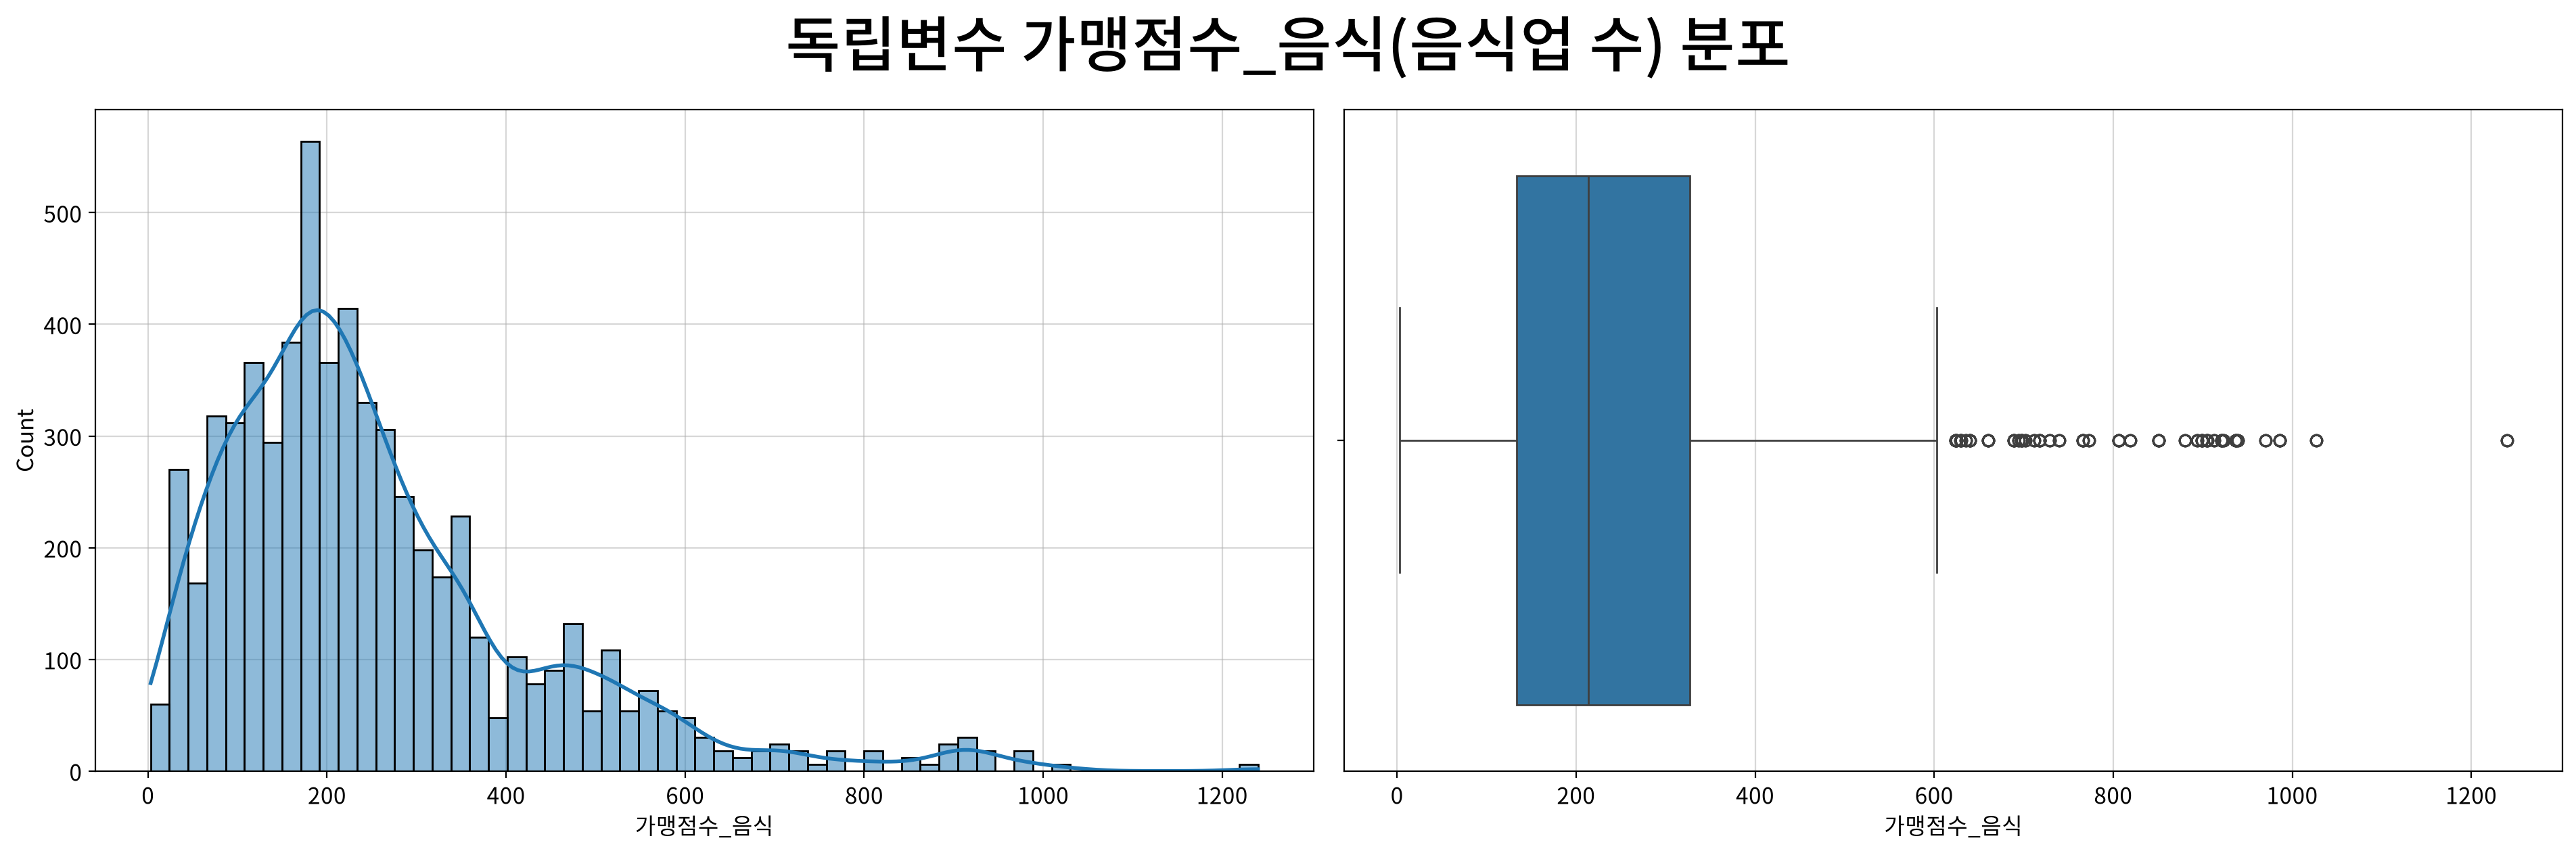

,가맹점수_음식
count,6240
mean,255.900962
std,180.953453
min,3.0
25%,133.75
50%,214.0
75%,327.25
max,1240.0
rel_diff,0.195799
rdiff_flag,diff


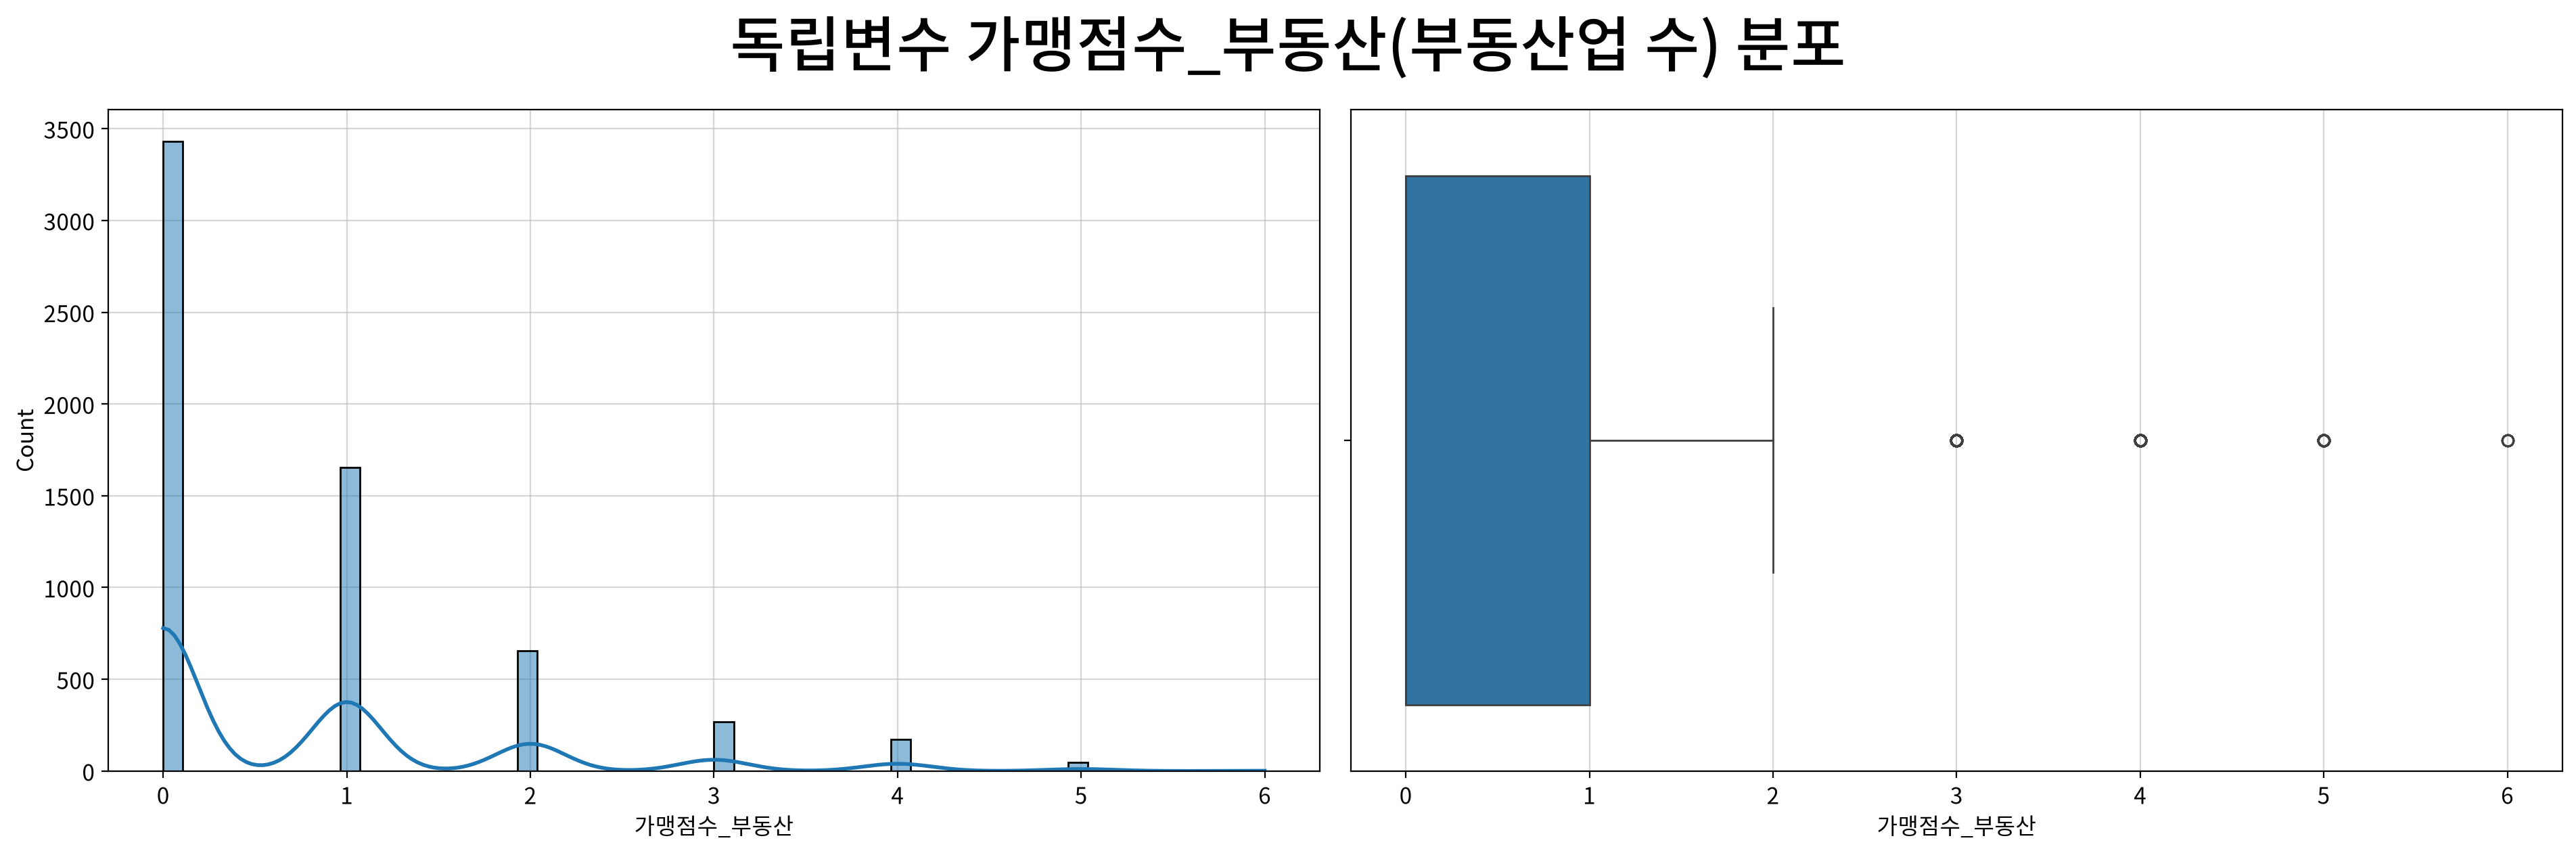

,가맹점수_부동산
count,6240
mean,0.760577
std,1.081122
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,6.0
rel_diff,inf
rdiff_flag,large_diff


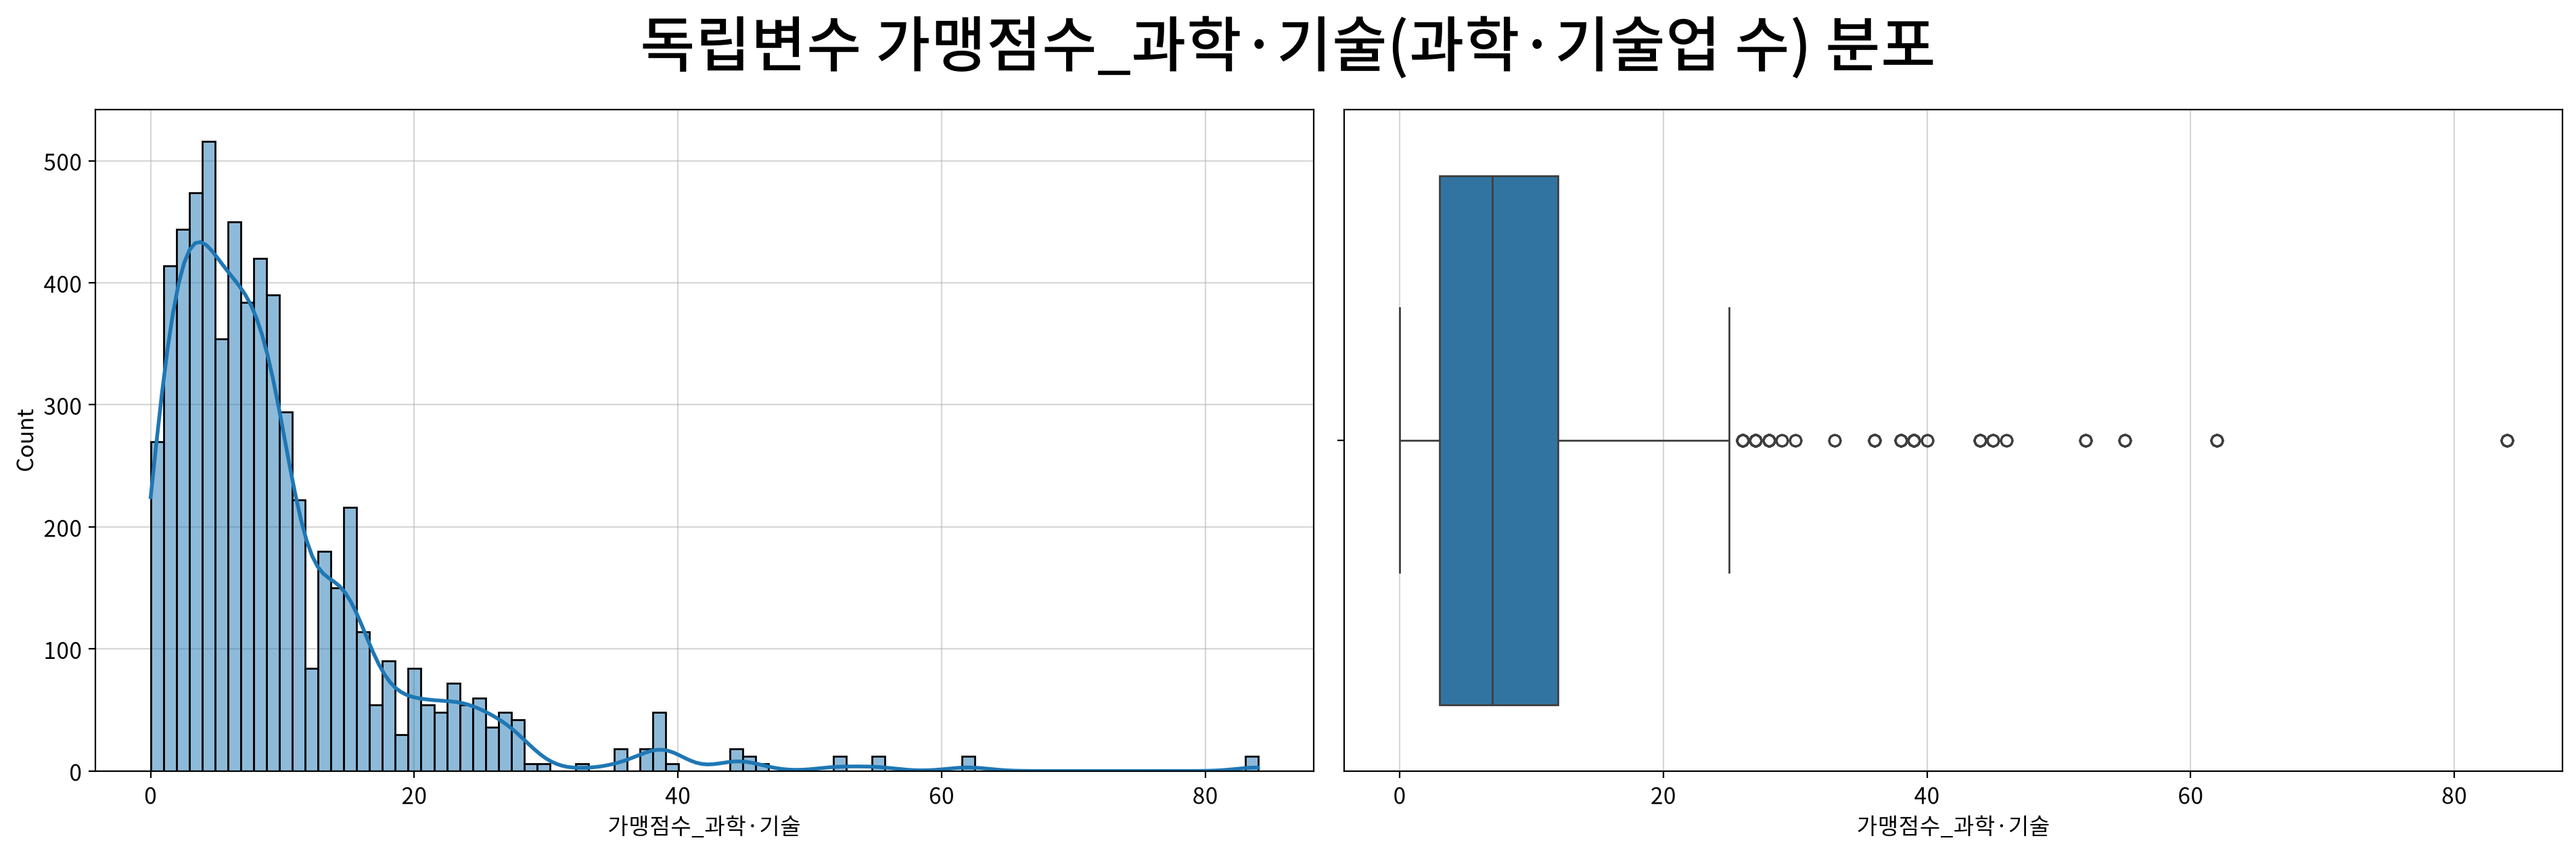

,가맹점수_과학·기술
count,6240
mean,9.325
std,9.267938
min,0.0
25%,3.0
50%,7.0
75%,12.0
max,84.0
rel_diff,0.332143
rdiff_flag,diff


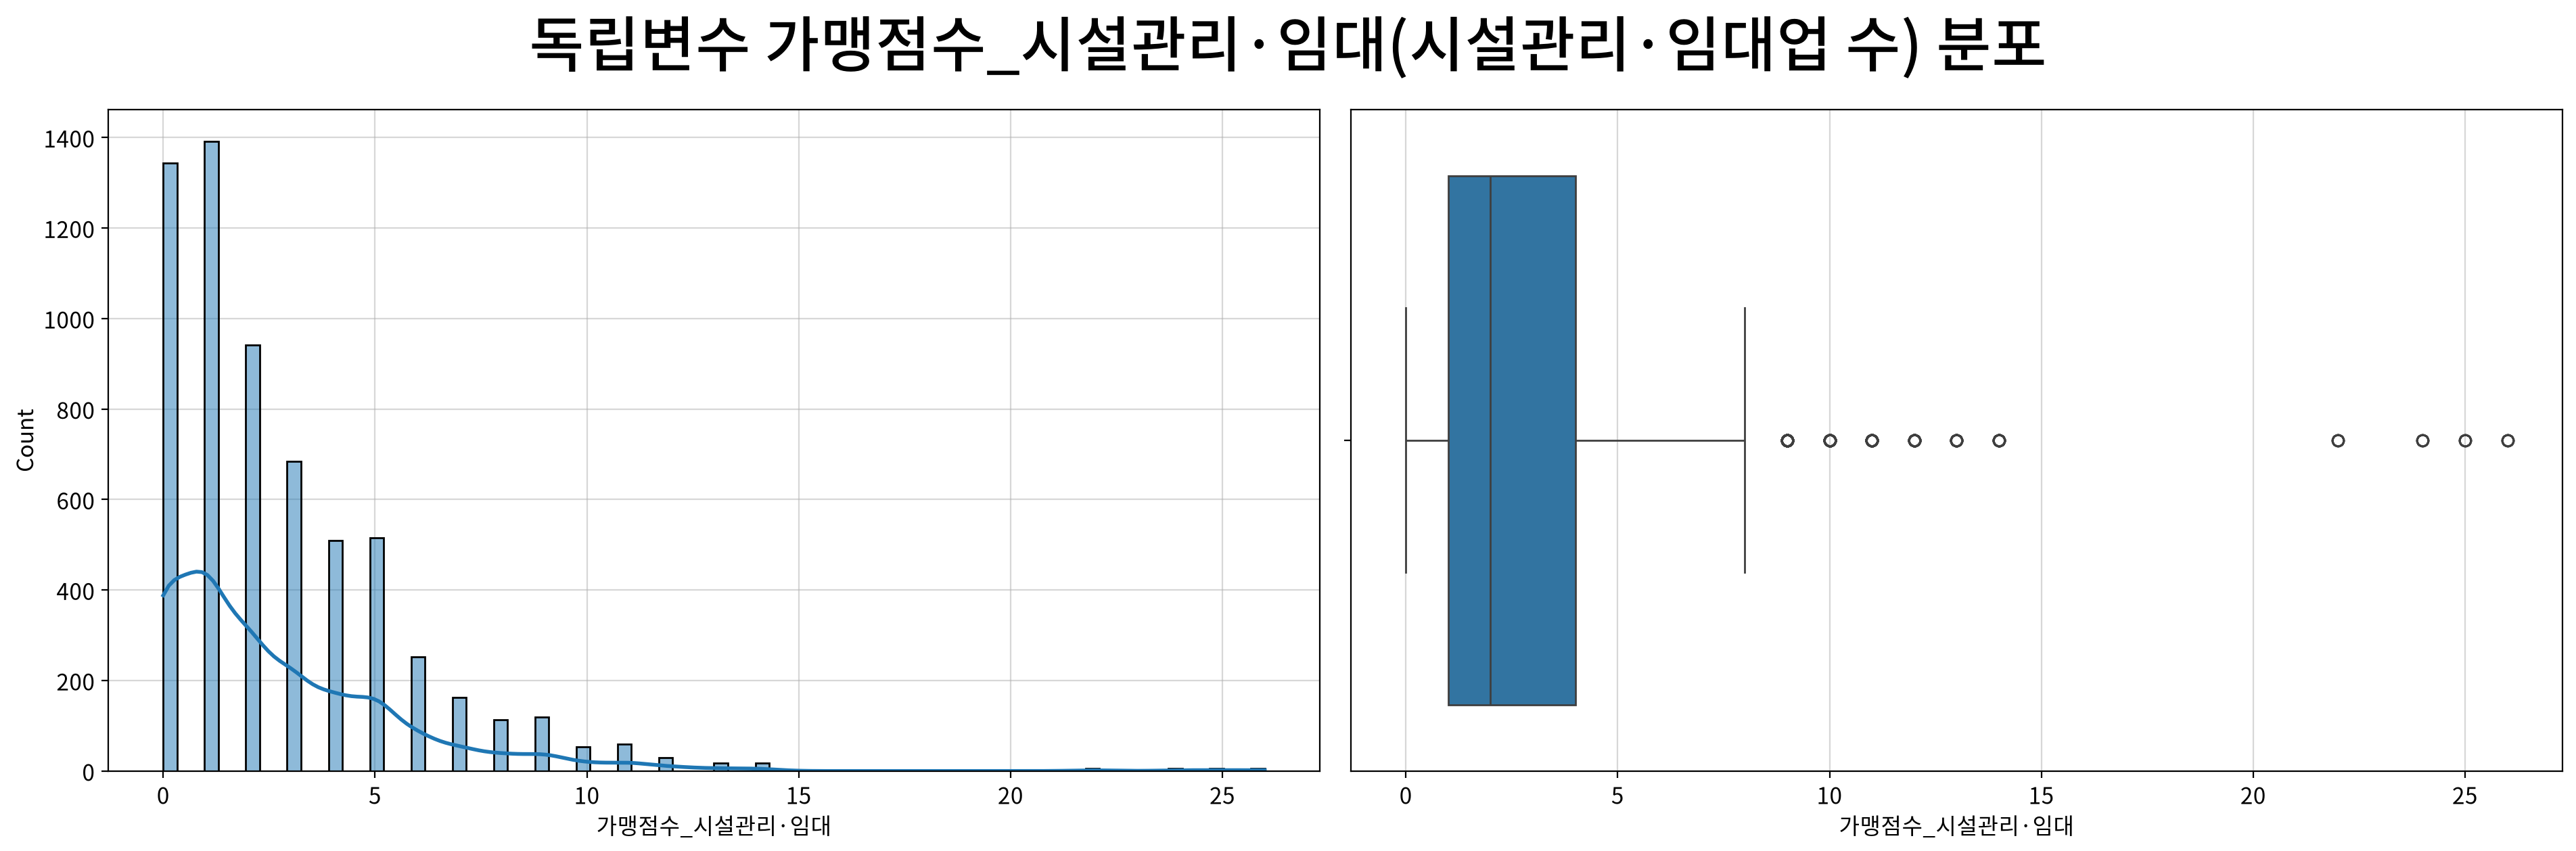

,가맹점수_시설관리·임대
count,6240
mean,2.758654
std,3.012783
min,0.0
25%,1.0
50%,2.0
75%,4.0
max,26.0
rel_diff,0.379327
rdiff_flag,diff


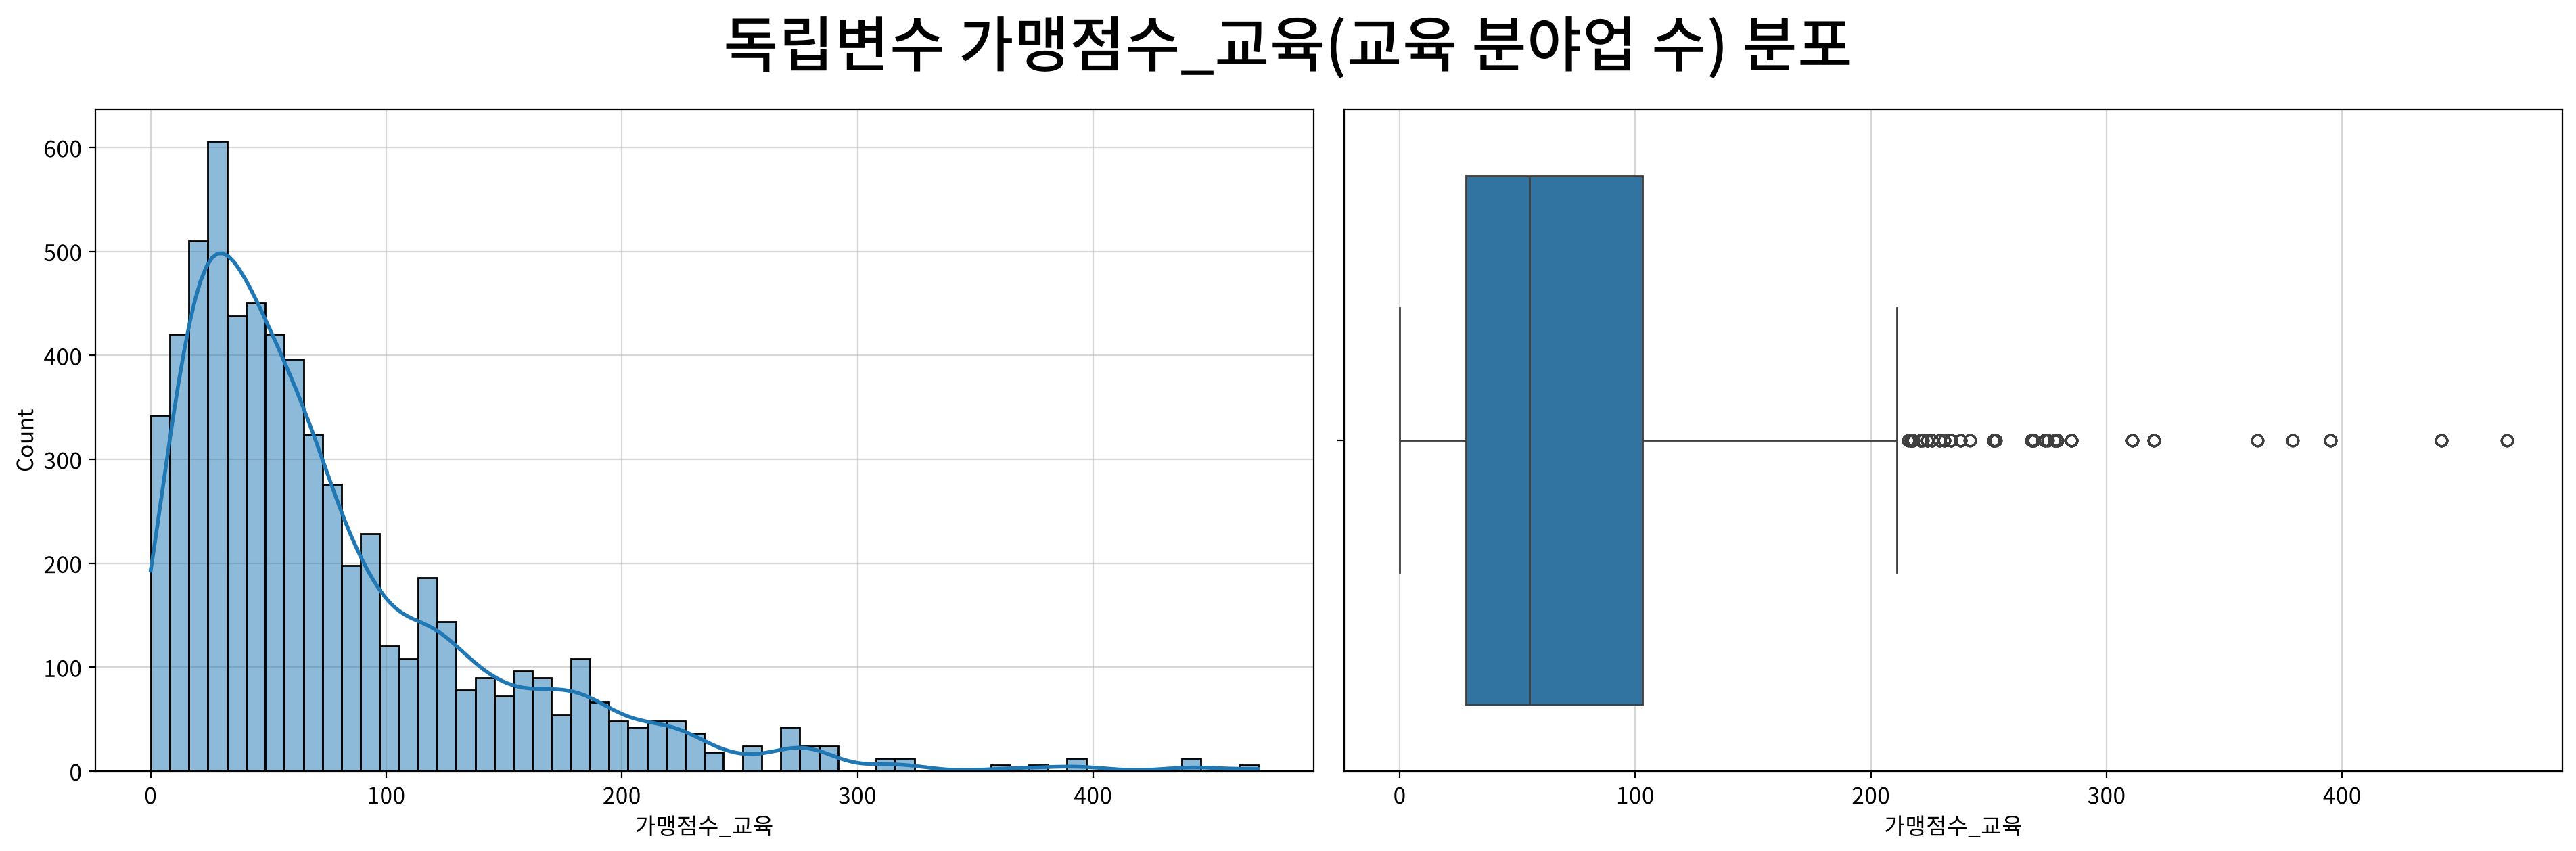

,가맹점수_교육
count,6240
mean,76.174038
std,68.417115
min,0.0
25%,28.0
50%,55.0
75%,103.0
max,470.0
rel_diff,0.384983
rdiff_flag,diff


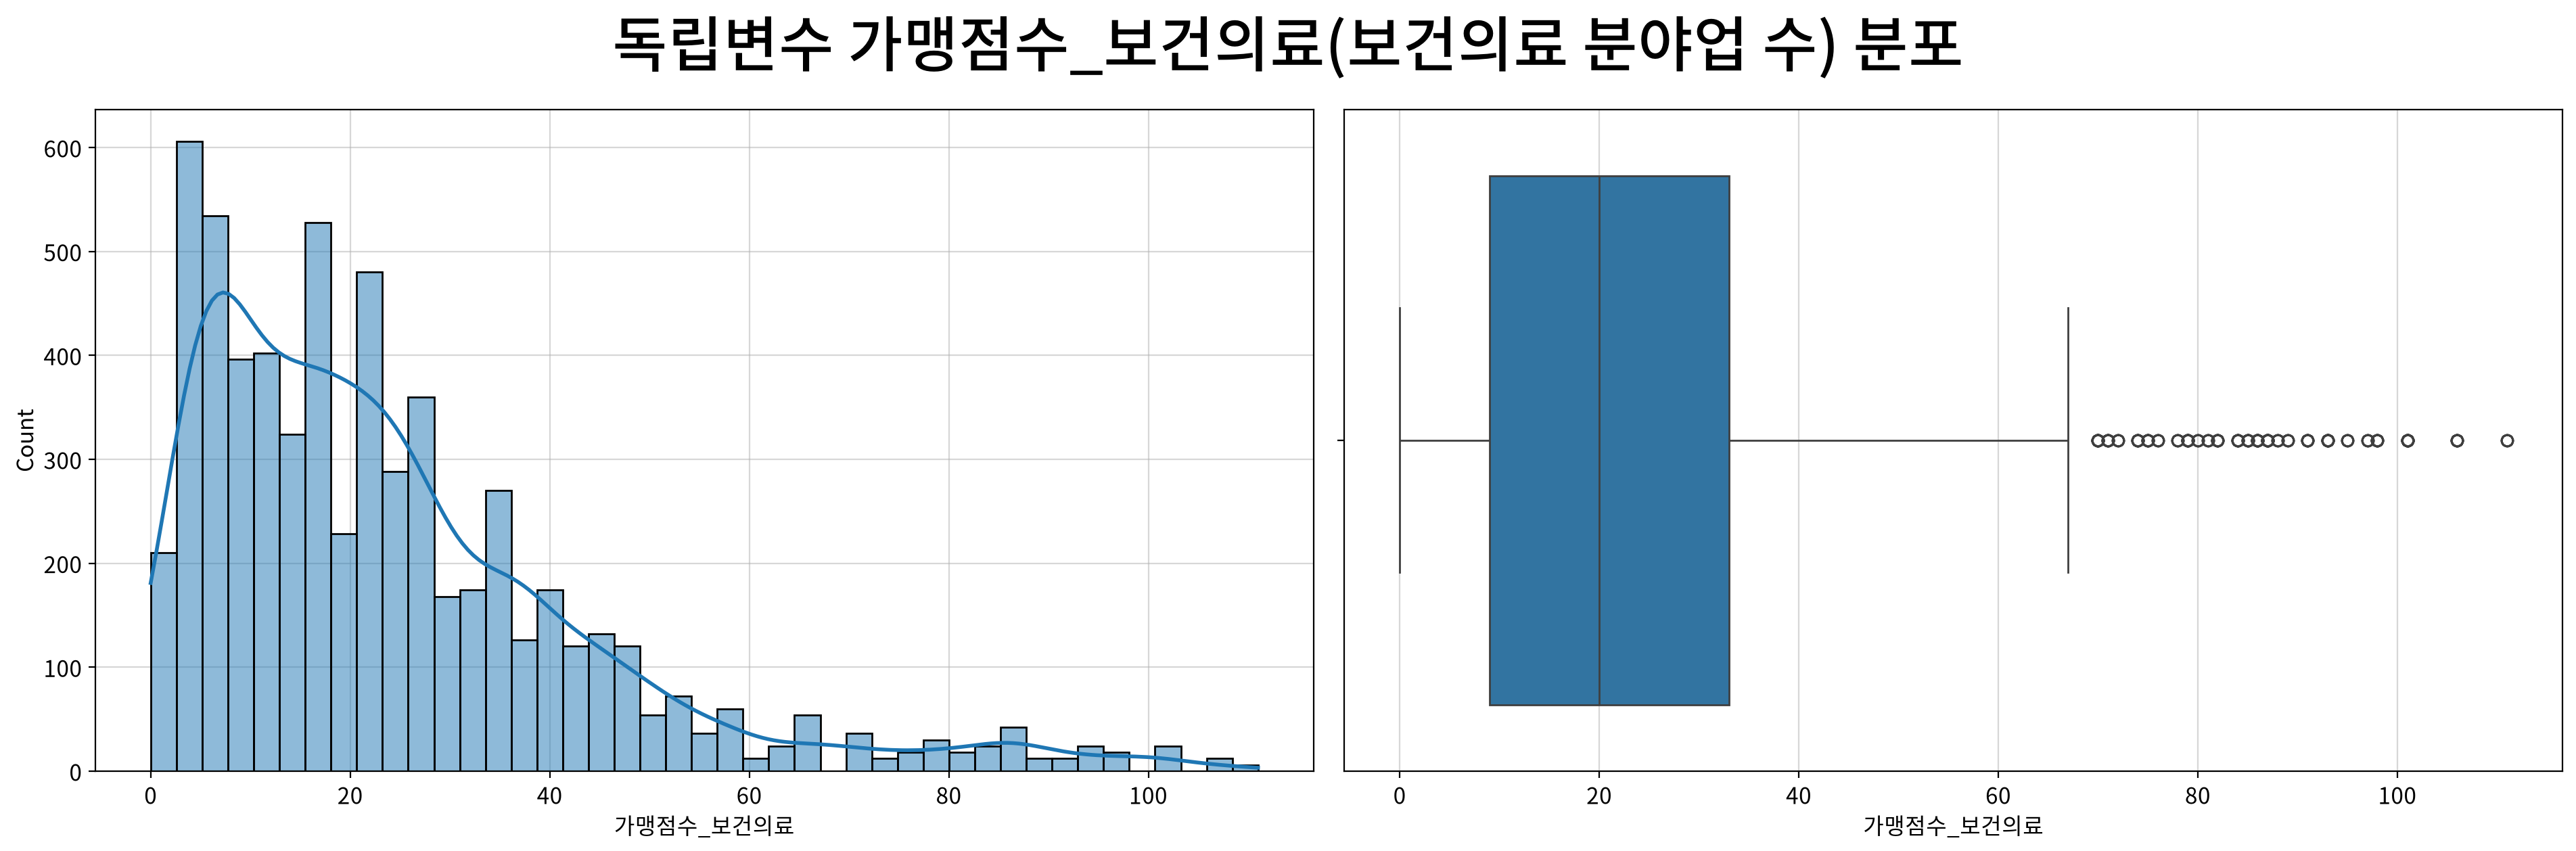

,가맹점수_보건의료
count,6240
mean,24.150962
std,20.087849
min,0.0
25%,9.0
50%,20.0
75%,33.0
max,111.0
rel_diff,0.207548
rdiff_flag,diff


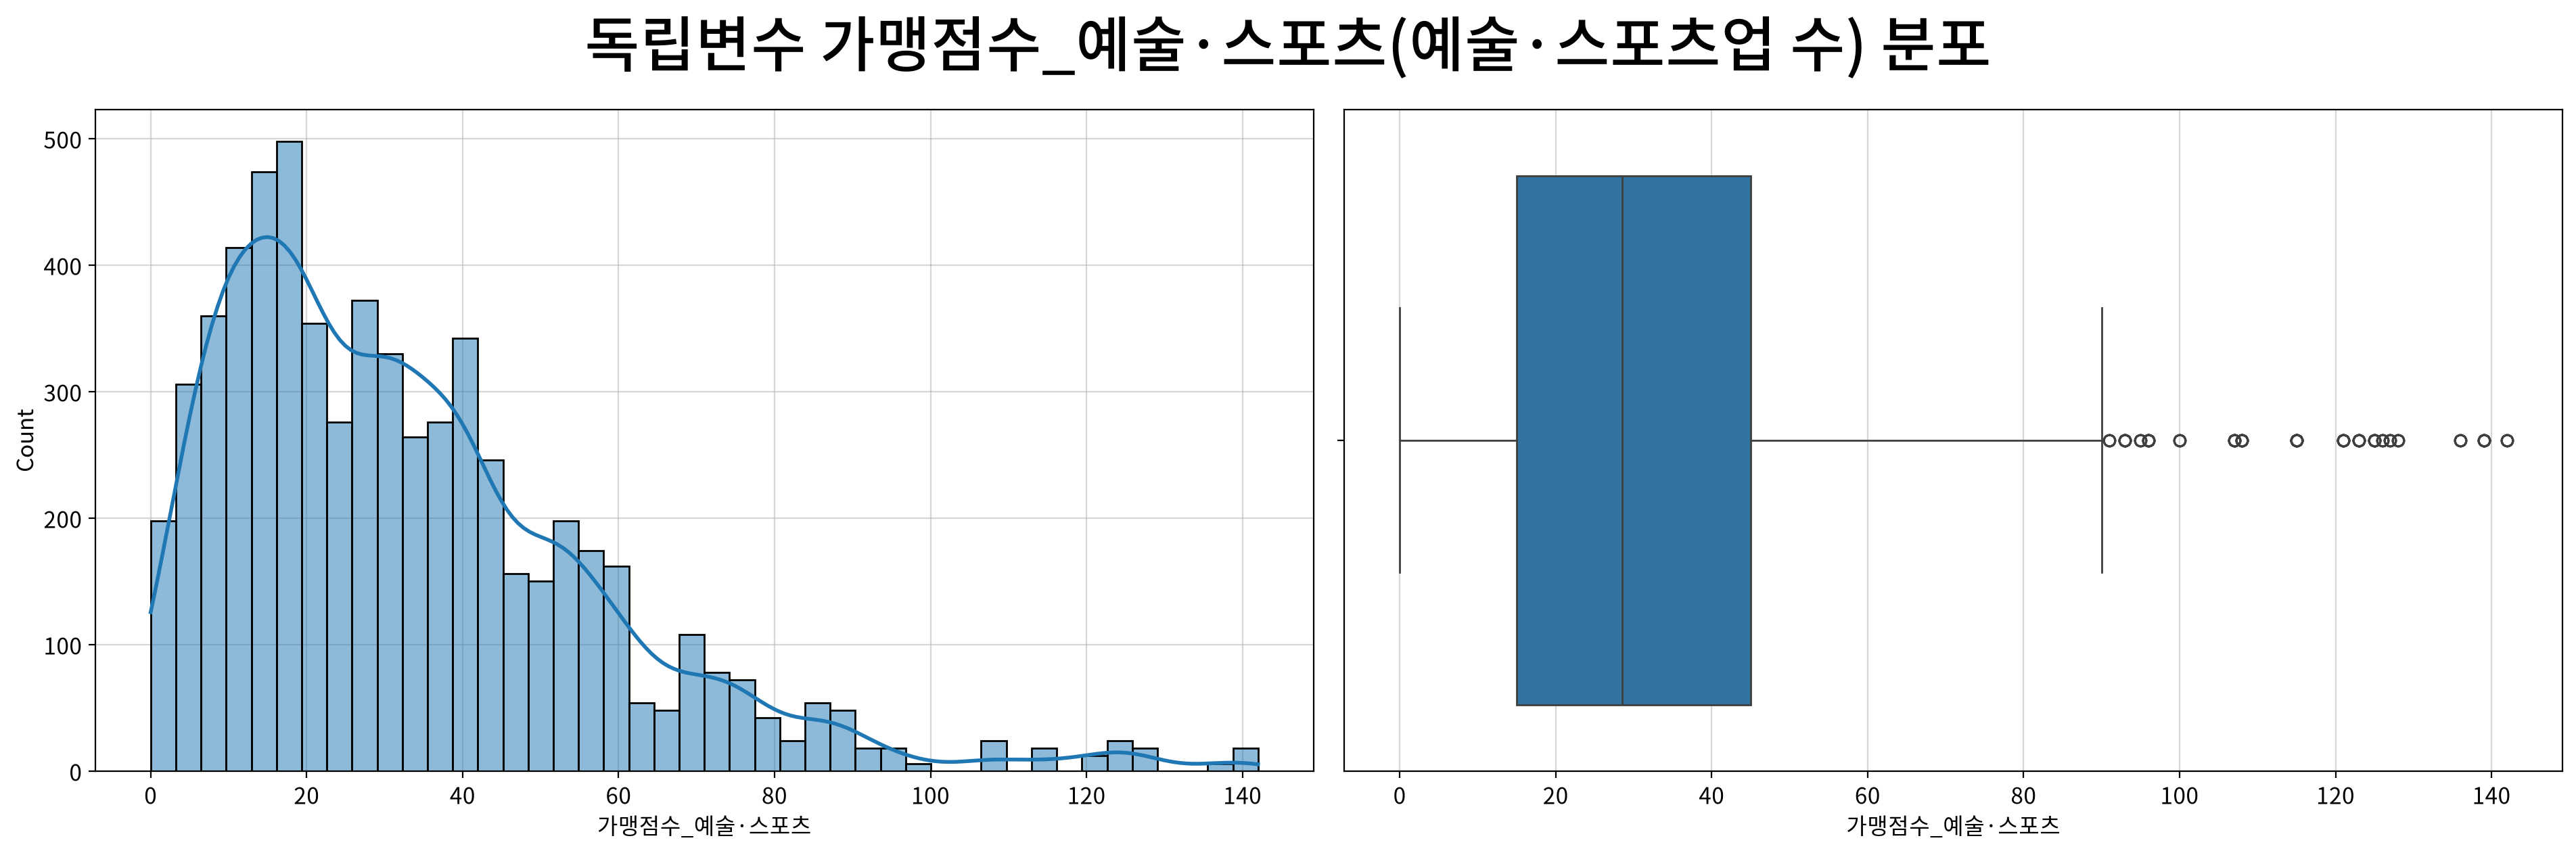

,가맹점수_예술·스포츠
count,6240
mean,33.043269
std,24.4065
min,0.0
25%,15.0
50%,28.5
75%,45.0
max,142.0
rel_diff,0.159413
rdiff_flag,diff


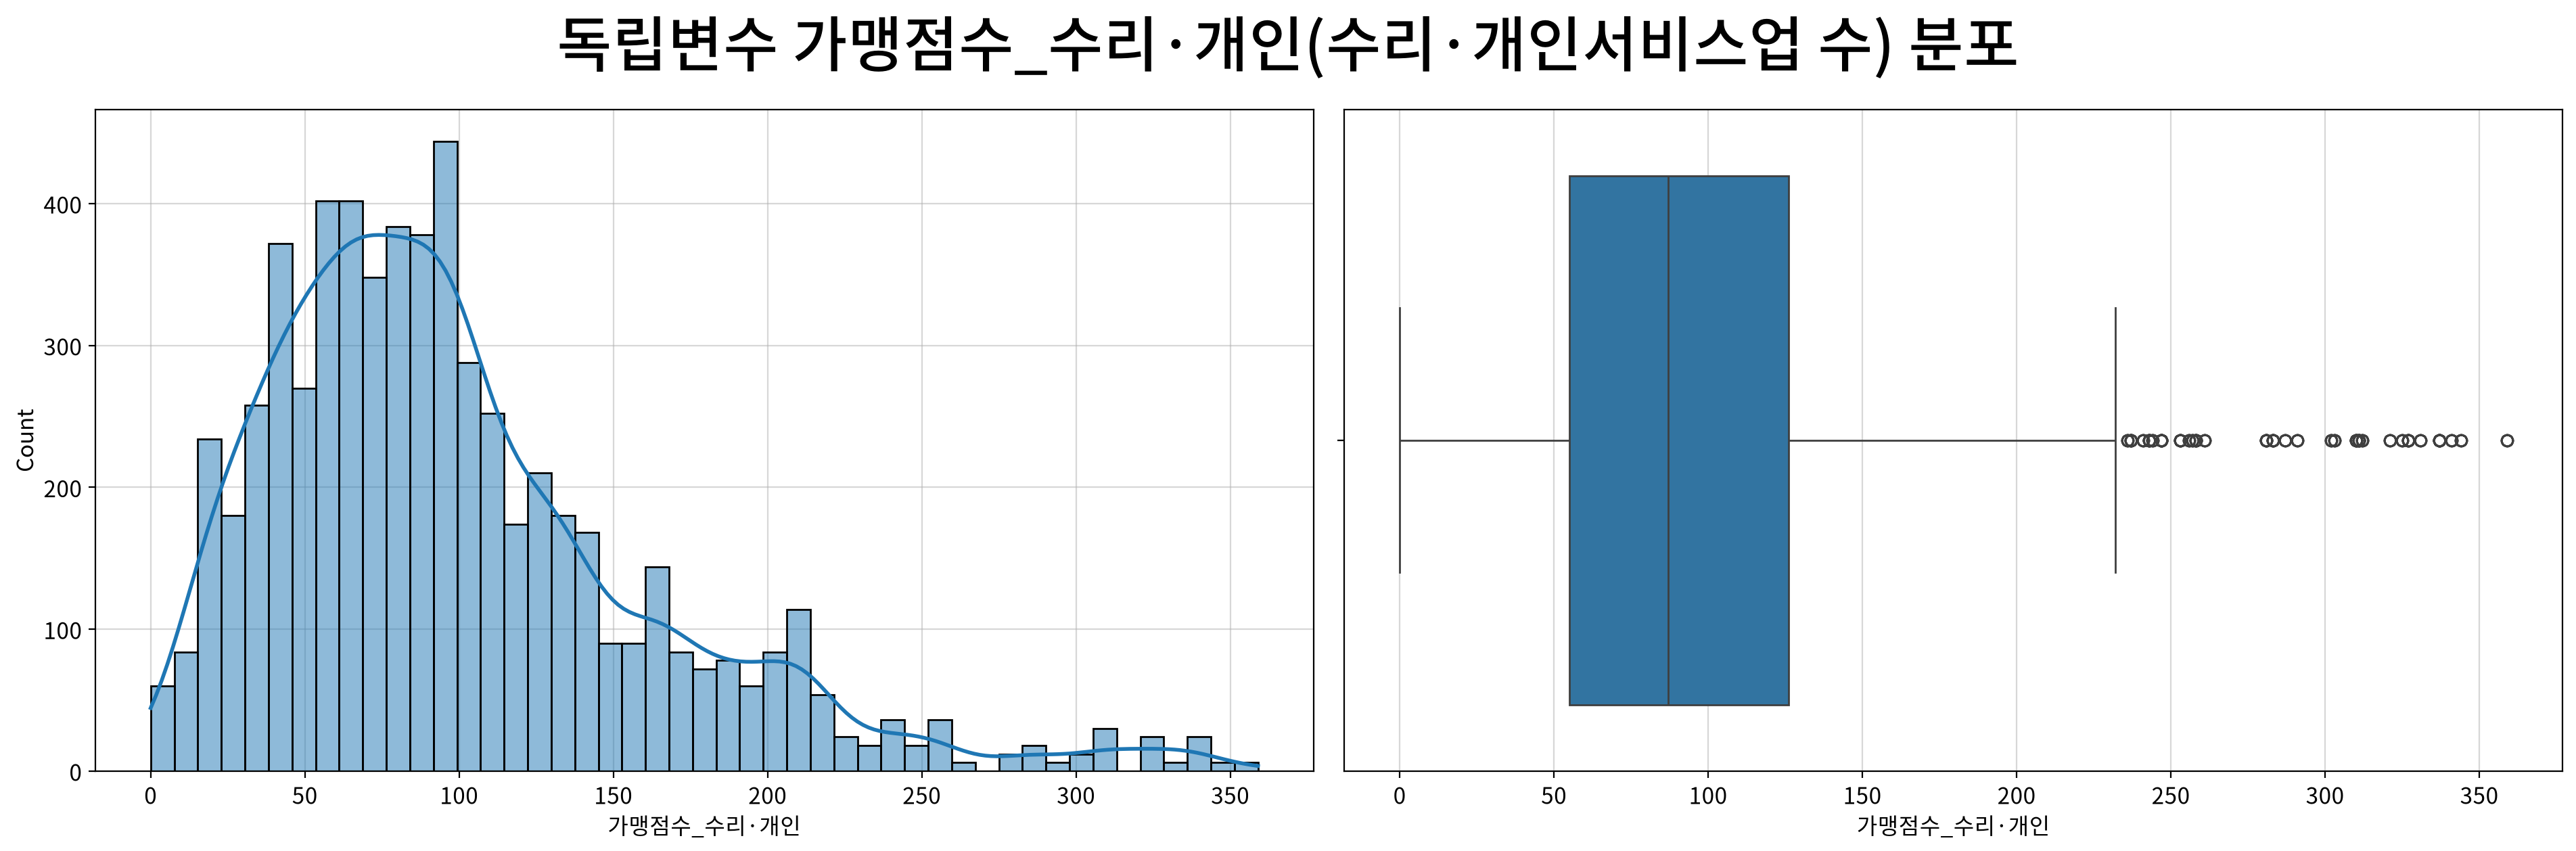

,가맹점수_수리·개인
count,6240
mean,98.939423
std,63.056567
min,0.0
25%,55.0
50%,87.0
75%,126.0
max,359.0
rel_diff,0.137235
rdiff_flag,diff


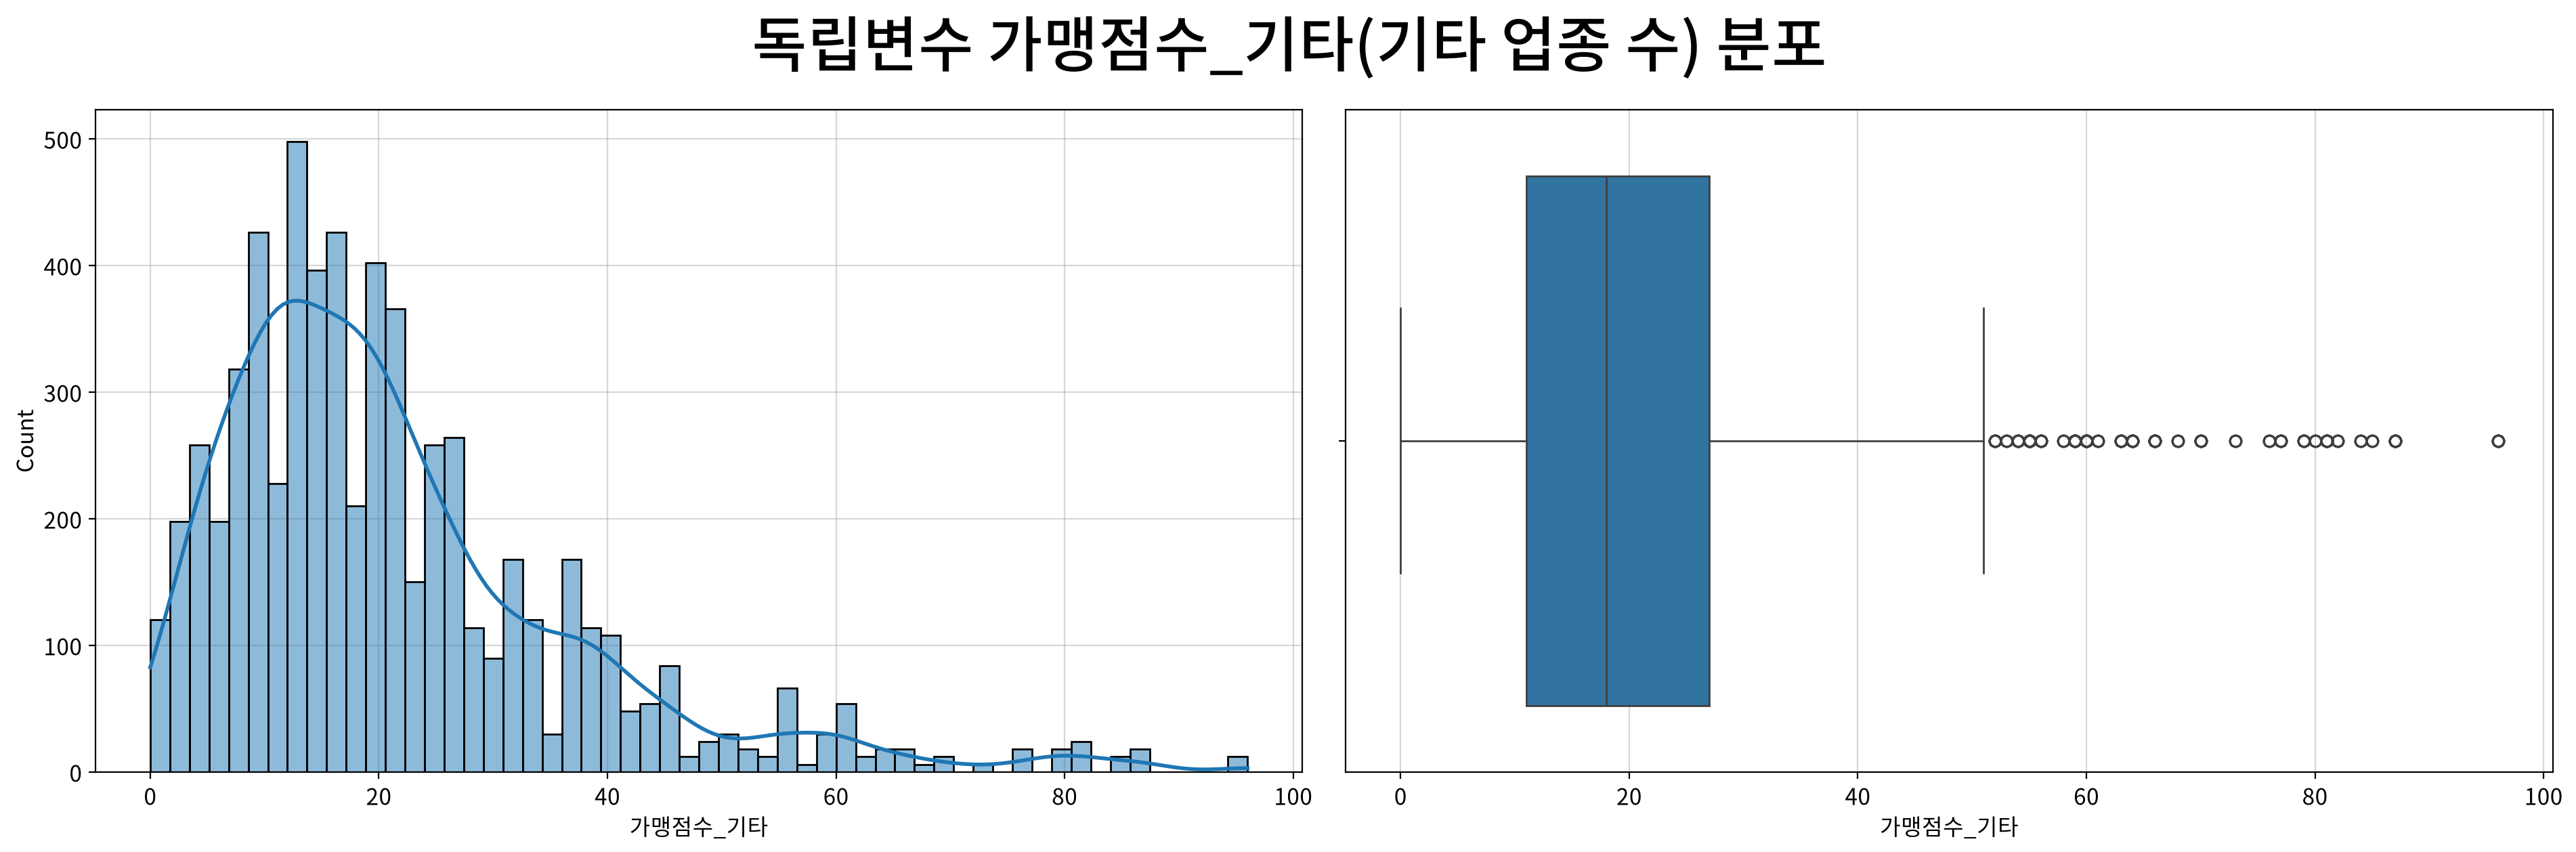

,가맹점수_기타
count,6240
mean,21.418269
std,15.802345
min,0.0
25%,11.0
50%,18.0
75%,27.0
max,96.0
rel_diff,0.189904
rdiff_flag,diff


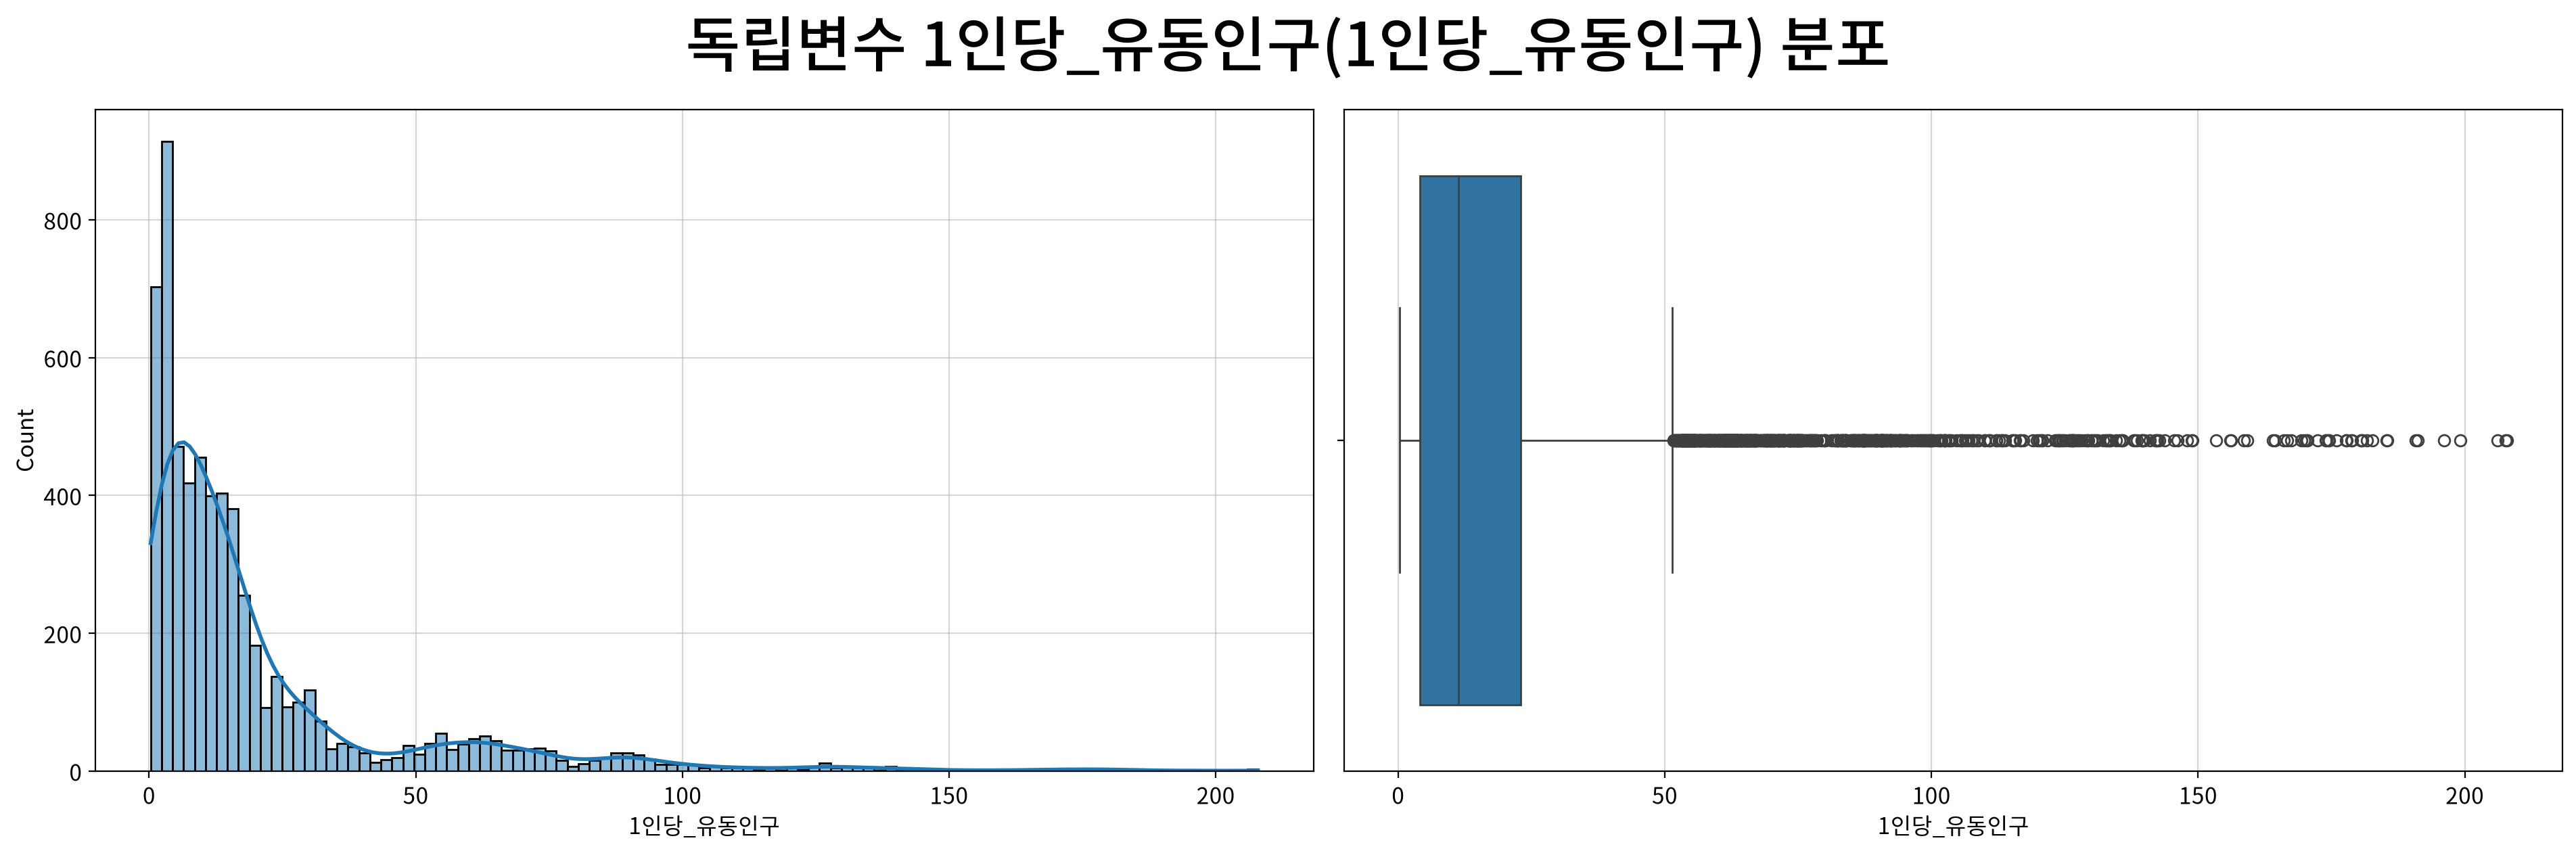

,1인당_유동인구
count,6240
mean,21.090457
std,27.988623
min,0.295707
25%,4.094927
50%,11.372026
75%,23.026481
max,207.92848
rel_diff,0.854591
rdiff_flag,large_diff


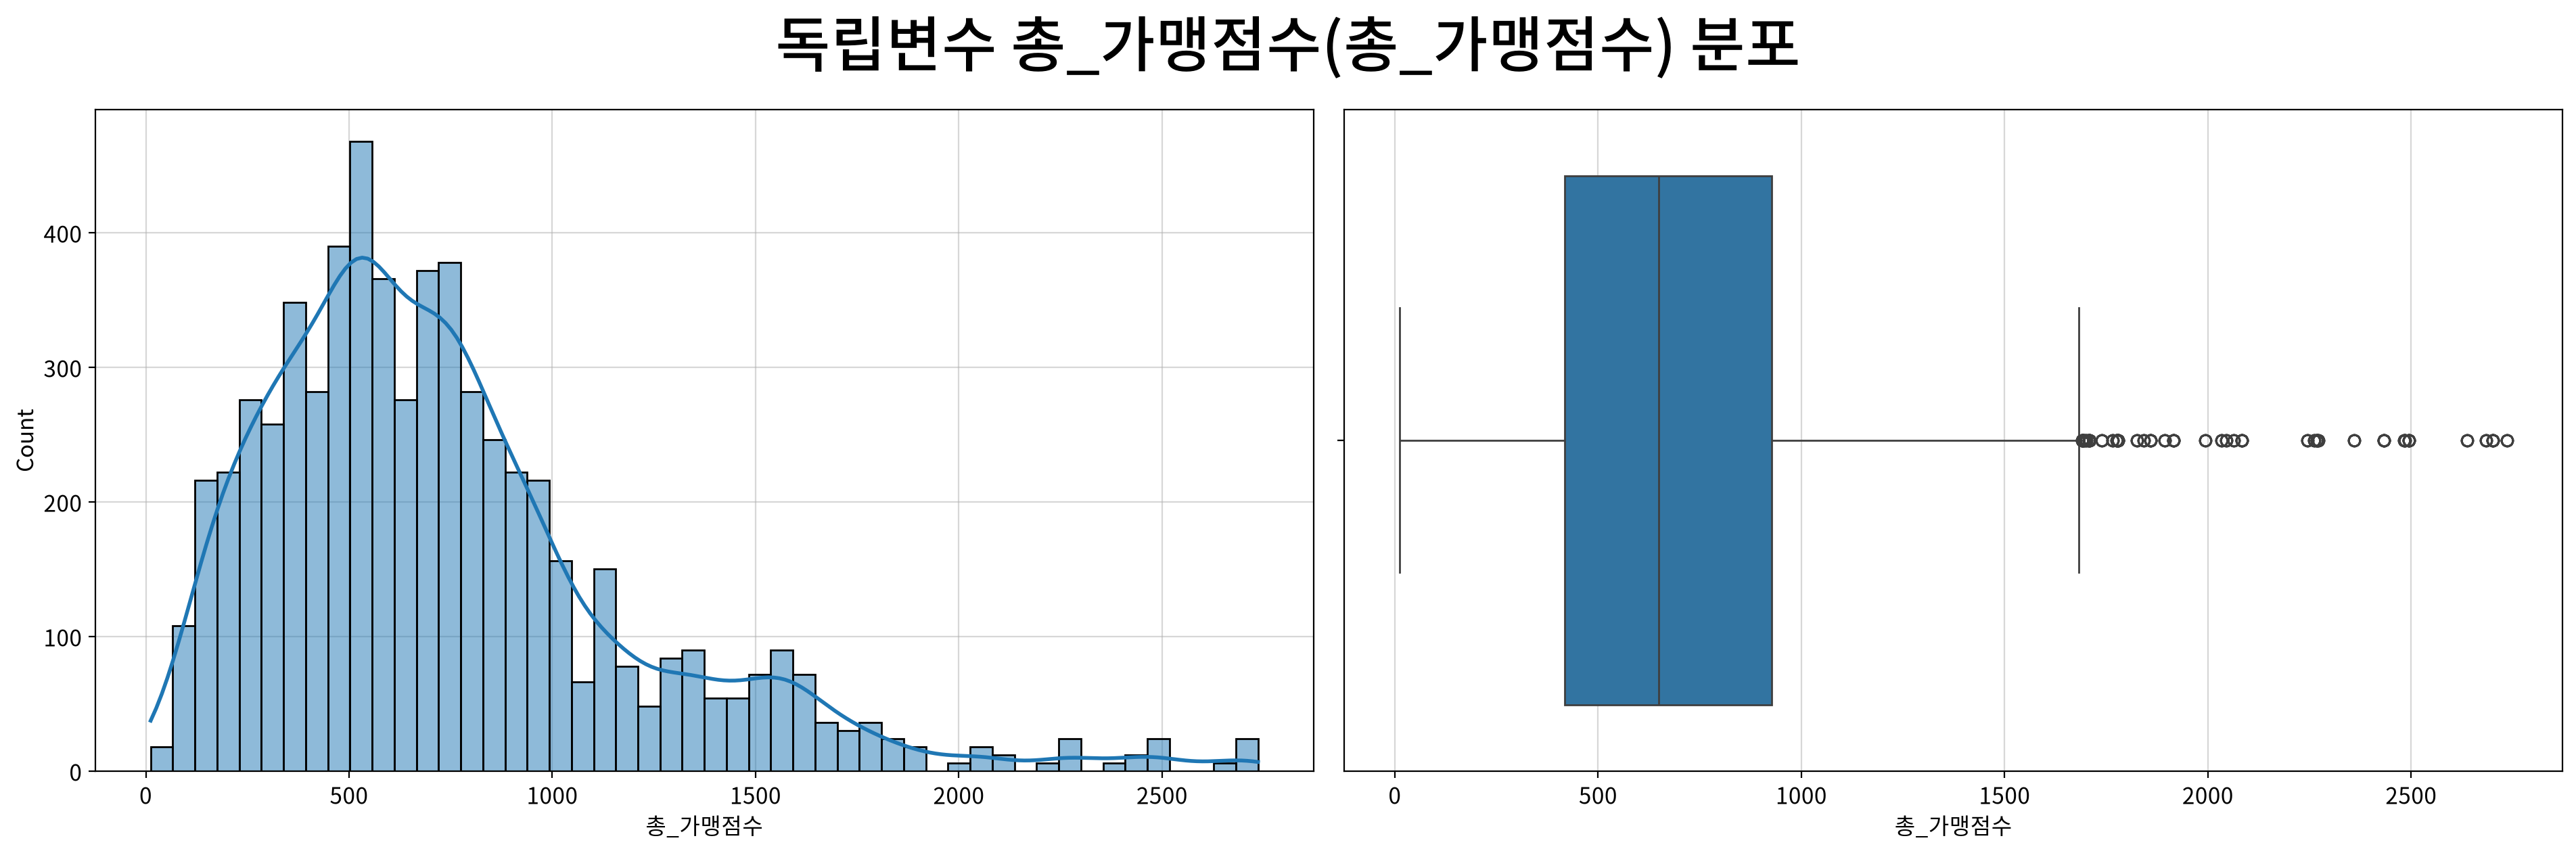

,총_가맹점수
count,6240
mean,734.635577
std,459.4198
min,12.0
25%,417.75
50%,649.5
75%,926.25
max,2736.0
rel_diff,0.131079
rdiff_flag,diff


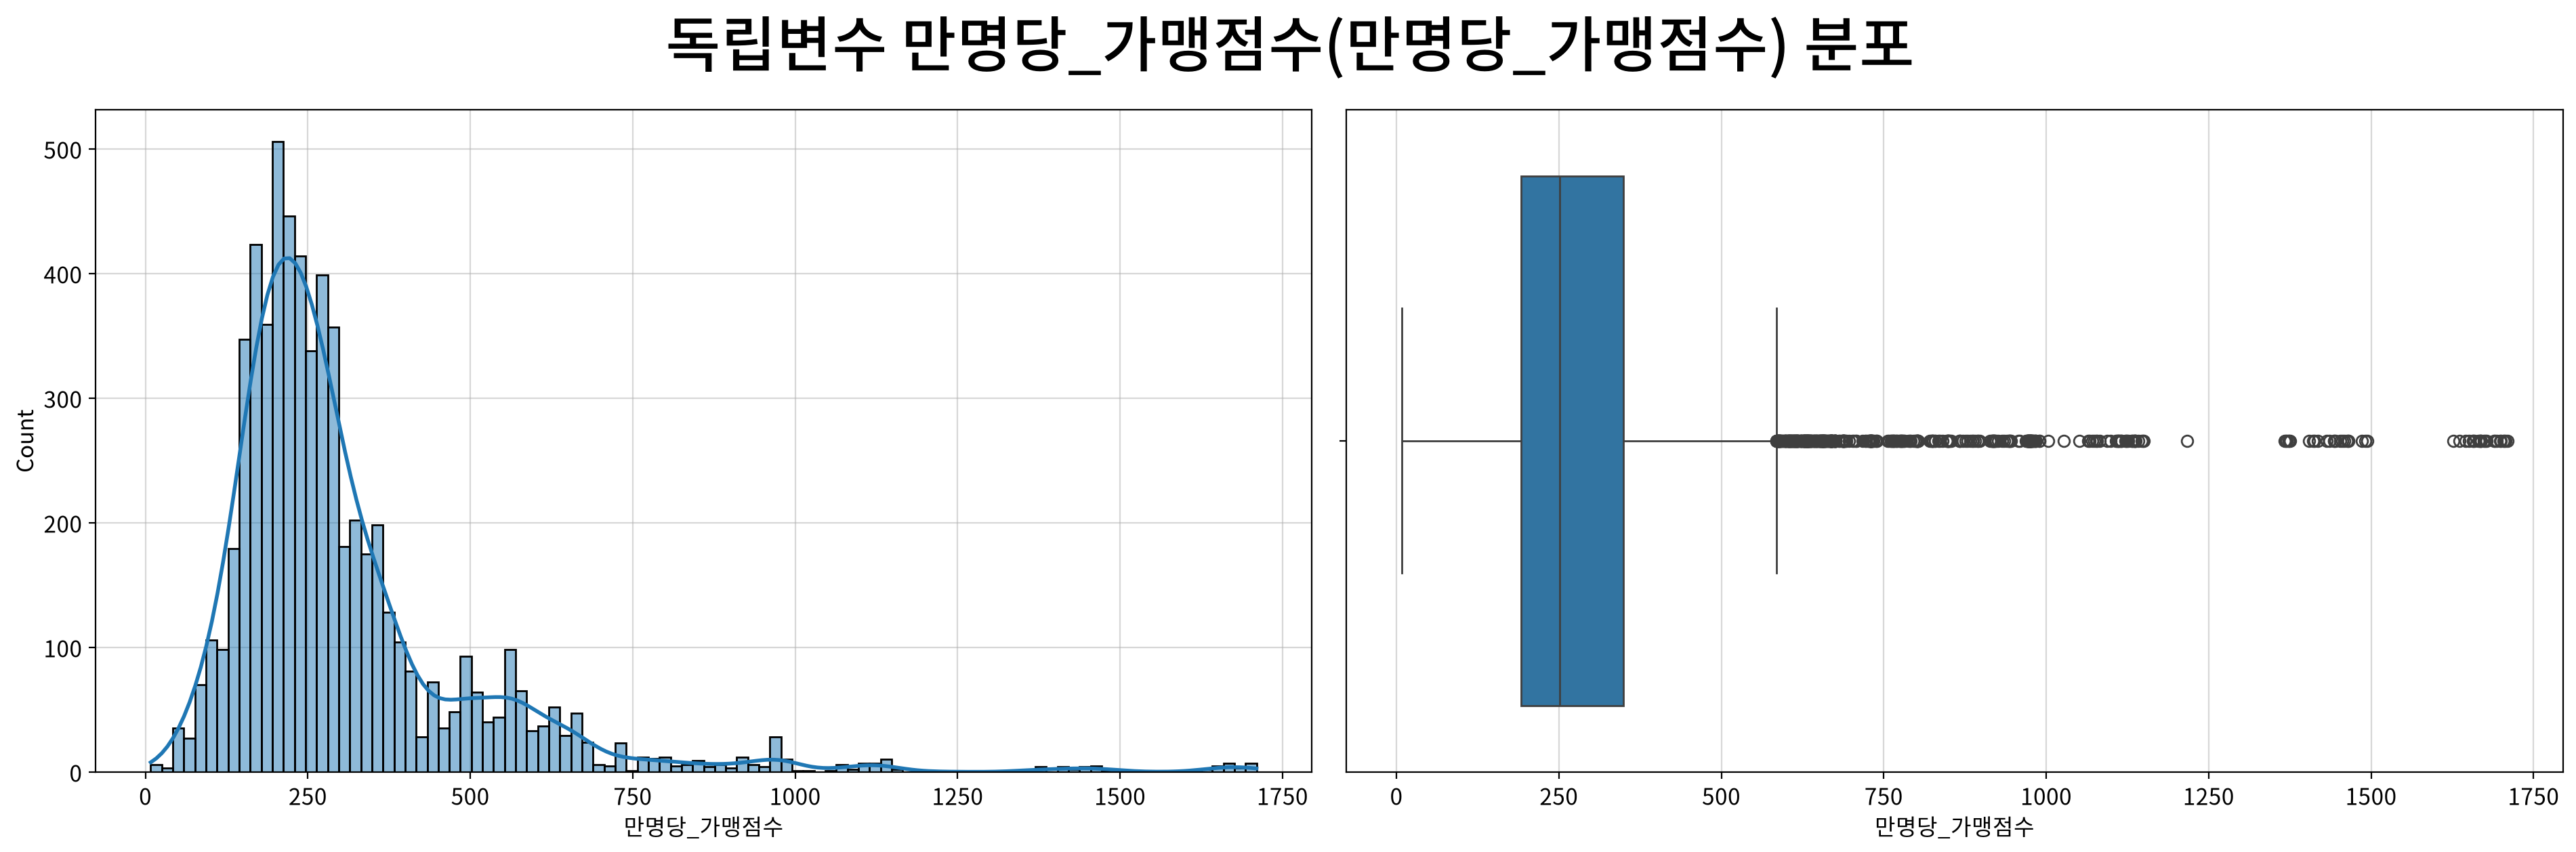

,만명당_가맹점수
count,6240
mean,306.796547
std,202.70379
min,8.186097
25%,192.168467
50%,251.747119
75%,349.18161
max,1709.996737
rel_diff,0.21867
rdiff_flag,diff


In [65]:
# 2. 연속형 독립변수에 대한 단변량 분석

for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f"독립변수 {f}({column_means[f]}) 분포")

    my_plot.histplot(data=df3, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df3, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

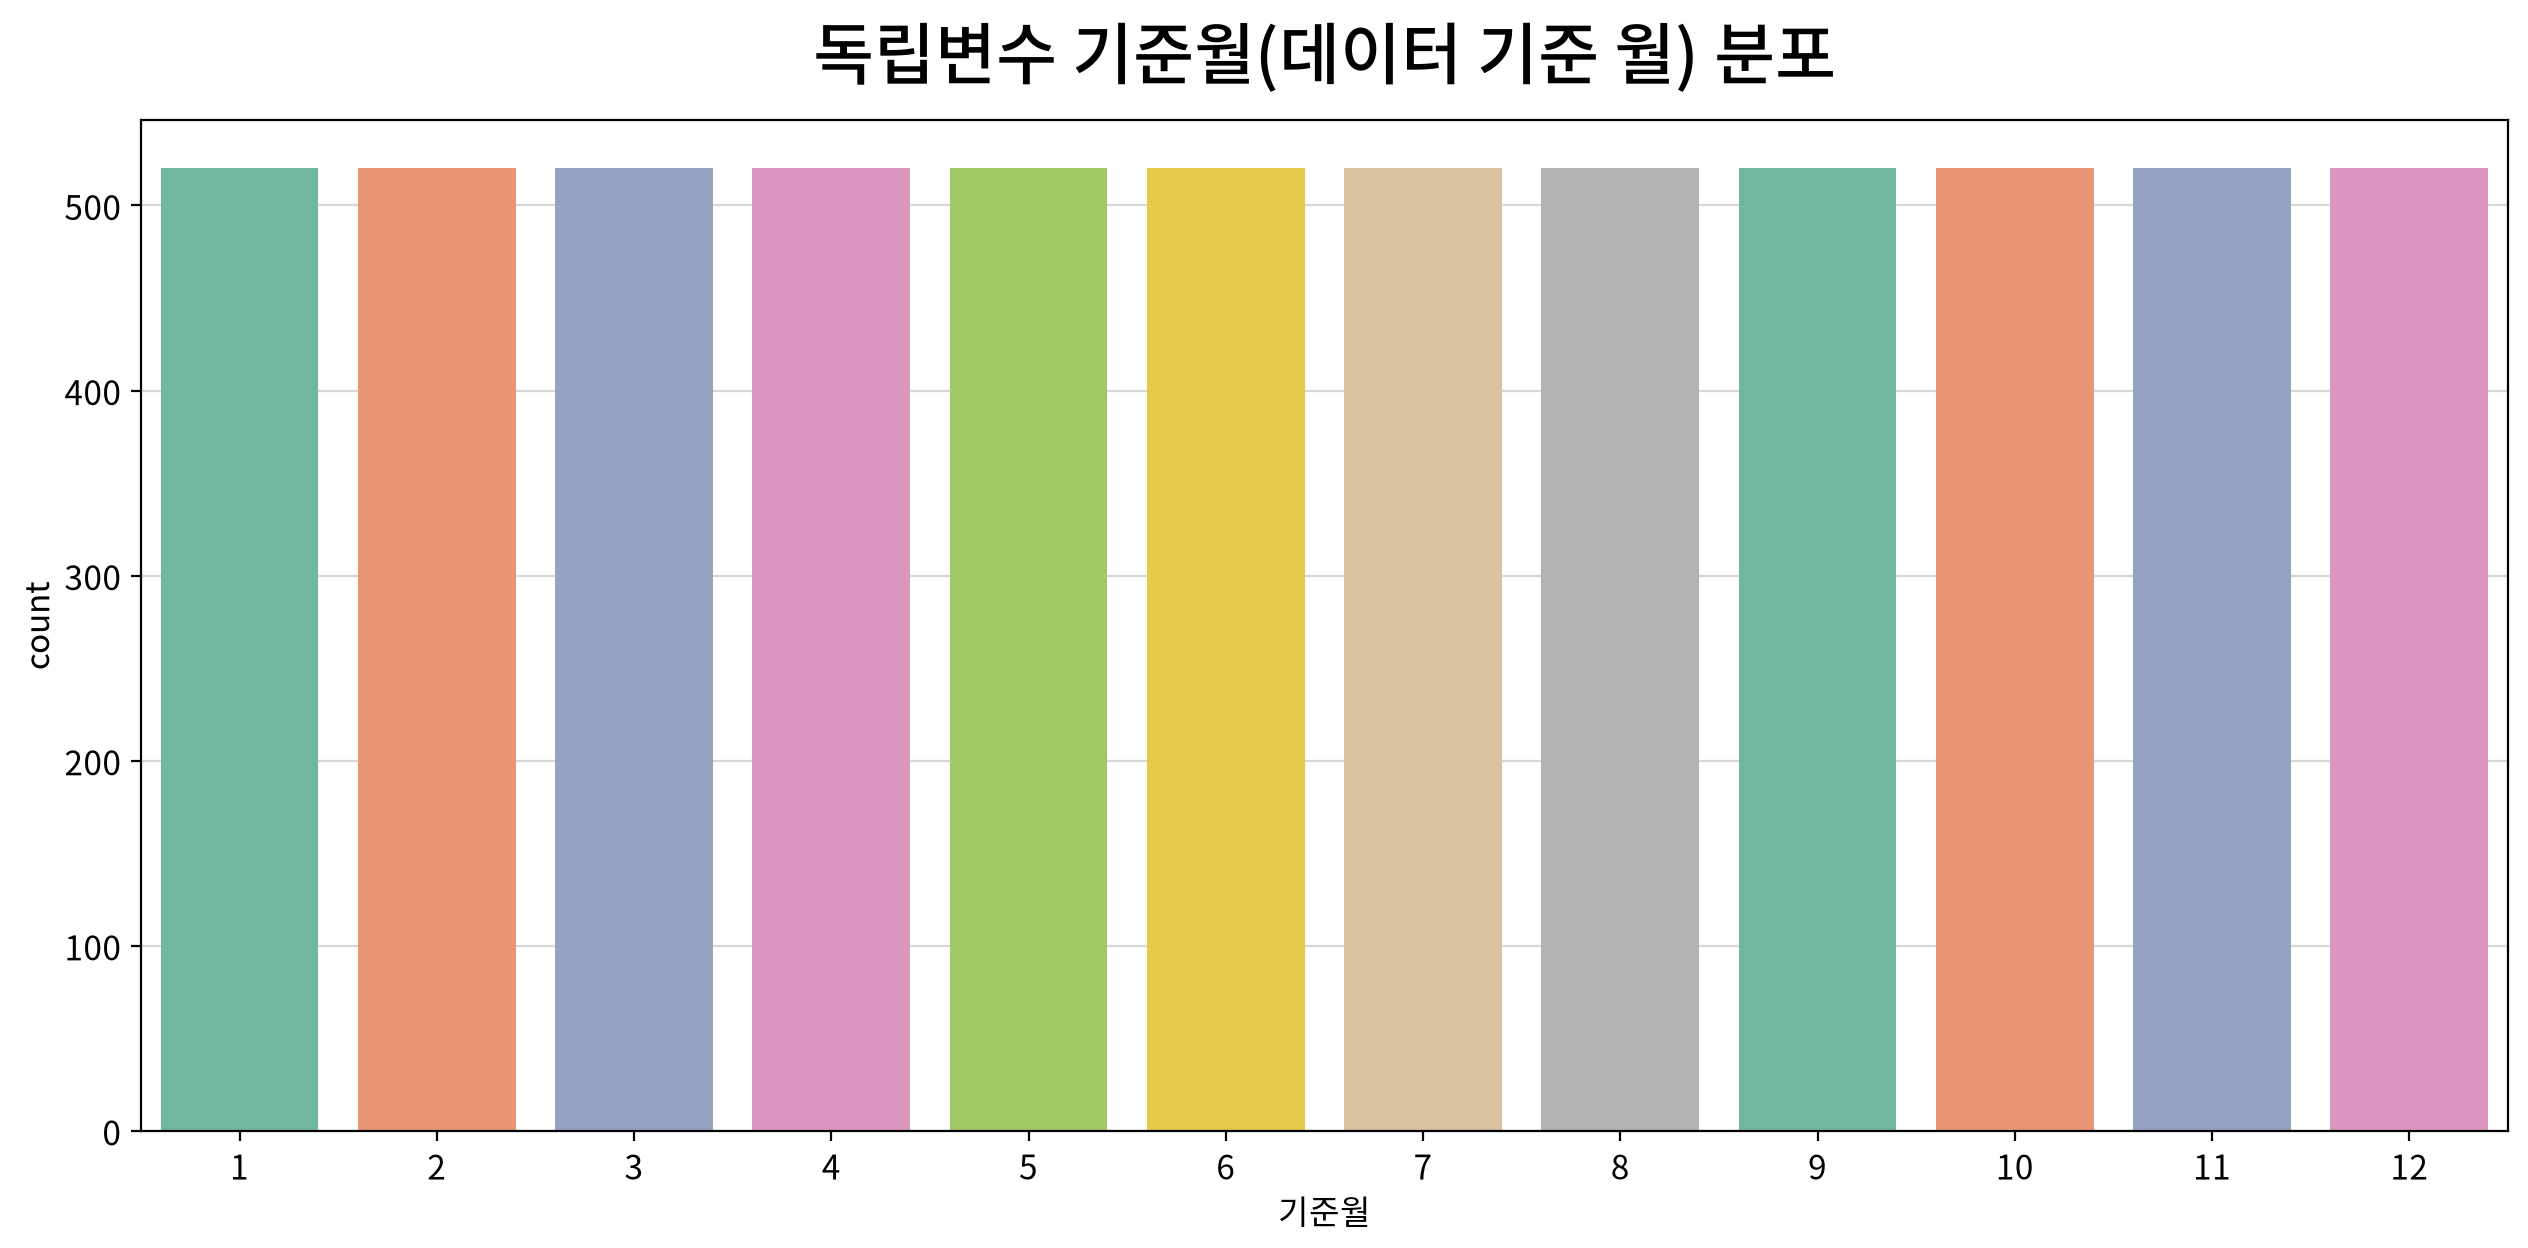

,count,unique,top,freq
기준월,6240,12,1,520


,빈도,비율
기준월,,
1,520,0.083333
2,520,0.083333
3,520,0.083333
4,520,0.083333
5,520,0.083333
6,520,0.083333
7,520,0.083333
8,520,0.083333
9,520,0.083333


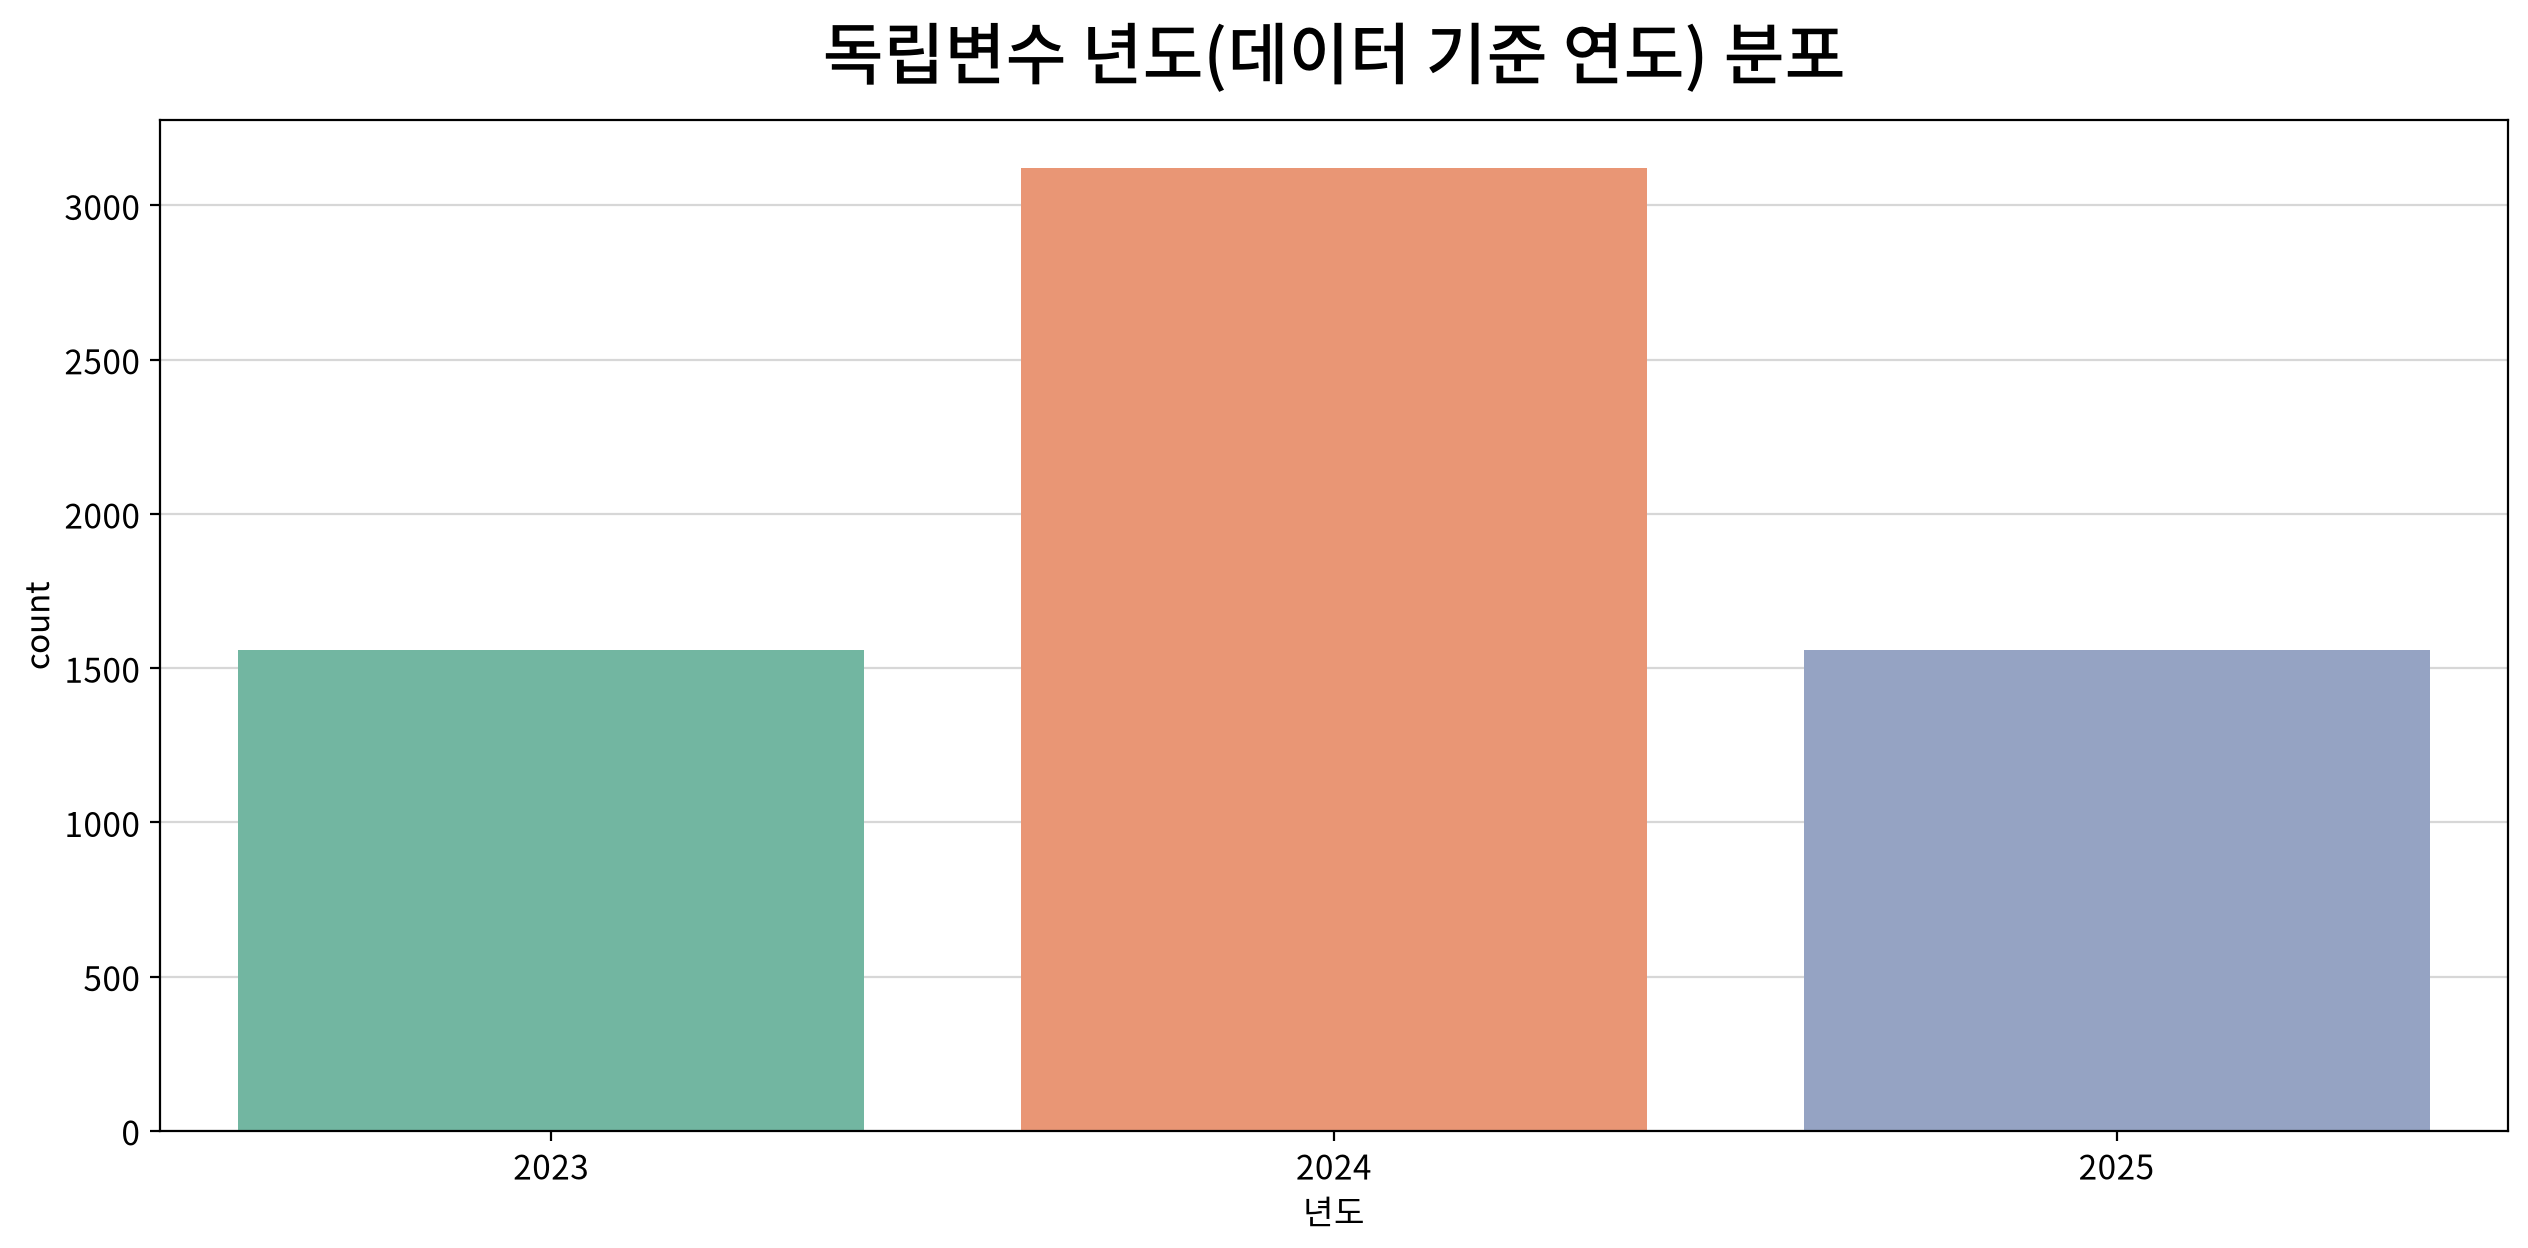

,count,unique,top,freq
년도,6240,3,2024,3120


,빈도,비율
년도,,
2024,3120,0.50
2023,1560,0.25
2025,1560,0.25


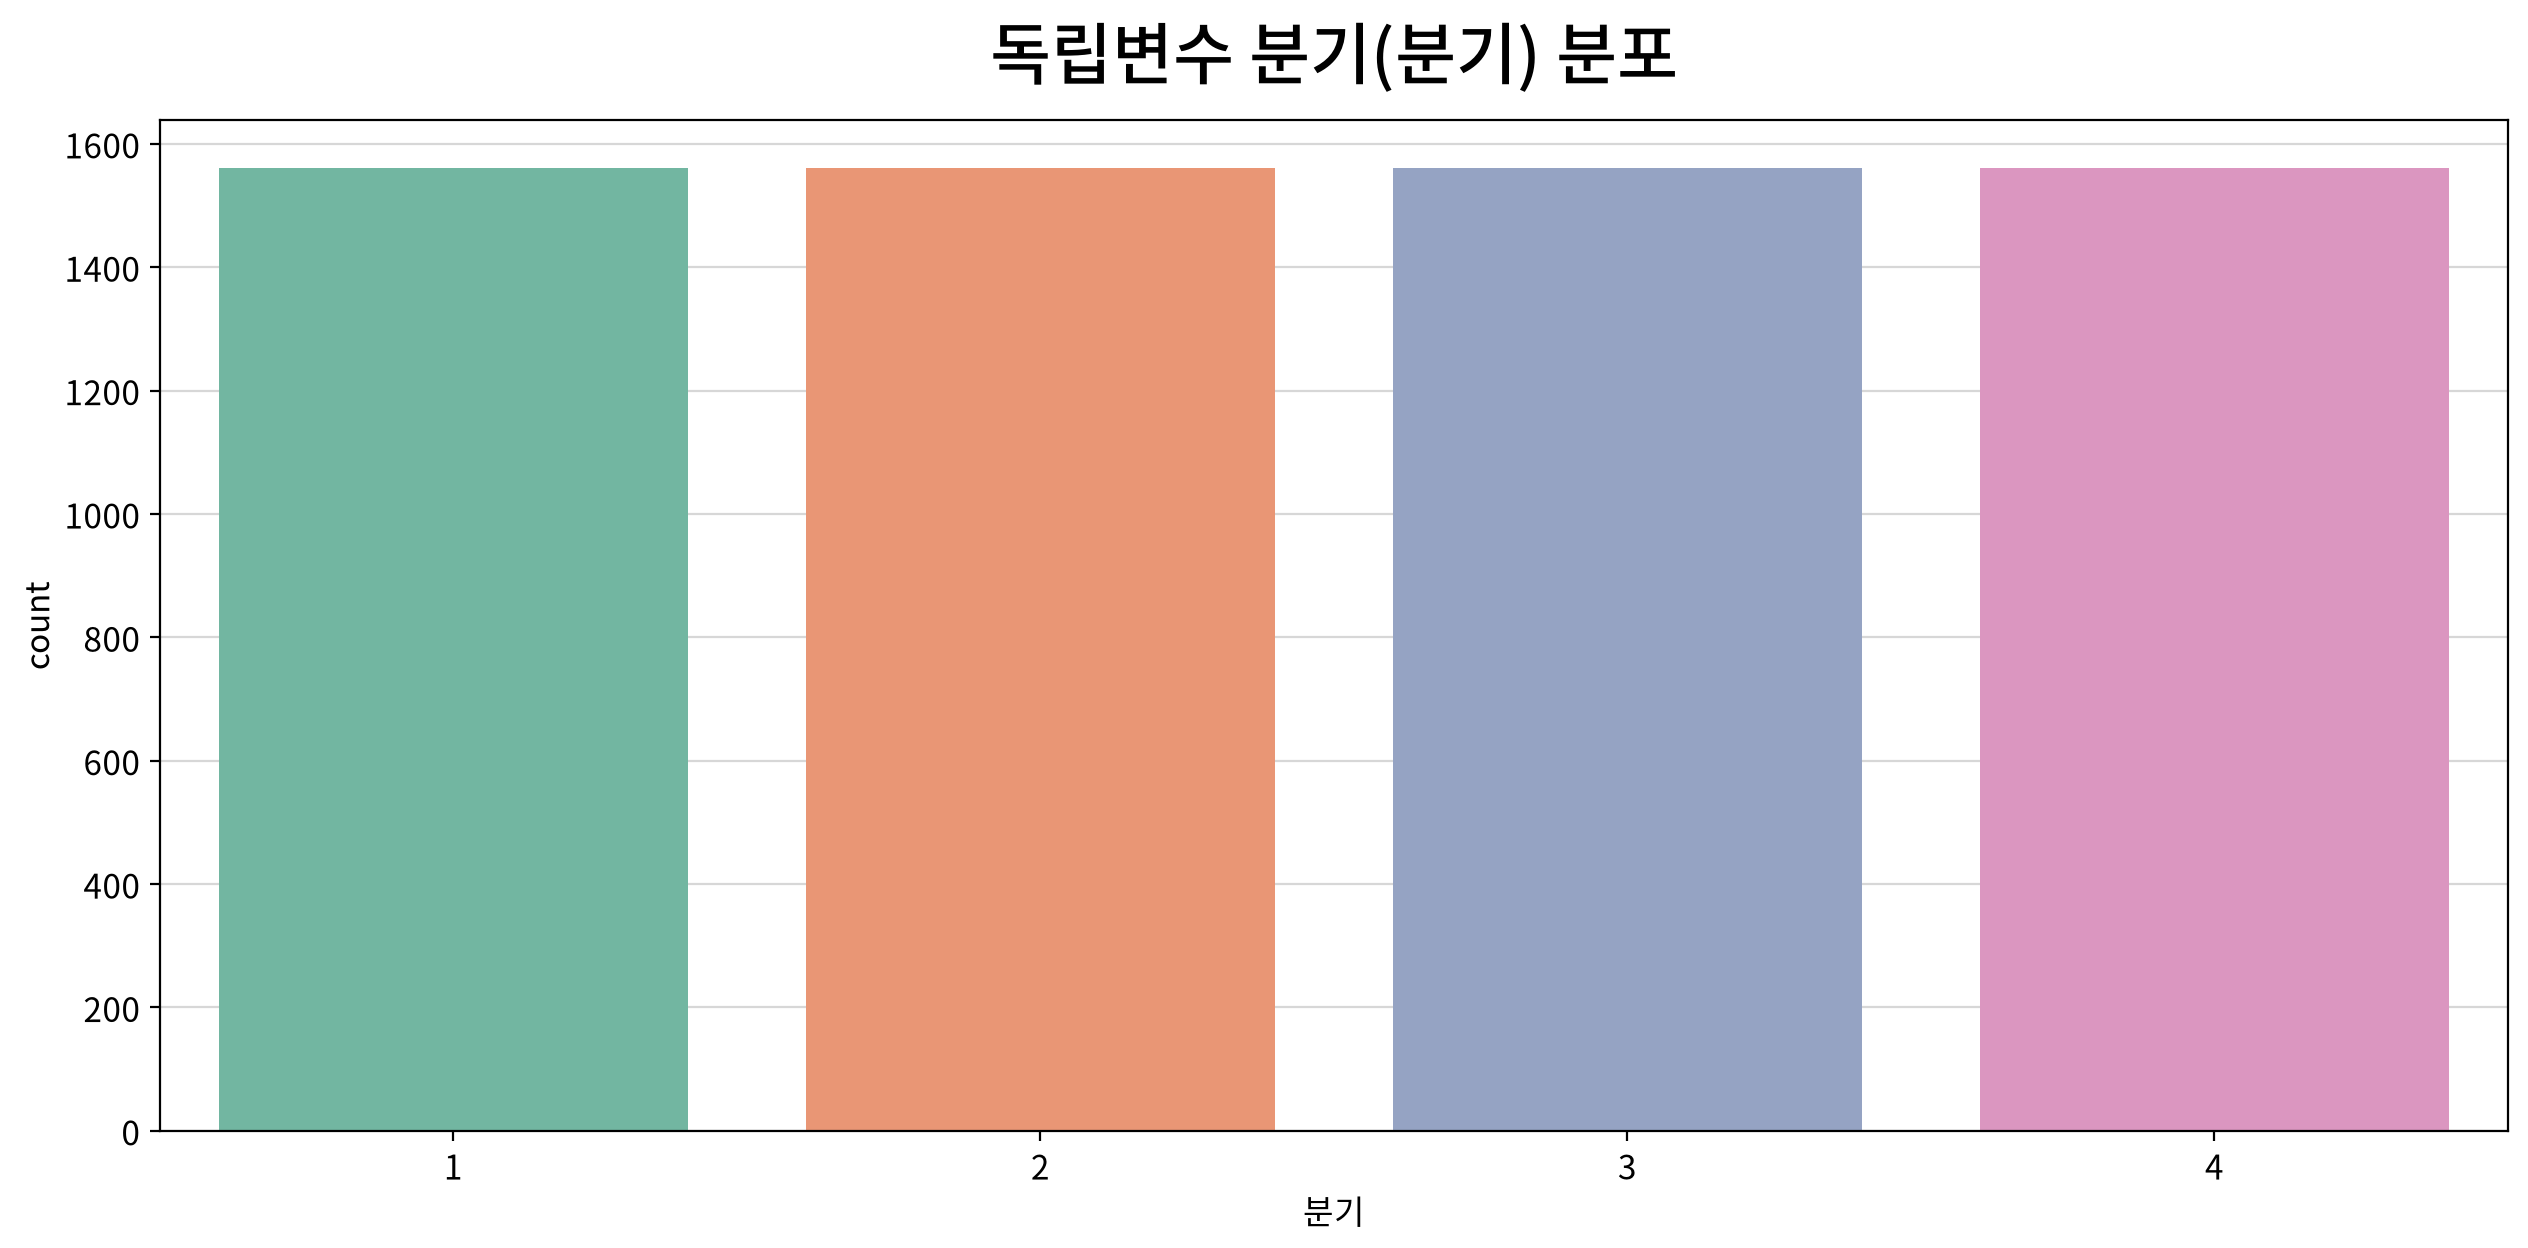

,count,unique,top,freq
분기,6240,4,1,1560


,빈도,비율
분기,,
1,1560,0.25
2,1560,0.25
3,1560,0.25
4,1560,0.25


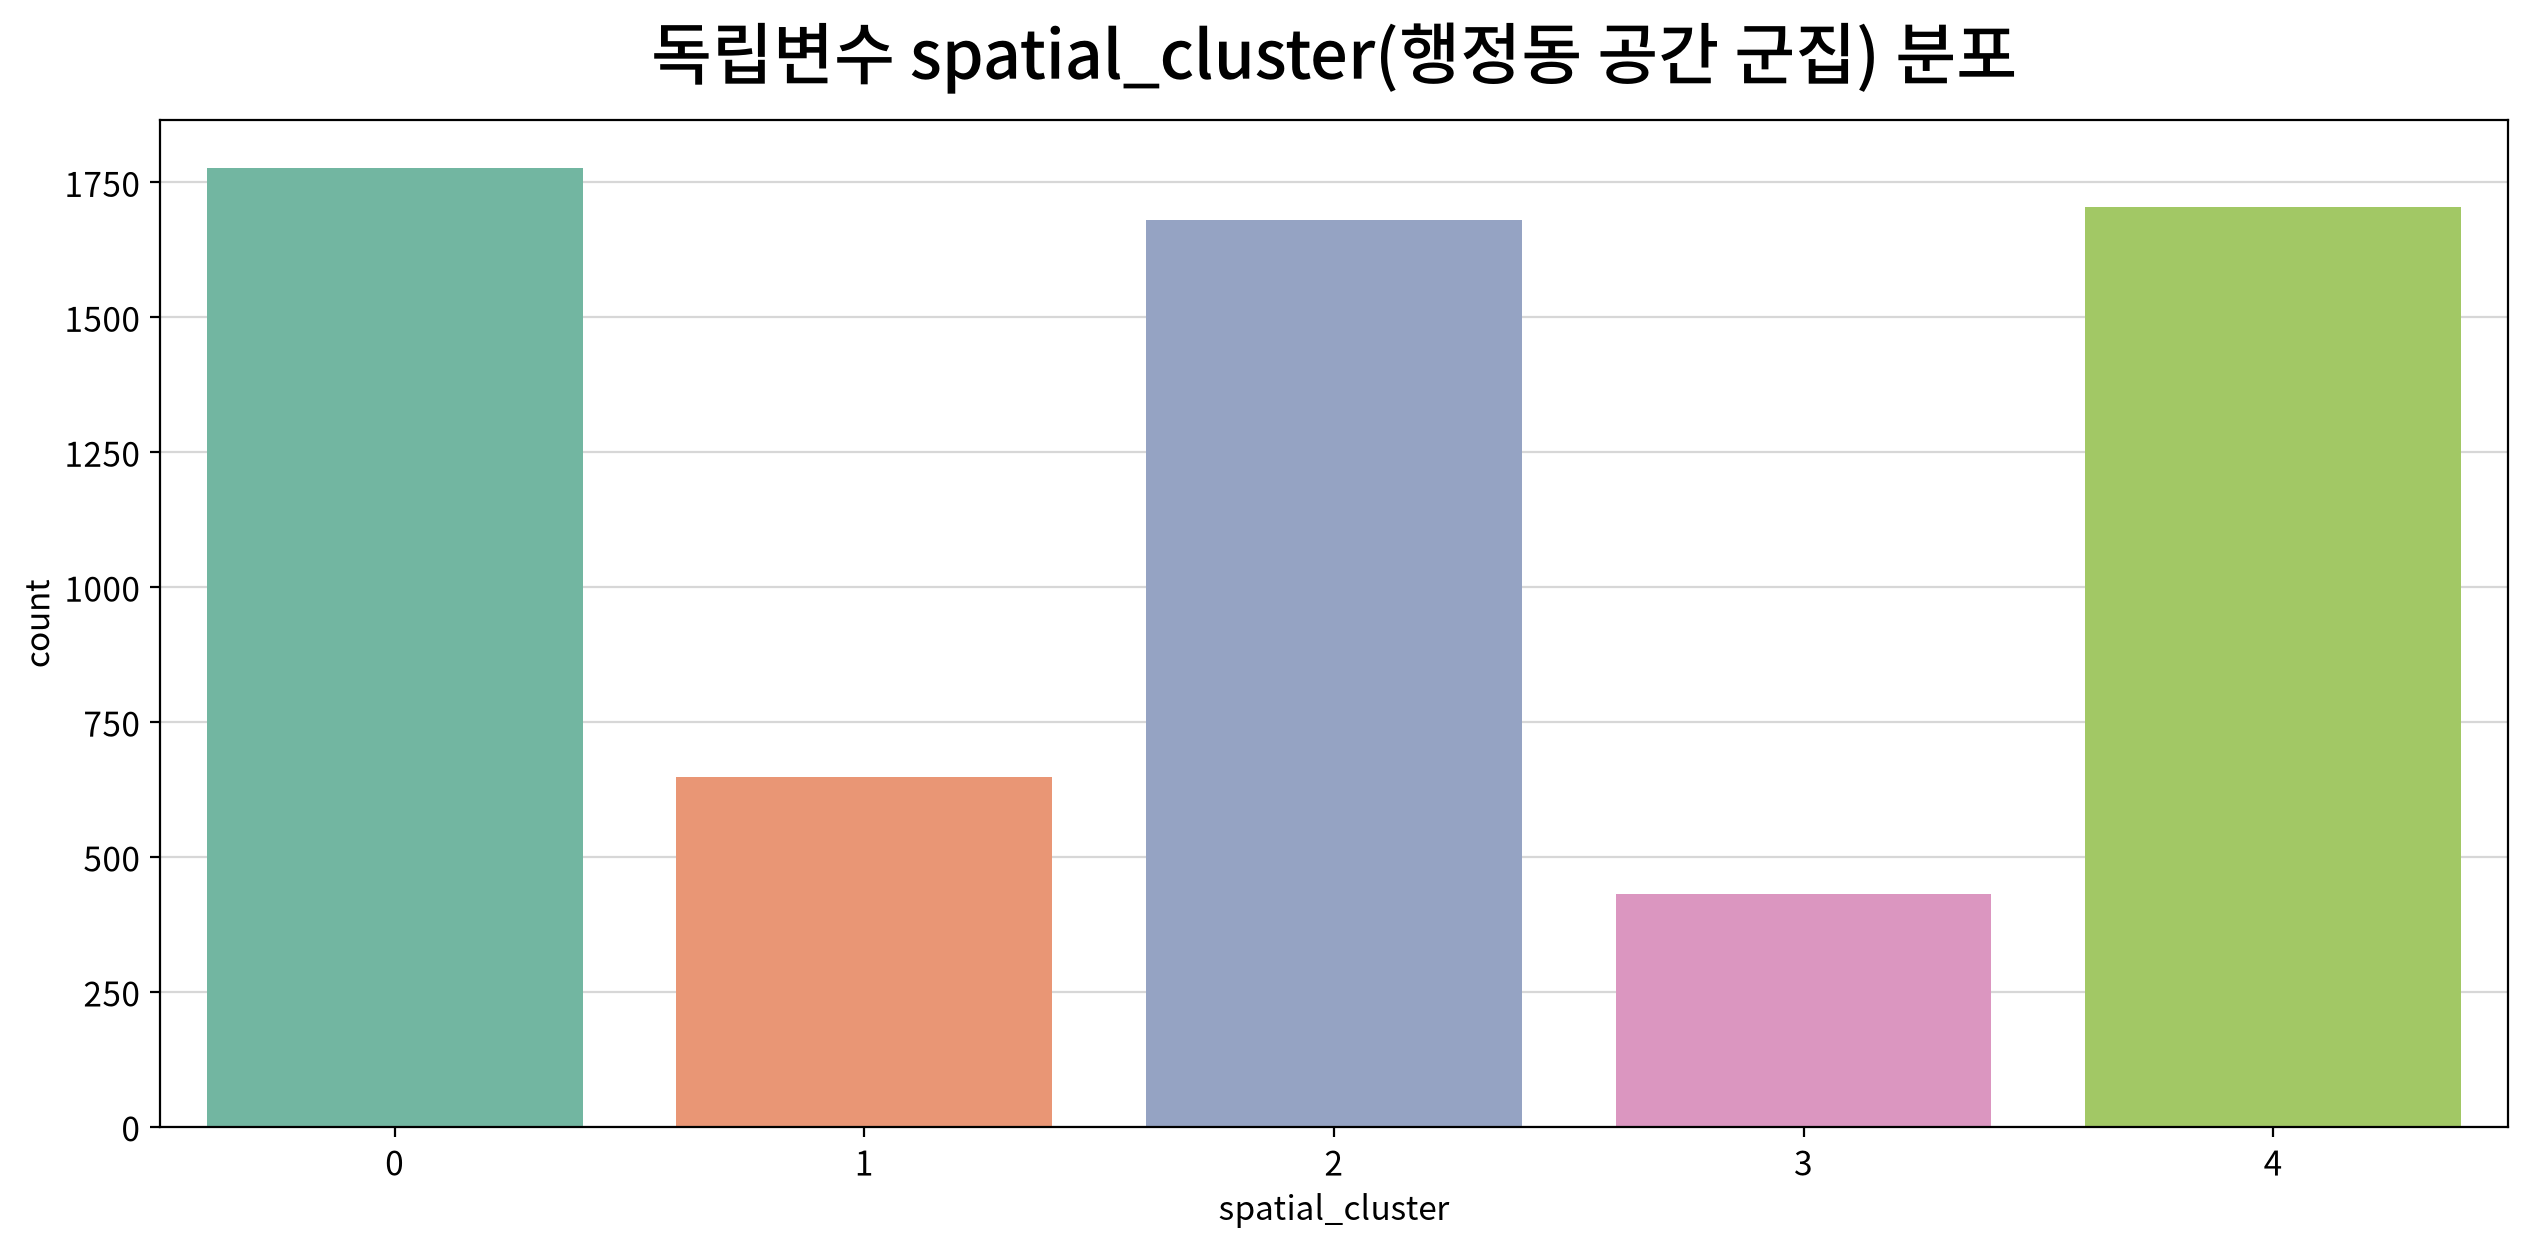

,count,unique,top,freq
spatial_cluster,6240,5,0,1776


,빈도,비율
spatial_cluster,,
0,1776,0.284615
4,1704,0.273077
2,1680,0.269231
1,648,0.103846
3,432,0.069231


In [66]:
# 3. 명목형 독립변수에 대한 단변량 분석

for n in nominal_cols:
    # 명목형 분포는 카운트플롯으로 처리한다.
    my_plot.countplot(data=df3, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df3[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(freq)

In [67]:
corr_list = []

for f in continuous_cols:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

# 11개 결과를 한 표로 합쳐 상관계수 내림차순 정렬
corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
가맹점수_소매,매출금액,Spearman,0.2706,0.0000,Weak,True,False,False,True,True,True
총_가맹점수,매출금액,Spearman,0.2430,0.0000,Weak,True,False,False,False,True,True
가맹점수_수리·개인,매출금액,Spearman,0.2292,0.0000,Weak,True,False,False,False,True,True
가맹점수_예술·스포츠,매출금액,Spearman,0.2231,0.0000,Weak,True,False,False,True,True,True
가맹점수_음식,매출금액,Spearman,0.2120,0.0000,Weak,True,False,False,False,True,True
행정동코드,매출금액,Spearman,0.1976,0.0000,Weak,True,False,False,True,True,True
가맹점수_기타,매출금액,Spearman,0.1893,0.0000,Weak,True,False,False,False,True,True
총인구수,매출금액,Spearman,0.1856,0.0000,Weak,True,False,False,False,True,True
가맹점수_보건의료,매출금액,Spearman,0.1741,0.0000,Weak,True,False,False,False,True,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak    17
Name: count, dtype: int64


### 인구 보정은 비교 기준을 바꾸지만 관계를 강화하지는 않는다

- 총가맹점 수와 매출의 상관은 약 0.24인 반면, 인구 1만 명당 가맹점 수와의 상관은 약 0.10이다. 인구를 보정한 지표가 더 강한 단변량 관계를 보인 것은 아니다.
- 주민등록인구 대비 유동인구도 매출과 약한 음의 상관을 보인다. 상대적 유동 수준을 지역화폐 이용 활성화와 동일하게 해석할 수 없다.
- 파생변수의 목적은 상관계수를 높이는 것만이 아니라 지역 규모를 고려한 비교 기준을 추가하는 데 있다. 모델에서 다른 변수와 함께 사용했을 때의 정보는 별도로 검토한다.

In [68]:
# 2. T-Test(x: 2집단 명목형 독립변수 -> y: 종속변수)
for n in nominal_cols:
    # 2개의 고유값을 가지는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df3, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 🧪 기준월(데이터 기준 월) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,기준월,11,2451.852911,9.598803,3.504704e-17,0.033682,Small


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:1.000e+00
2 vs. 3: Custom statistical test, P_val:9.999e-01
3 vs. 4: Custom statistical test, P_val:1.000e+00
4 vs. 5: Custom statistical test, P_val:1.000e+00
5 vs. 6: Custom statistical test, P_val:1.000e+00
6 vs. 7: Custom statistical test, P_val:1.127e-13
7 vs. 8: Custom statistical test, P_val:0.000e+00
8 vs. 9: Custom statistical test, P_val:1.000e+00
9 vs. 10: Custom statistical test, P_val:1.000e+00
10 vs. 11: Custom statistical test, P_val:1.000e+00
11 vs. 12: Custom statistical test, P_val:1.000e+00
1 vs. 3: Custom statistical test, P_val:1.000e+00
2 vs. 4: Custom statistical test, P_val:1.000e+00
3 vs. 5: Custom statistical test, P_val:1.000e+00
4 vs. 6: Custom statistical test, P_val:1.000e+00
5 vs. 7: Custom statistical test, P_val:0.000e+00
6 v

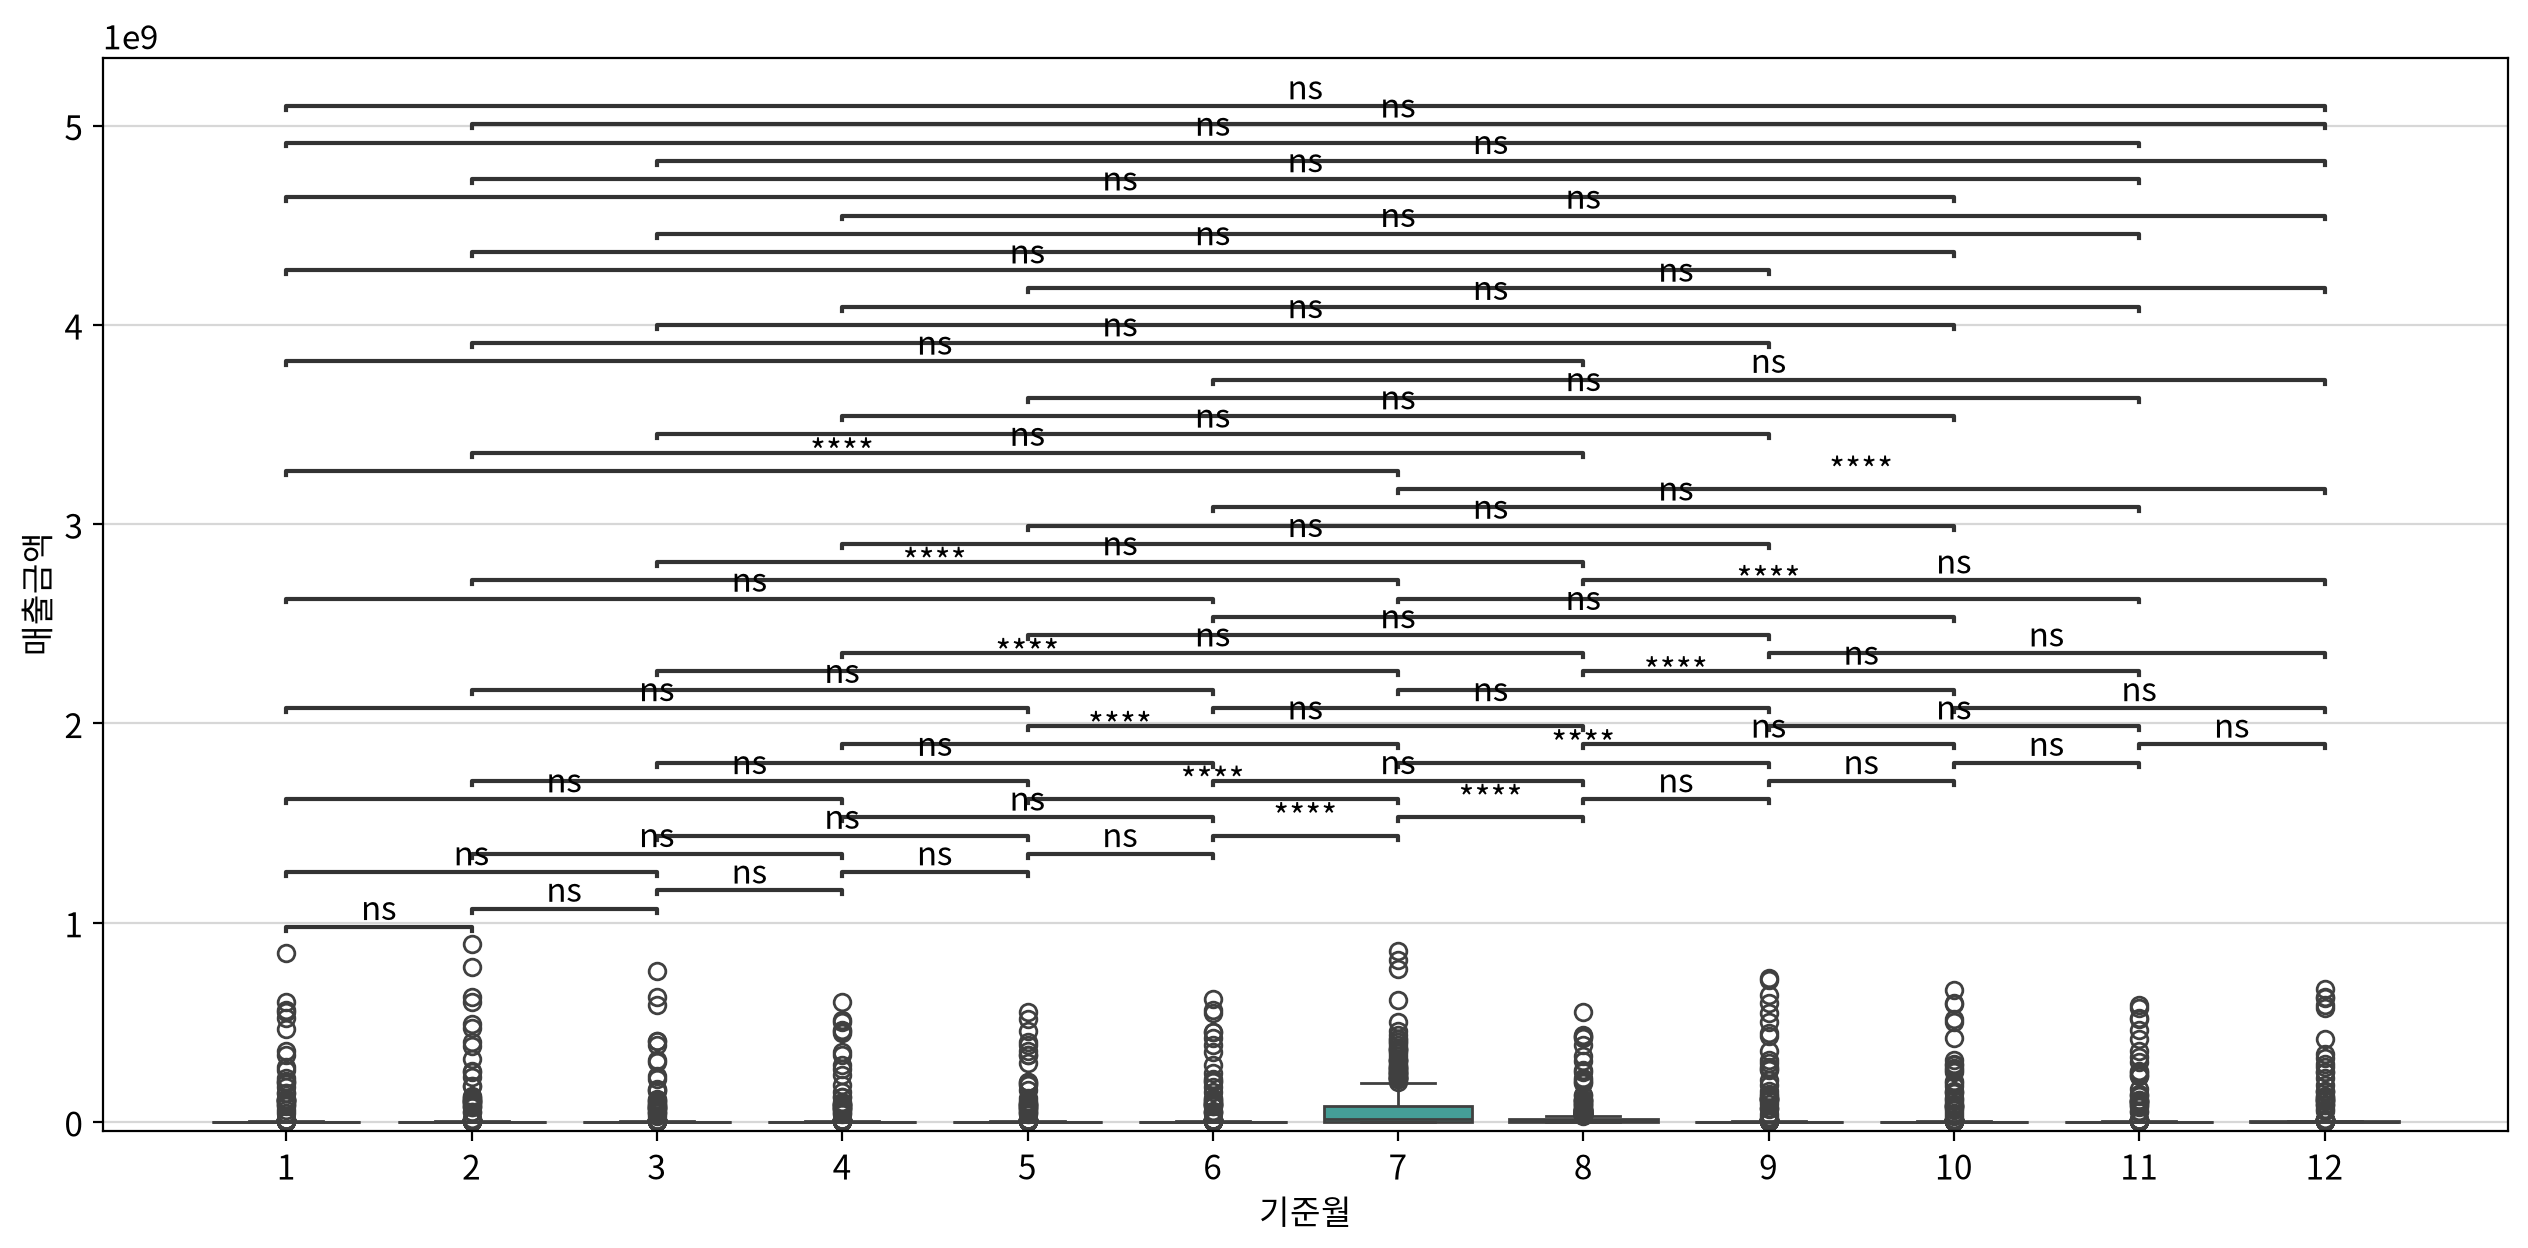

비교한 조합 쌍: 66개
유의한 쌍: 11개
평균 차이가 가장 큰 쌍: (5) vs (7) → 차이 51394363.096, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (2) vs (12) → 차이 44872.067, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,1,2,1.506470e+07,1.562083e+07,-5.561328e+05,4.759248e+06,-0.116853,1031.891931,1.000000,-0.007242,False,Negligible
1,Games-Howell,1,3,1.506470e+07,1.235589e+07,2.708803e+06,4.305938e+06,0.629085,1021.358704,0.999974,0.038986,False,Negligible
2,Games-Howell,1,4,1.506470e+07,1.273438e+07,2.330320e+06,4.239294e+06,0.549695,1011.013584,0.999993,0.034066,False,Negligible
3,Games-Howell,1,5,1.506470e+07,1.202463e+07,3.040069e+06,4.104636e+06,0.740643,981.038014,0.999865,0.045900,False,Negligible
4,Games-Howell,1,6,1.506470e+07,1.359631e+07,1.468384e+06,4.309579e+06,0.340726,1021.843933,1.000000,0.021116,False,Negligible
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Games-Howell,9,11,1.715364e+07,1.437862e+07,2.775021e+06,4.565957e+06,0.607763,1002.657207,0.999982,0.037665,False,Negligible
62,Games-Howell,9,12,1.715364e+07,1.557596e+07,1.577687e+06,4.745854e+06,0.332435,1027.842840,1.000000,0.020602,False,Negligible
63,Games-Howell,10,11,1.461141e+07,1.437862e+07,2.327882e+05,4.195077e+06,0.055491,1036.520627,1.000000,0.003439,False,Negligible
64,Games-Howell,10,12,1.461141e+07,1.557596e+07,-9.645456e+05,4.390198e+06,-0.219704,1035.155693,1.000000,-0.013616,False,Negligible


#### 🧪 년도(데이터 기준 연도) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,년도,2,2979.625134,34.042486,2.409462e-15,0.014328,Small


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

2023 vs. 2024: Custom statistical test, P_val:1.001e-12
2024 vs. 2025: Custom statistical test, P_val:8.159e-01
2023 vs. 2025: Custom statistical test, P_val:1.641e-10


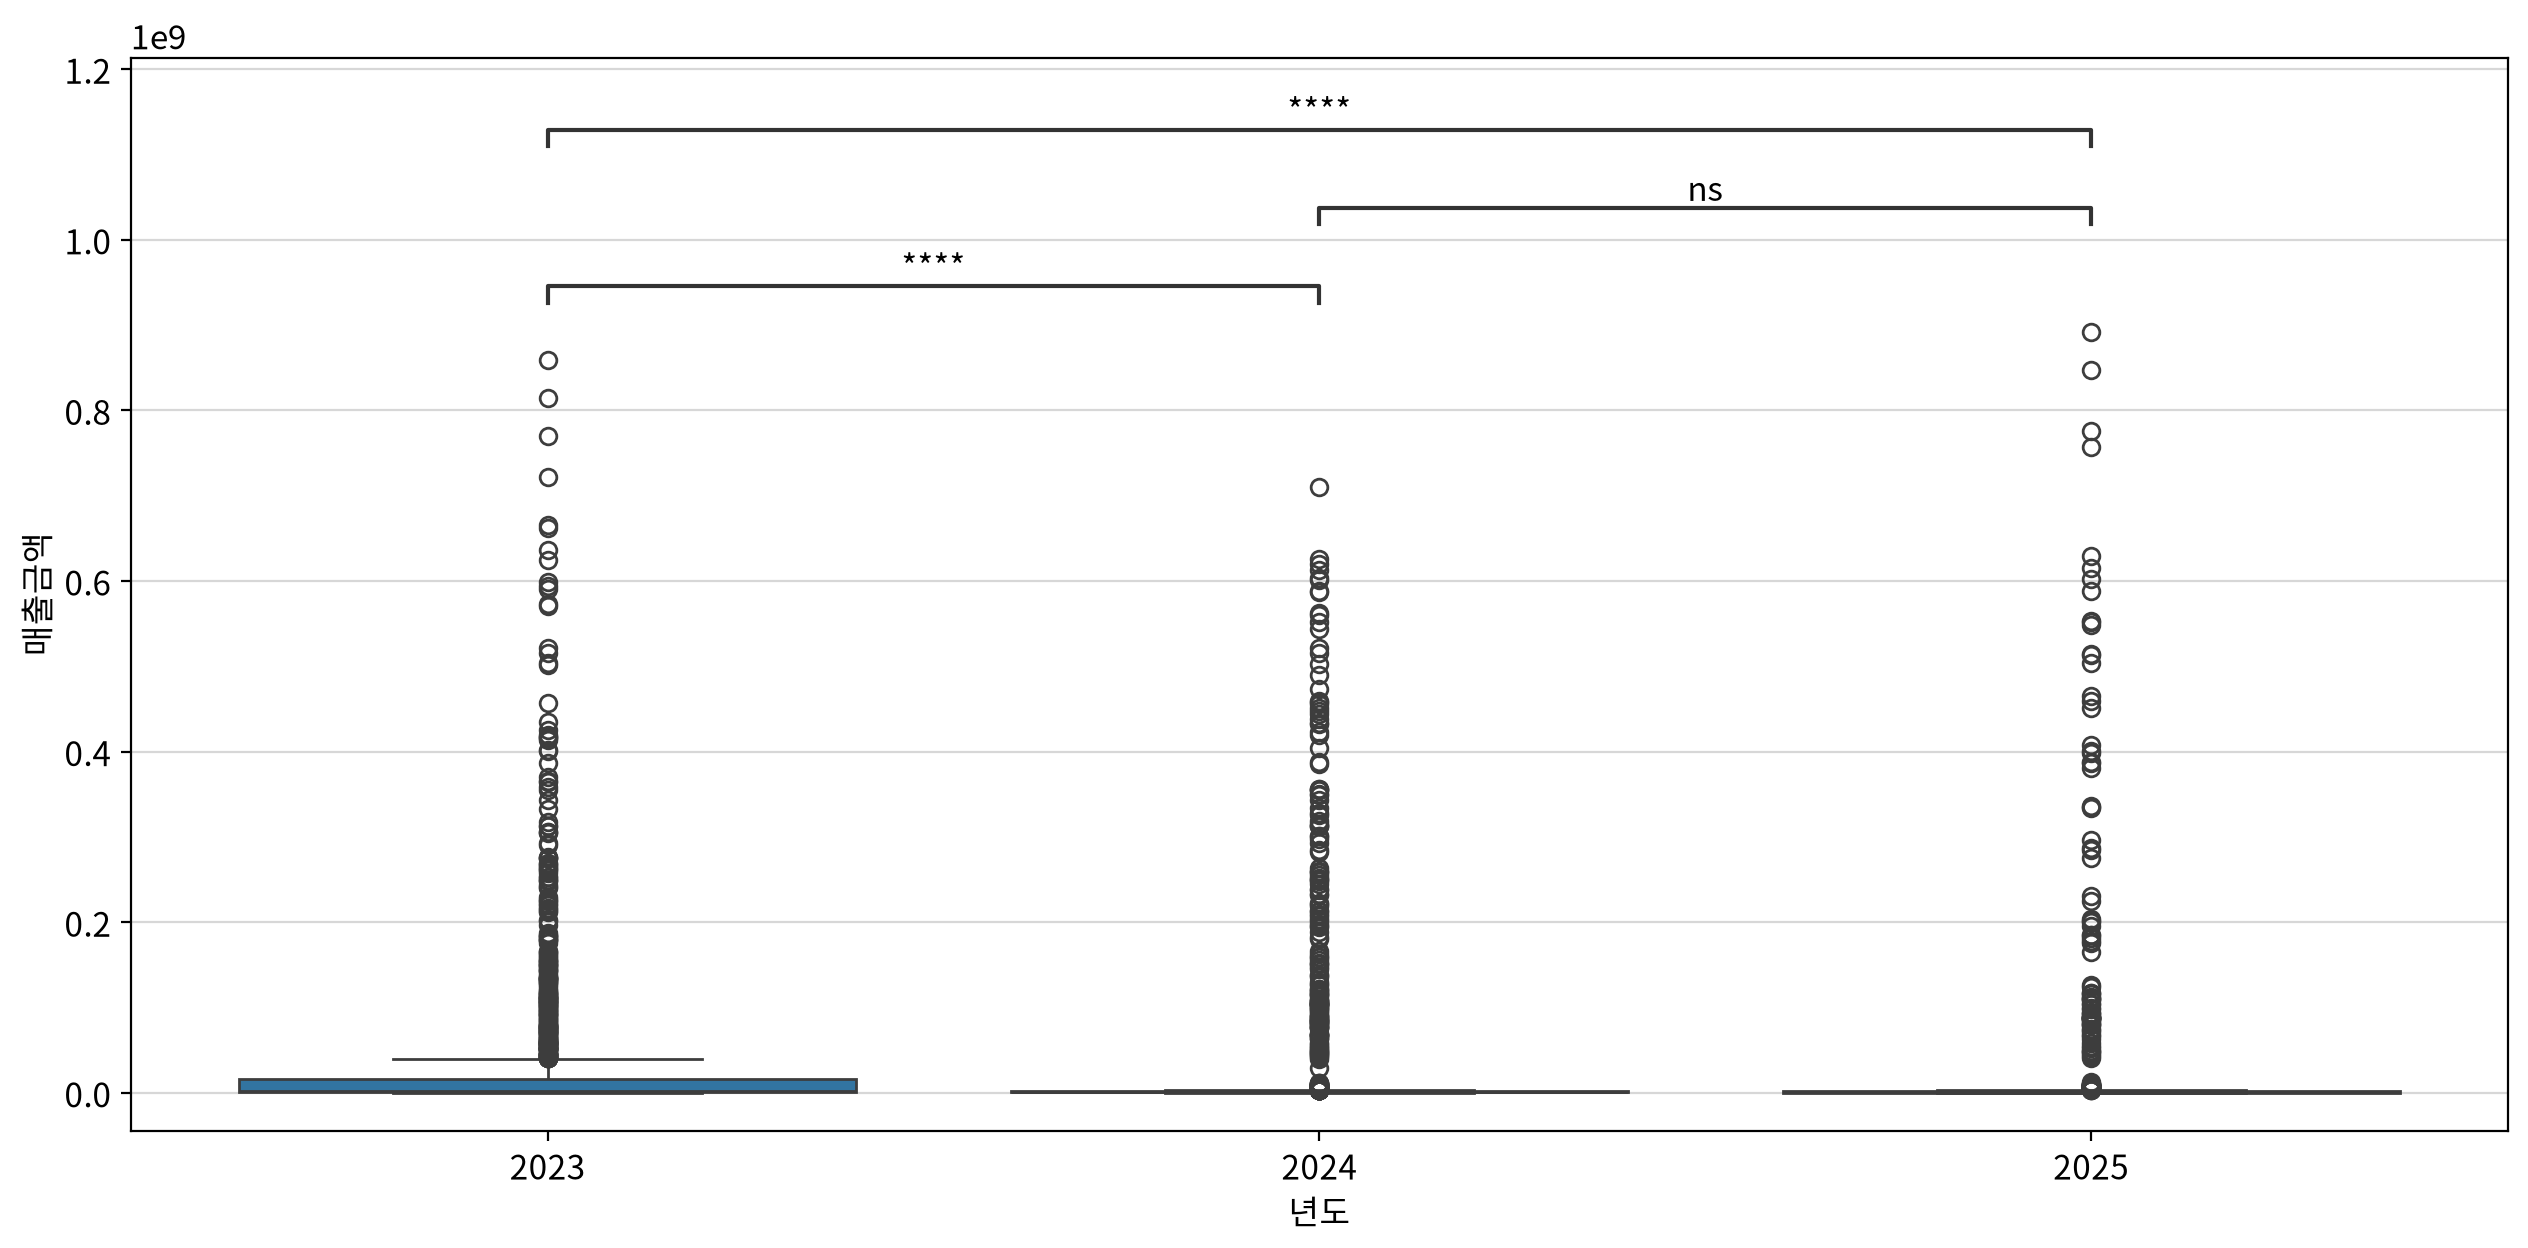

비교한 조합 쌍: 3개
유의한 쌍: 2개
평균 차이가 가장 큰 쌍: (2023) vs (2024) → 차이 20877291.394, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (2024) vs (2025) → 차이 1330465.262, 효과크기 Negligible, p-value 0.816


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,2023,2024,3.415522e+07,1.327793e+07,2.087729e+07,2.559970e+06,8.155288,2325.321669,1.001088e-12,0.284680,True,Small
1,Games-Howell,2023,2025,3.415522e+07,1.460839e+07,1.954683e+07,2.969889e+06,6.581669,2998.299640,1.640701e-10,0.235605,True,Small
2,Games-Howell,2024,2025,1.327793e+07,1.460839e+07,-1.330465e+06,2.188859e+06,-0.607835,2700.907381,8.158521e-01,-0.019918,False,Negligible


#### 🧪 분기(분기) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,분기,3,3442.170406,21.53999,8.086961e-14,0.012888,Small


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:9.172e-01
2 vs. 3: Custom statistical test, P_val:7.101e-13
3 vs. 4: Custom statistical test, P_val:5.003e-10
1 vs. 3: Custom statistical test, P_val:3.704e-10
2 vs. 4: Custom statistical test, P_val:8.148e-01
1 vs. 4: Custom statistical test, P_val:9.972e-01


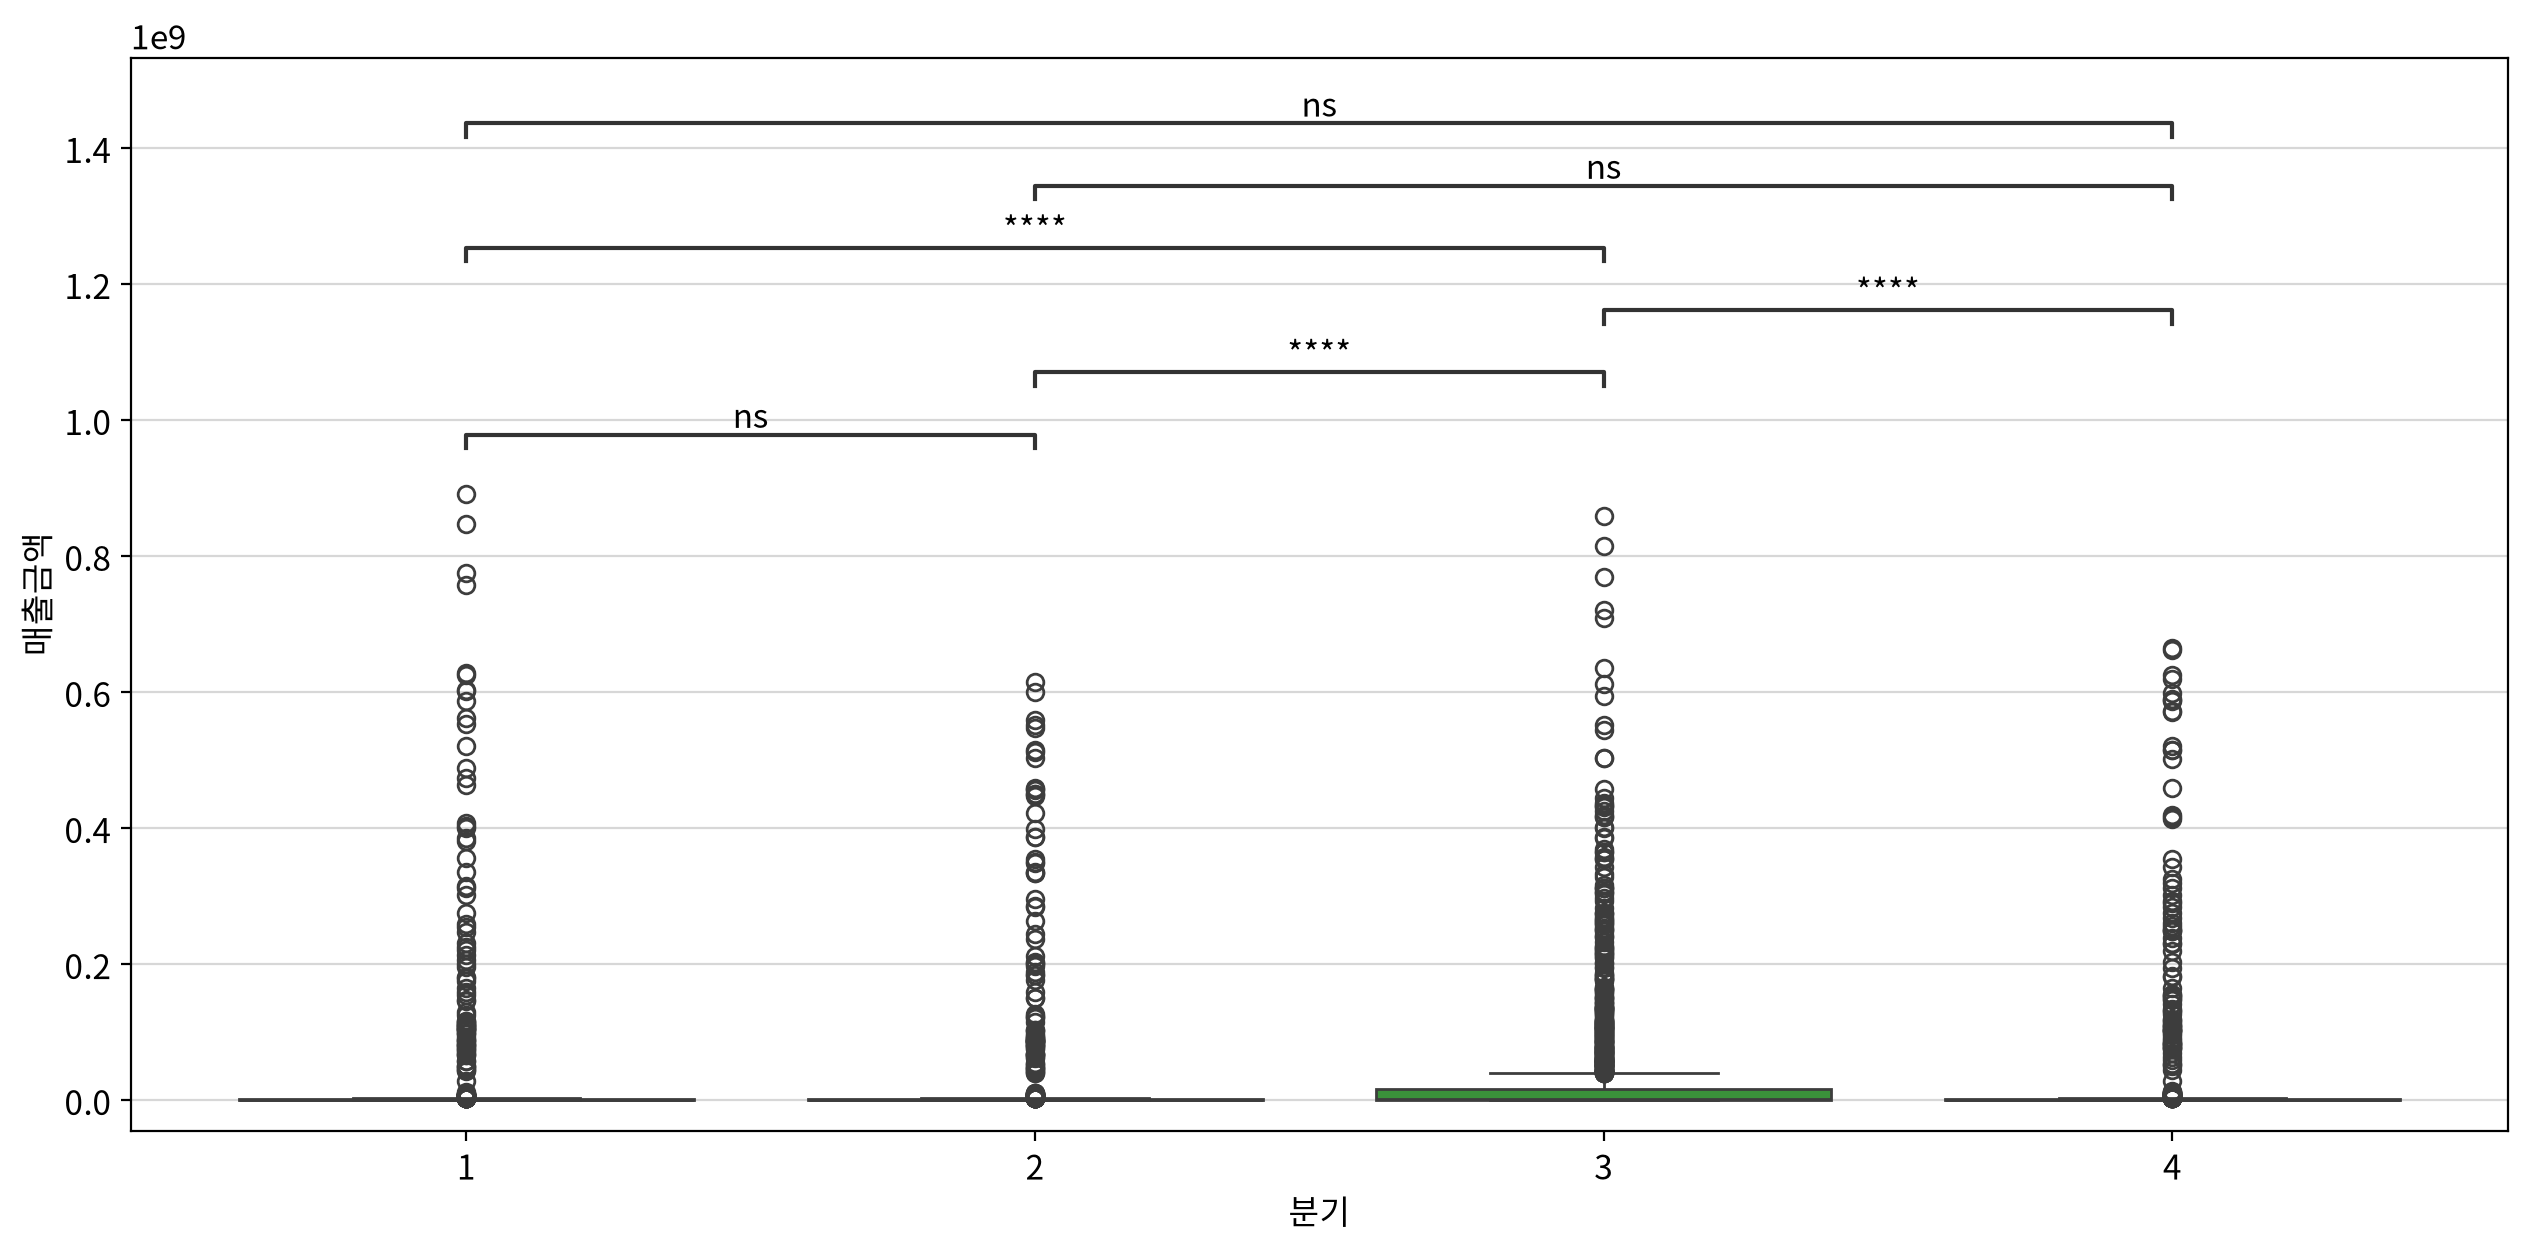

비교한 조합 쌍: 6개
유의한 쌍: 3개
평균 차이가 가장 큰 쌍: (2) vs (3) → 차이 20546786.564, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (1) vs (4) → 차이 508190.940, 효과크기 Negligible, p-value 0.997


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,1,2,1.434714e+07,1.278511e+07,1.562034e+06,2.420159e+06,0.645426,3035.223571,9.171702e-01,0.023104,False,Negligible
1,Games-Howell,1,3,1.434714e+07,3.333189e+07,-1.898475e+07,2.892623e+06,-6.563162,3015.476243,3.703692e-10,-0.234942,True,Small
2,Games-Howell,1,4,1.434714e+07,1.485533e+07,-5.081909e+05,2.547693e+06,-0.199471,3109.780594,9.971909e-01,-0.007140,False,Negligible
3,Games-Howell,2,3,1.278511e+07,3.333189e+07,-2.054679e+07,2.720294e+06,-7.553149,2796.267018,7.100986e-13,-0.270381,True,Small
4,Games-Howell,2,4,1.278511e+07,1.485533e+07,-2.070225e+06,2.350208e+06,-0.880869,3077.508409,8.148075e-01,-0.031533,False,Negligible
5,Games-Howell,3,4,3.333189e+07,1.485533e+07,1.847656e+07,2.834355e+06,6.518788,2956.677461,5.002608e-10,0.233354,True,Small


#### 🧪 spatial_cluster(행정동 공간 군집) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,spatial_cluster,4,1995.745463,24.252804,1.272716e-19,0.013843,Small


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Custom statistical test, P_val:2.263e-02
1 vs. 2: Custom statistical test, P_val:8.545e-12
2 vs. 3: Custom statistical test, P_val:1.901e-02
3 vs. 4: Custom statistical test, P_val:2.486e-02
0 vs. 2: Custom statistical test, P_val:4.228e-05
1 vs. 3: Custom statistical test, P_val:1.282e-06
2 vs. 4: Custom statistical test, P_val:9.998e-01
0 vs. 3: Custom statistical test, P_val:5.965e-05
1 vs. 4: Custom statistical test, P_val:9.024e-11
0 vs. 4: Custom statistical test, P_val:8.128e-05


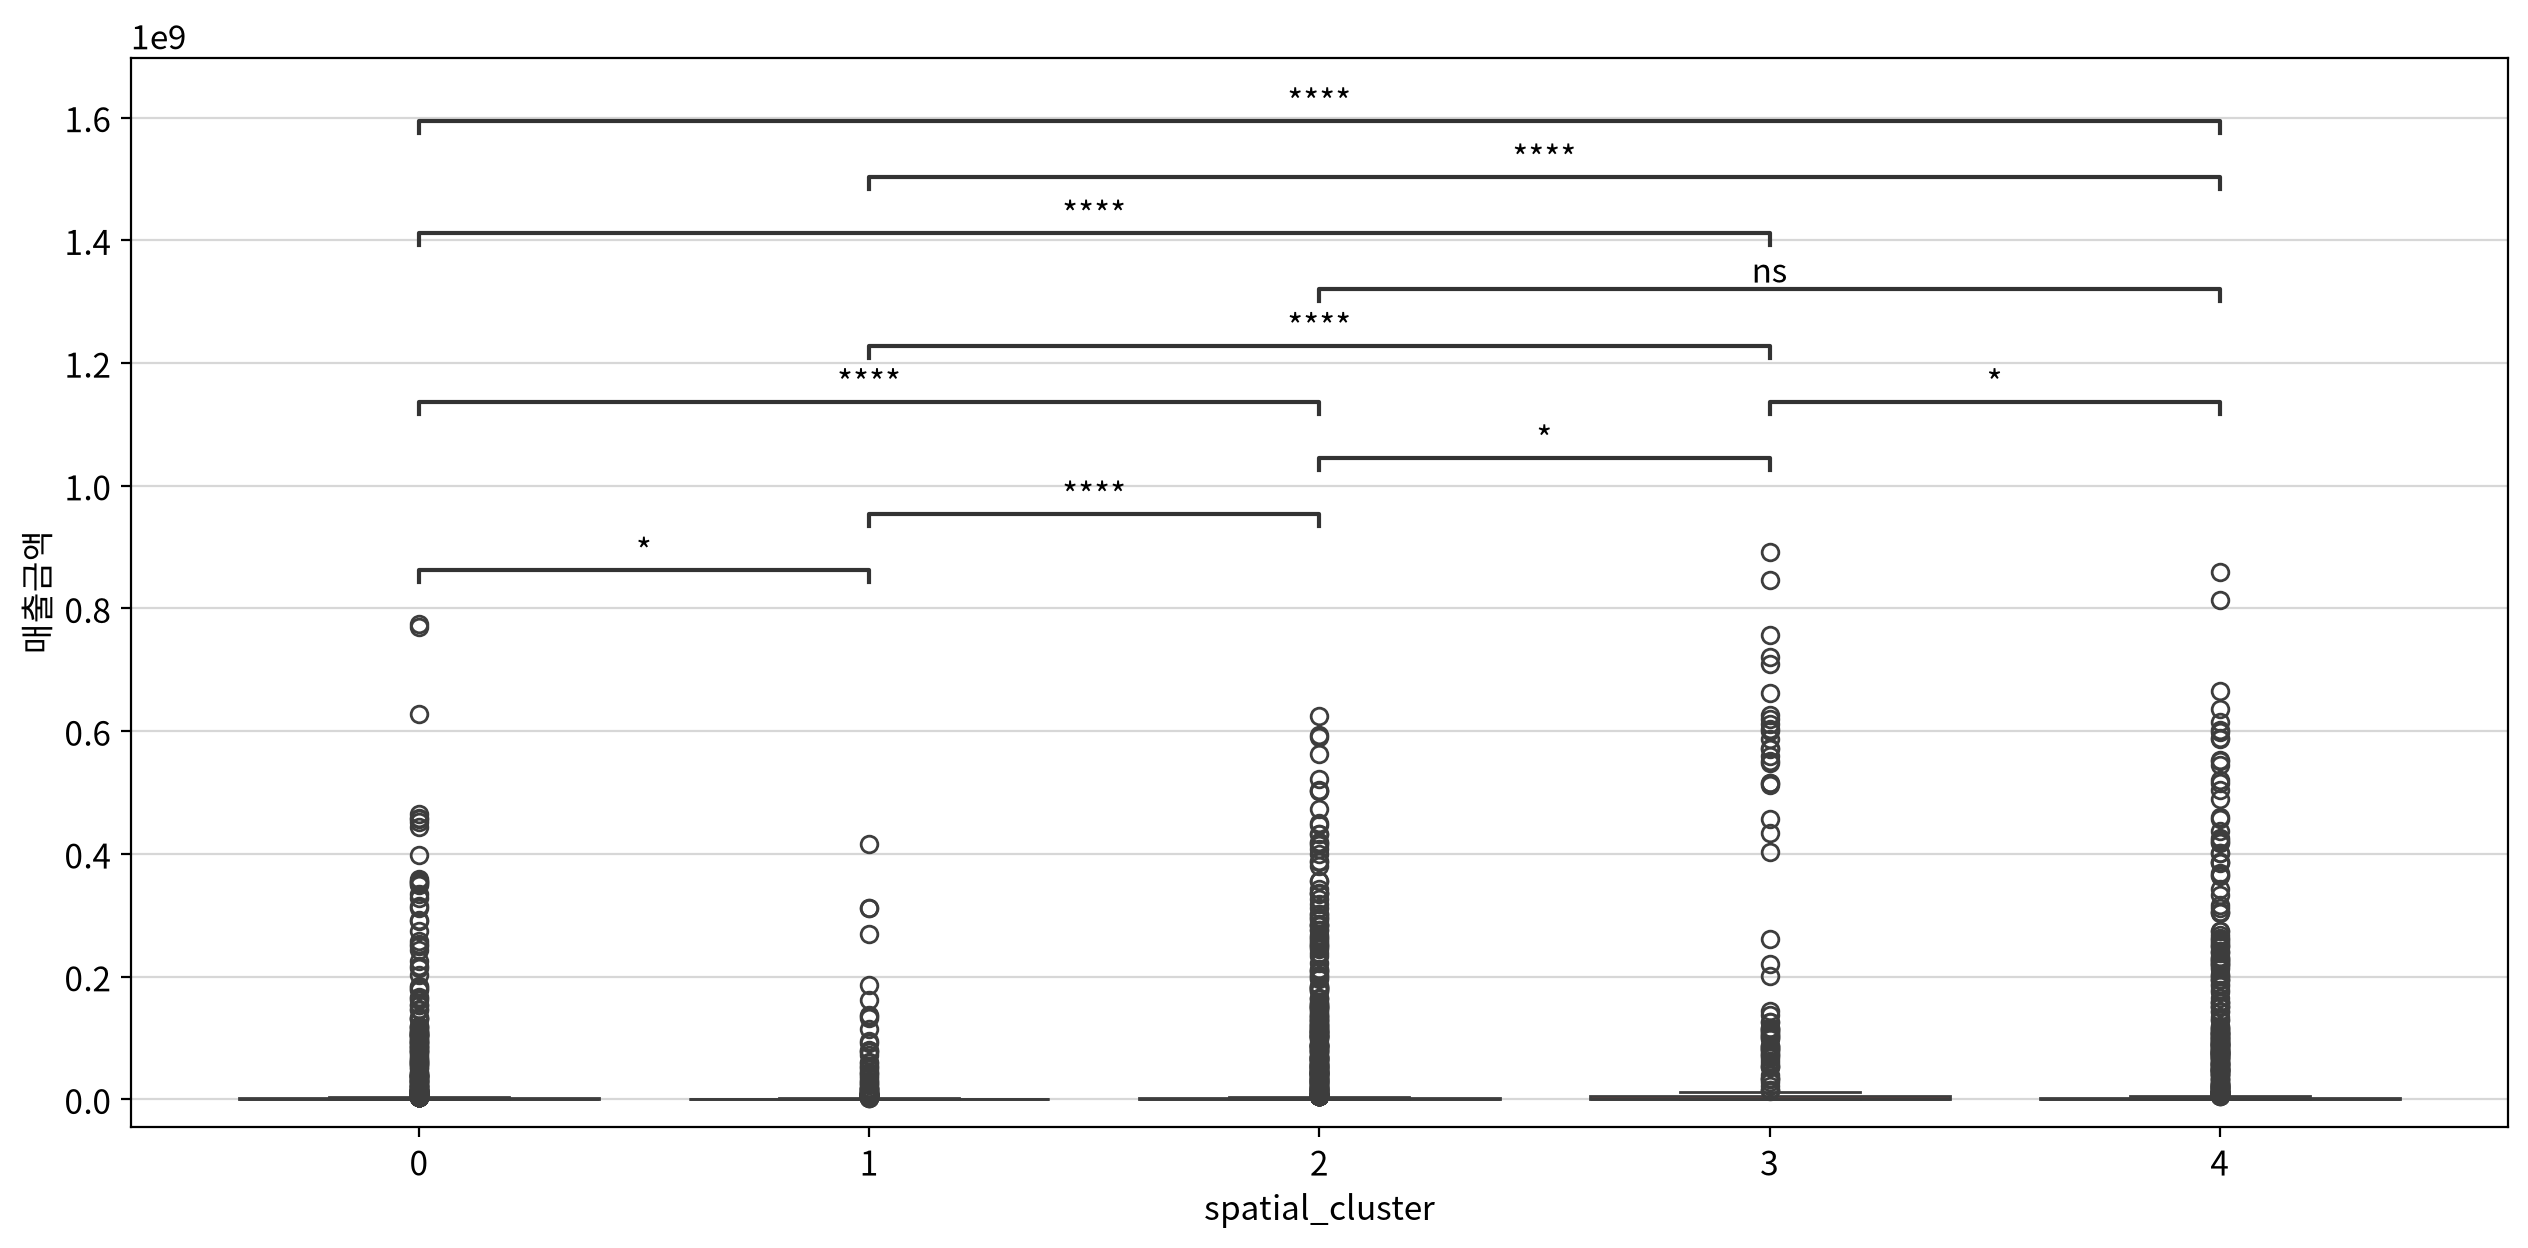

비교한 조합 쌍: 10개
유의한 쌍: 9개
평균 차이가 가장 큰 쌍: (1) vs (3) → 차이 36557354.147, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (2) vs (4) → 차이 452160.482, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,1.169077e+07,6.377454e+06,5.313320e+06,1.768835e+06,3.003853,1996.860465,2.262873e-02,0.108237,True,Negligible
1,Games-Howell,0,2,1.169077e+07,2.165622e+07,-9.965444e+06,2.164350e+06,-4.604358,3130.141240,4.227537e-05,-0.157842,True,Negligible
2,Games-Howell,0,3,1.169077e+07,4.293481e+07,-3.124403e+07,6.827899e+06,-4.575937,463.142253,5.965188e-05,-0.397979,True,Small
3,Games-Howell,0,4,1.169077e+07,2.210838e+07,-1.041760e+07,2.333230e+06,-4.464885,2971.058591,8.128440e-05,-0.152552,True,Negligible
4,Games-Howell,1,2,6.377454e+06,2.165622e+07,-1.527876e+07,2.122447e+06,-7.198655,2298.319810,8.544720e-12,-0.243317,True,Small
5,Games-Howell,1,3,6.377454e+06,4.293481e+07,-3.655735e+07,6.814732e+06,-5.364459,459.402025,1.281597e-06,-0.400027,True,Small
6,Games-Howell,1,4,6.377454e+06,2.210838e+07,-1.573093e+07,2.294414e+06,-6.856185,2349.730093,9.024181e-11,-0.223679,True,Small
7,Games-Howell,2,3,2.165622e+07,4.293481e+07,-2.127859e+07,6.927930e+06,-3.071421,490.474716,1.901153e-02,-0.237538,True,Small
8,Games-Howell,2,4,2.165622e+07,2.210838e+07,-4.521605e+05,2.611507e+06,-0.173142,3345.620037,9.997991e-01,-0.005947,False,Negligible
9,Games-Howell,3,4,4.293481e+07,2.210838e+07,2.082643e+07,6.982533e+06,2.982647,505.802047,2.486043e-02,0.218522,True,Small


In [69]:
# 3. ANOVA(x: 3집단 명목형 독립변수 -> y: 종속변수) 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) >= 3:
        print()  # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df3, y=target, between=n))
        display(my_stats.posthoc_oneway(df3, y=target, between=n, plot=True))

### 군집별 매출 차이와 유형화의 활용 범위

- 군집별 매출 차이는 검정에서 유의하지만, 전체 효과크기는 약 0.014로 작다. 군집만으로 개별 관측치의 매출 차이를 충분히 설명한다고 볼 수는 없다.
- 사후검정에서는 10개 비교 중 9개가 유의했고, 군집 2와 4의 평균 차이는 유의하지 않았다. 인구·업종 구성이 달라도 평균매출은 비슷할 수 있다.
- 군집을 유지하는 근거는 높은 매출 구분력만이 아니라 지역 구조를 해석 가능한 단위로 묶는 데 있다.
- 이후 예측 기여도와 별개로, 군집별 인구·가맹점 특성을 활용해 서로 다른 정책 검토 항목을 설정할 수 있다.

In [70]:
corr = my_stats.multi_correlation(df3, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,행정동코드,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수
행정동코드,1.000,0.094,-0.330,0.085,0.016,0.052,0.062,0.046,0.070,0.147,0.042,0.082,0.065,0.114,-0.376,0.091,0.022
총인구수,0.094,1.000,0.234,0.520,-0.069,0.561,0.311,0.356,0.427,0.779,0.569,0.645,0.688,0.527,-0.136,0.651,-0.152
월유동인구수,-0.330,0.234,1.000,0.185,0.023,0.197,0.153,0.198,0.218,0.259,0.388,0.281,0.259,0.266,0.913,0.249,0.070
가맹점수_소매,0.085,0.520,0.185,1.000,0.433,0.881,0.460,0.685,0.468,0.394,0.701,0.793,0.846,0.760,-0.013,0.923,0.627
가맹점수_숙박,0.016,-0.069,0.023,0.433,1.000,0.427,0.209,0.346,0.148,-0.149,0.315,0.276,0.298,0.327,0.039,0.364,0.493
가맹점수_음식,0.052,0.561,0.197,0.881,0.427,1.000,0.476,0.716,0.514,0.488,0.680,0.869,0.894,0.783,-0.020,0.962,0.639
가맹점수_부동산,0.062,0.311,0.153,0.460,0.209,0.476,1.000,0.281,0.335,0.265,0.337,0.469,0.454,0.455,0.024,0.478,0.311
가맹점수_과학·기술,0.046,0.356,0.198,0.685,0.346,0.716,0.281,1.000,0.348,0.383,0.595,0.625,0.704,0.676,0.068,0.742,0.557
가맹점수_시설관리·임대,0.070,0.427,0.218,0.468,0.148,0.514,0.335,0.348,1.000,0.475,0.516,0.614,0.548,0.529,0.042,0.567,0.299
가맹점수_교육,0.147,0.779,0.259,0.394,-0.149,0.488,0.265,0.383,0.475,1.000,0.630,0.628,0.601,0.510,-0.029,0.615,-0.015


,max-y,max-coef,count,columns
x,,,,
총_가맹점수,가맹점수_음식,0.9618,7,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠, 가맹점..."
가맹점수_수리·개인,총_가맹점수,0.9349,7,"총_가맹점수, 가맹점수_음식, 가맹점수_예술·스포츠, 가맹점수_소매, 가맹점수_기타..."
가맹점수_음식,총_가맹점수,0.9618,6,"총_가맹점수, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠, 가맹점수..."
가맹점수_소매,총_가맹점수,0.9235,6,"총_가맹점수, 가맹점수_음식, 가맹점수_수리·개인, 가맹점수_예술·스포츠, 가맹점수..."
가맹점수_예술·스포츠,총_가맹점수,0.9067,6,"총_가맹점수, 가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_보건의..."
가맹점수_기타,총_가맹점수,0.8300,5,"총_가맹점수, 가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠"
가맹점수_보건의료,총_가맹점수,0.7863,4,"총_가맹점수, 가맹점수_예술·스포츠, 가맹점수_수리·개인, 가맹점수_소매"
가맹점수_과학·기술,총_가맹점수,0.7423,3,"총_가맹점수, 가맹점수_음식, 가맹점수_수리·개인"
1인당_유동인구,월유동인구수,0.9129,1,월유동인구수


### 규모 정보의 중복을 확인하고 업종별 상대 수준으로 확장

- 총가맹점 수와 음식 가맹점 수의 상관은 약 0.96이며, 다른 주요 업종의 개수와도 높은 상관이 나타난다.
- 월유동인구와 인구 대비 유동인구도 약 0.91의 상관을 보여, 원본과 파생변수를 모두 사용한다고 독립적인 정보가 추가되는 것은 아니다.
- 업종별 인구 1만 명당 가맹점 수를 생성해 절대 개수와 다른 기준으로 비교하고, 생성 이후에도 중복 관계가 남아 있는지 확인한다.

In [71]:
# 가맹점수 컬럼 선택
store_cols = df3.columns[df3.columns.str.startswith("가맹점수_")]

# 인구가 0이면 나눗셈 대신 결측값 처리
population = df3["총인구수"].where(df3["총인구수"] > 0)

# 인구 1만 명당 가맹점수로 변환
df3[store_cols] = df3[store_cols].div(population, axis=0) * 10_000

# 컬럼명 변경
df3 = df3.rename(columns={
    col: col.replace("가맹점수_", "만명당_가맹점수_")
    for col in store_cols
})

df3.head()

,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,만명당_가맹점수_소매,만명당_가맹점수_숙박,만명당_가맹점수_음식,...,만명당_가맹점수_교육,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_수리·개인,만명당_가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수,분기,spatial_cluster
0,7,4111156000,41128684,경기도 수원시 장안구 파장동,22480,241011.94,2023,121.886121,1.334520,110.320285,...,6.227758,9.341637,11.120996,43.149466,8.451957,10.721172,712,316.725979,3,2
1,8,4111156000,5115679,경기도 수원시 장안구 파장동,22451,241268.02,2023,122.043562,1.336243,110.462786,...,6.235802,9.353704,11.135361,43.205202,8.462875,10.746426,712,317.135094,3,2
2,9,4111156000,436318,경기도 수원시 장안구 파장동,22410,236580.40,2023,122.266845,1.338688,110.664882,...,6.247211,9.370817,11.155734,43.284248,8.478358,10.556912,712,317.715306,3,2
3,10,4111156000,631469,경기도 수원시 장안구 파장동,23628,268762.16,2023,115.964110,1.269680,104.960217,...,5.925174,8.887760,10.580667,41.052988,8.041307,11.374732,712,301.337396,4,2
4,11,4111156000,591386,경기도 수원시 장안구 파장동,24542,253510.66,2023,111.645343,1.222394,101.051259,...,5.704507,8.556760,10.186619,39.524081,7.741830,10.329666,712,290.114905,4,2


In [72]:
df3.to_excel("local_dataset.xlsx", index=False)

In [73]:
# 1. 가맹점당 월유동인구 생성 — 로그 변환 전 값 사용
total_store = df3["총_가맹점수"].where(df3["총_가맹점수"] > 0)

df3["가맹점당_월유동인구"] = (
    df3["월유동인구수"] / total_store
)

# 2. 생활소비 내 업종 비중 생성 — 로그 변환 전 값 사용
life_cols = [
    "만명당_가맹점수_소매",
    "만명당_가맹점수_음식",
    "만명당_가맹점수_수리·개인"
]

life_total = df3[life_cols].sum(
    axis=1,
    min_count=len(life_cols)
)
life_total = life_total.where(life_total > 0)

df3["생활소비내_음식비중"] = (
    df3["만명당_가맹점수_음식"] / life_total
)

df3["생활소비내_소매비중"] = (
    df3["만명당_가맹점수_소매"] / life_total
)

# 3. 검정할 변수 목록
derived_continuous = [
    col for col in df3.columns
    if col.startswith("만명당_가맹점수_")
    and col != "만명당_가맹점수_생활소비"
] + [
    "가맹점당_월유동인구",
    "생활소비내_음식비중",
    "생활소비내_소매비중"
]

target = "매출금액"

# 4. 결측값 확인
display(df3[derived_continuous].isna().sum())

# 5. 기술통계 확인
derived_num_desc = my_qtcheck.numerical_summary(
    df3, columns=derived_continuous
)

display(
    derived_num_desc[
        ["mean", "50%", "skew", "kurt", "outliers_ratio", "log_need"]
    ]
)

만명당_가맹점수_소매         0
만명당_가맹점수_숙박         0
만명당_가맹점수_음식         0
만명당_가맹점수_부동산        0
만명당_가맹점수_과학·기술      0
만명당_가맹점수_시설관리·임대    0
만명당_가맹점수_교육         0
만명당_가맹점수_보건의료       0
만명당_가맹점수_예술·스포츠     0
만명당_가맹점수_수리·개인      0
만명당_가맹점수_기타         0
가맹점당_월유동인구          0
생활소비내_음식비중          0
생활소비내_소매비중          0
dtype: int64

,mean,50%,skew,kurt,outliers_ratio,log_need
만명당_가맹점수_소매,94.189369,69.877718,4.507670,28.217474,0.101763,log
만명당_가맹점수_숙박,1.648930,0.366522,8.066280,82.308515,0.133333,log1p
만명당_가맹점수_음식,107.272828,88.849513,2.494165,9.957126,0.070994,log
만명당_가맹점수_부동산,0.307079,0.000000,5.412720,54.108461,0.035096,log1p
만명당_가맹점수_과학·기술,4.125096,2.477313,2.691581,8.852997,0.092468,log1p
만명당_가맹점수_시설관리·임대,1.105235,0.790592,2.905207,14.877843,0.051923,log1p
만명당_가맹점수_교육,26.530027,22.909652,1.325642,2.509033,0.025000,log1p
만명당_가맹점수_보건의료,9.663207,7.452999,2.407037,7.556409,0.077083,log1p
만명당_가맹점수_예술·스포츠,13.048896,11.224332,1.610613,3.259312,0.054968,log1p
만명당_가맹점수_수리·개인,39.549664,34.949966,1.642561,4.112815,0.061538,log1p


In [74]:
derived_num_desc = my_qtcheck.numerical_summary(df3, columns=derived_continuous)
derived_num_desc[['mean', '50%', 'skew', 'kurt', 'outliers_ratio', 'log_need']]

,mean,50%,skew,kurt,outliers_ratio,log_need
만명당_가맹점수_소매,94.189369,69.877718,4.507670,28.217474,0.101763,log
만명당_가맹점수_숙박,1.648930,0.366522,8.066280,82.308515,0.133333,log1p
만명당_가맹점수_음식,107.272828,88.849513,2.494165,9.957126,0.070994,log
만명당_가맹점수_부동산,0.307079,0.000000,5.412720,54.108461,0.035096,log1p
만명당_가맹점수_과학·기술,4.125096,2.477313,2.691581,8.852997,0.092468,log1p
만명당_가맹점수_시설관리·임대,1.105235,0.790592,2.905207,14.877843,0.051923,log1p
만명당_가맹점수_교육,26.530027,22.909652,1.325642,2.509033,0.025000,log1p
만명당_가맹점수_보건의료,9.663207,7.452999,2.407037,7.556409,0.077083,log1p
만명당_가맹점수_예술·스포츠,13.048896,11.224332,1.610613,3.259312,0.054968,log1p
만명당_가맹점수_수리·개인,39.549664,34.949966,1.642561,4.112815,0.061538,log1p


### 공급 수준·유동 수준·업종 구성을 구분한 파생변수

- 업종별 인구 1만 명당 가맹점 수는 주민 규모 대비 업종별 공급 수준을 나타낸다. 전체 가맹점 중 해당 업종의 비율과는 다른 지표다.
- `가맹점당_월유동인구`는 지역의 월유동인구를 전체 가맹점 수로 나눈 값이다. 개별 가맹점의 실제 방문객 수나 구매 전환율로 해석하지 않는다.
- 생활소비 내 비중은 소매·음식·수리·개인으로 한정한 가맹점 구성비이며, 실제 소비금액의 업종별 비중은 아니다.
- 생성된 변수에는 결측치가 없지만, 여러 공급 지표와 가맹점당 유동인구의 오른쪽 치우침이 남아 있어 모델 투입 전 변환 여부를 검토한다.

#### 이변량 분석 - 상관분석 (연속형 파생 → 종속변수)

In [75]:
corr_list = []

for f in derived_continuous:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
만명당_가맹점수_예술·스포츠,매출금액,Spearman,0.1354,0.0000,Weak,True,False,False,False,False,True
만명당_가맹점수_소매,매출금액,Spearman,0.1205,0.0000,Weak,True,False,False,False,False,True
만명당_가맹점수_부동산,매출금액,Spearman,0.1134,0.0000,Weak,True,False,False,False,False,True
만명당_가맹점수_수리·개인,매출금액,Spearman,0.1120,0.0000,Weak,True,False,False,True,False,True
만명당_가맹점수_음식,매출금액,Spearman,0.0846,0.0000,Weak,True,False,False,True,False,True
만명당_가맹점수_기타,매출금액,Spearman,0.0659,0.0000,Weak,True,False,False,False,False,True
만명당_가맹점수_시설관리·임대,매출금액,Spearman,0.0539,0.0000,Weak,True,False,False,False,True,True
만명당_가맹점수_과학·기술,매출금액,Spearman,0.0526,0.0000,Weak,True,False,False,False,False,True
생활소비내_소매비중,매출금액,Spearman,0.0454,0.0003,Weak,True,False,False,False,False,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak    14
Name: count, dtype: int64


In [76]:
corr = my_stats.multi_correlation(df3, columns=derived_continuous, plot=False)
my_stats.correlation_summary(corr)

,만명당_가맹점수_소매,만명당_가맹점수_숙박,만명당_가맹점수_음식,만명당_가맹점수_부동산,만명당_가맹점수_과학·기술,만명당_가맹점수_시설관리·임대,만명당_가맹점수_교육,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_수리·개인,만명당_가맹점수_기타,가맹점당_월유동인구,생활소비내_음식비중,생활소비내_소매비중
만명당_가맹점수_소매,1.000,0.529,0.836,0.284,0.579,0.305,-0.199,0.471,0.627,0.810,0.684,-0.246,0.025,0.239
만명당_가맹점수_숙박,0.529,1.000,0.546,0.181,0.379,0.198,-0.217,0.377,0.386,0.453,0.412,-0.172,0.195,0.003
만명당_가맹점수_음식,0.836,0.546,1.000,0.343,0.629,0.374,-0.012,0.452,0.755,0.847,0.722,-0.276,0.494,-0.245
만명당_가맹점수_부동산,0.284,0.181,0.343,1.000,0.159,0.223,0.089,0.202,0.370,0.309,0.345,-0.064,0.157,-0.067
만명당_가맹점수_과학·기술,0.579,0.379,0.629,0.159,1.000,0.225,0.121,0.467,0.520,0.672,0.579,-0.120,0.165,-0.091
만명당_가맹점수_시설관리·임대,0.305,0.198,0.374,0.223,0.225,1.000,0.222,0.326,0.471,0.347,0.394,-0.074,0.197,-0.120
만명당_가맹점수_교육,-0.199,-0.217,-0.012,0.089,0.121,0.222,1.000,0.322,0.219,0.043,0.108,0.040,0.203,-0.349
만명당_가맹점수_보건의료,0.471,0.377,0.452,0.202,0.467,0.326,0.322,1.000,0.545,0.476,0.433,0.088,0.060,0.018
만명당_가맹점수_예술·스포츠,0.627,0.386,0.755,0.370,0.520,0.471,0.219,0.545,1.000,0.708,0.619,-0.178,0.349,-0.203
만명당_가맹점수_수리·개인,0.810,0.453,0.847,0.309,0.672,0.347,0.043,0.476,0.708,1.000,0.712,-0.184,0.197,-0.158


,max-y,max-coef,count,columns
x,,,,
만명당_가맹점수_수리·개인,만명당_가맹점수_음식,0.8471,4,"만명당_가맹점수_음식, 만명당_가맹점수_소매, 만명당_가맹점수_기타, 만명당_가맹점..."
만명당_가맹점수_음식,만명당_가맹점수_수리·개인,0.8471,4,"만명당_가맹점수_수리·개인, 만명당_가맹점수_소매, 만명당_가맹점수_예술·스포츠, ..."
만명당_가맹점수_소매,만명당_가맹점수_음식,0.8358,2,"만명당_가맹점수_음식, 만명당_가맹점수_수리·개인"
만명당_가맹점수_예술·스포츠,만명당_가맹점수_음식,0.7553,2,"만명당_가맹점수_음식, 만명당_가맹점수_수리·개인"
만명당_가맹점수_기타,만명당_가맹점수_음식,0.7215,2,"만명당_가맹점수_음식, 만명당_가맹점수_수리·개인"
생활소비내_소매비중,생활소비내_음식비중,-0.8524,1,생활소비내_음식비중
생활소비내_음식비중,생활소비내_소매비중,-0.8524,1,생활소비내_소매비중
만명당_가맹점수_과학·기술,만명당_가맹점수_수리·개인,0.6720,0,-
만명당_가맹점수_숙박,만명당_가맹점수_음식,0.5456,0,-


### 파생변수의 채택은 유의성과 관계의 크기를 함께 고려

- 새 파생변수와 매출의 상관은 모두 약한 수준이며, 인구 보정 이후 뚜렷한 단변량 설명력을 확보했다고 보기는 어렵다.
- 숙박·교육의 인구 대비 가맹점 수는 이번 검정에서 유의한 관계가 확인되지 않았다. 이는 제외를 검토할 근거지만, 해당 업종이 지역화폐와 전혀 무관하다는 뜻은 아니다.
- 가맹점당 월유동인구는 약 -0.14의 상관을 보인다. 이 결과만으로 유동인구 증가가 매출을 감소시키거나 가맹점 확대가 매출을 증가시킨다고 해석하지 않는다.
- 이후에는 채택된 변수들을 함께 투입해 개별 상관분석에서 확인되지 않은 예측 정보를 비교한다.

In [ ]:
# 이번 단원의 검증 결과를 반영해 모형에 투입할 변수를 확정한다.
feature_cols = [
    "총인구수",
#    "월유동인구수",
#    "1인당_유동인구",
#    "총_가맹점수",
    "만명당_가맹점수",
    "spatial_cluster",
    "기준월",
    "년도",
    "만명당_가맹점수_소매",
    "만명당_가맹점수_음식",
    "만명당_가맹점수_부동산",
    "만명당_가맹점수_과학·기술",
    "만명당_가맹점수_시설관리·임대",
    "만명당_가맹점수_보건의료",
    "만명당_가맹점수_예술·스포츠",
    "만명당_가맹점수_수리·개인",
    "만명당_가맹점수_기타",
    "가맹점당_월유동인구",
#    "생활소비내_음식비중",
#    "생활소비내_소매비중"
]

print("투입 변수 :", len(feature_cols), "종")
print("투입 변수 목록 :", feature_cols)

# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]

# 로그 변환·라벨링 전, 원 단위 그대로의 상태를 먼저 남긴다.
df_derived = df3[save_cols]
df_derived = my_qtcheck.set_type(df_derived,
                    as_category=["spatial_cluster", "기준월", "년도"])

df_derived.to_excel("local_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

df_derived.to_parquet("local_features.parquet", index=False)

투입 변수 : 15 종
투입 변수 목록 : ['총인구수', '만명당_가맹점수', 'spatial_cluster', '기준월', '년도', '만명당_가맹점수_소매', '만명당_가맹점수_음식', '만명당_가맹점수_부동산', '만명당_가맹점수_과학·기술', '만명당_가맹점수_시설관리·임대', '만명당_가맹점수_보건의료', '만명당_가맹점수_예술·스포츠', '만명당_가맹점수_수리·개인', '만명당_가맹점수_기타', '가맹점당_월유동인구']
<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   총인구수              6240 non-null   int64   
 1   만명당_가맹점수          6240 non-null   float64 
 2   spatial_cluster   6240 non-null   category
 3   기준월               6240 non-null   category
 4   년도                6240 non-null   category
 5   만명당_가맹점수_소매       6240 non-null   float64 
 6   만명당_가맹점수_음식       6240 non-null   float64 
 7   만명당_가맹점수_부동산      6240 non-null   float64 
 8   만명당_가맹점수_과학·기술    6240 non-null   float64 
 9   만명당_가맹점수_시설관리·임대  6240 non-null   float64 
 10  만명당_가맹점수_보건의료     6240 non-null   float64 
 11  만명당_가맹점수_예술·스포츠   6240 non-null

In [78]:
# 투입 변수만 다시 기술통계량을 내어 로그 변환 대상을 확인한다.
feature_desc = my_qtcheck.numerical_summary(df_derived)
display(feature_desc[["skew", "kurt", "log_need"]])

# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

# 독립변수와 종속변수에 로그 변환 수행
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)

# 범주형 라벨링 : category 타입을 모형이 읽을 수 있는 정수로 바꾼다.
label_cols = ["spatial_cluster", "기준월", "년도"]
df_label = my_prep.labeling(df_log, columns=label_cols)

df_label.to_excel("local_features_log_labeled.xlsx", index=False)
print("저장 완료 :", df_label.shape)
df_label.head()


,skew,kurt,log_need
총인구수,0.629871,0.225478,log
만명당_가맹점수,2.878787,12.295213,log
만명당_가맹점수_소매,4.507670,28.217474,log
만명당_가맹점수_음식,2.494165,9.957126,log
만명당_가맹점수_부동산,5.412720,54.108461,log1p
만명당_가맹점수_과학·기술,2.691581,8.852997,log1p
만명당_가맹점수_시설관리·임대,2.905207,14.877843,log1p
만명당_가맹점수_보건의료,2.407037,7.556409,log1p
만명당_가맹점수_예술·스포츠,1.610613,3.259312,log1p
만명당_가맹점수_수리·개인,1.642561,4.112815,log1p


log(x)      : ['총인구수', '만명당_가맹점수', '만명당_가맹점수_소매', '만명당_가맹점수_음식', '가맹점당_월유동인구', '매출금액']
log(1+x)    : ['만명당_가맹점수_부동산', '만명당_가맹점수_과학·기술', '만명당_가맹점수_시설관리·임대', '만명당_가맹점수_보건의료', '만명당_가맹점수_예술·스포츠', '만명당_가맹점수_수리·개인', '만명당_가맹점수_기타']
반사 후 log : []
컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
총인구수      우측 꼬리     log(x)                exp(y)                   0.63 -> -1.08
만명당_가맹점수  우측 꼬리     log(x)                exp(y)                    2.88 -> 0.12
만명당_가맹점수_소매우측 꼬리     log(x)                exp(y)                    4.51 -> 0.56
만명당_가맹점수_음식우측 꼬리     log(x)                exp(y)                   2.49 -> -0.30
가맹점당_월유동인구우측 꼬리     log(x)                exp(y)                   5.05 -> -0.22
매출금액      우측 꼬리     log(x)                exp(y)                    6.03 -> 0.93
만명당_가맹점수_부동산우측 꼬리     log(1+x)              exp(y)-1                  5.41 -> 1.65
만명당_가맹점수_과학·기술우측 꼬

,총인구수,만명당_가맹점수,spatial_cluster,기준월,년도,만명당_가맹점수_소매,만명당_가맹점수_음식,만명당_가맹점수_부동산,만명당_가맹점수_과학·기술,만명당_가맹점수_시설관리·임대,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_수리·개인,만명당_가맹점수_기타,가맹점당_월유동인구,매출금액
0,10.020381,5.758037,2,6,0,4.803087,4.703388,0.367998,1.299930,1.022220,2.336178,2.494939,3.787581,2.246222,5.824524,17.532216
1,10.019090,5.759328,2,7,0,4.804378,4.704679,0.368396,1.300869,1.023047,2.337344,2.496124,3.788842,2.247376,5.825586,15.447821
2,10.017263,5.761156,2,8,0,4.806206,4.706507,0.368960,1.302200,1.024218,2.338996,2.497801,3.790629,2.249011,5.805965,12.986127
3,10.070188,5.708231,2,9,0,4.753281,4.653581,0.352927,1.263946,0.990621,2.291298,2.449337,3.738930,2.201804,5.933504,13.355804
4,10.108141,5.670277,2,10,0,4.715327,4.615628,0.341790,1.236863,0.966930,2.257249,2.414718,3.701896,2.168120,5.875083,13.290224


### 인구 보정 이후에도 변수 간 중복은 남아 있다

- 음식과 수리·개인의 인구 대비 가맹점 수는 약 0.85, 음식과 소매는 약 0.84의 상관을 보인다. 인구 보정이 변수 간 중복을 모두 제거한 것은 아니다.
- 생활소비 내 소매·음식 비중은 약 -0.85의 상관을 보인다. 같은 분모를 사용하는 구성비이므로 한쪽의 상대적 비중 증가가 다른 쪽의 비중 감소와 연결되는 구조다.
- 이후 변수 중요도를 해석할 때 서로 관련된 변수들이 예측 정보를 나누어 가질 수 있다는 점을 고려한다.
- 현재 확인한 것은 변수 쌍의 상관관계이며, VIF 검증이나 다중공선성 해소를 완료한 결과는 아니다.